# CIRCL-E — Discovery Berbasis Citra
## Discovery → seleksi → evaluasi final → ablation → handoff interpretasi

Notebook ini membangun struktur numerik pada subset **Electronic** hanya dari informasi visual. Tahap ini belum memberi nama semantik pada cluster atau faktor kontinu.

Alur analisis dibagi menjadi empat bagian:

1. **Discovery dan seleksi model** menggunakan metrik yang diperlukan untuk memilih struktur numerik.
2. Setelah parent, fine group, raw visual leaf, dan faktor atribut ditetapkan, dilakukan **audit final independen** dengan seed resampling yang berbeda. Hasil audit ini tidak digunakan untuk mengubah assignment.
3. **Ablation** membandingkan metode terpilih dengan alternatif yang relevan untuk menjelaskan keputusan metodologis.
4. Setelah struktur numerik dibekukan, notebook mengekspor tabel, resource model, dan montage yang digunakan pada tahap semantic mapping.

### Prinsip seleksi

Kandidat broad parent harus lebih dulu memenuhi batas minimum struktur dan reproducibility. Di antara kandidat dengan reliabilitas yang sebanding, solusi dengan nuisance yang lebih rendah diprioritaskan.

### Batas interpretasi

`raw_parent_id`, `validated_fine_group_id`, dan `raw_visual_leaf_id` adalah **struktur visual numerik**, bukan nama kelas semantik. Penamaan dan interpretasi dilakukan pada Notebook 2 dan tidak boleh mengubah membership yang dibekukan di sini.

### Status ablation

- **✅ RETAINED** — digunakan pada pipeline final.
- **❌ NOT RETAINED** — dibandingkan tetapi tidak dipakai.
- **⚠️ SKIPPED / MIXED** — dependency tidak tersedia atau hasil tidak cukup kuat untuk dipertahankan.


In [1]:
# 0. Konfigurasi reproducibility dan pencarian sumber data.

from pathlib import Path
import os

# Reproducibility and run/source roots
SEED = 42
START_DIR = Path.cwd().expanduser().resolve()

def discover_source_root(start: Path) -> Path:
    """Locate the source project containing the official Electronic data and local model checkpoints."""
    env = os.environ.get('CIRCLE_SOURCE_ROOT')
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'data' / 'competition' / 'train' / '1_Electronic').is_dir() and (p / 'models').is_dir():
            return p
        raise FileNotFoundError(f'CIRCLE_SOURCE_ROOT does not contain expected data/models: {p}')
    anchors = [start, *start.parents]
    for p in anchors:
        if (p / 'data' / 'competition' / 'train' / '1_Electronic').is_dir() and (p / 'models').is_dir():
            return p
    for p in anchors:
        try:
            children = sorted([q for q in p.iterdir() if q.is_dir()], key=lambda q: q.name)
        except Exception:
            continue
        matches = [q for q in children if (q / 'data' / 'competition' / 'train' / '1_Electronic').is_dir() and (q / 'models').is_dir()]
        if len(matches) == 1:
            return matches[0].resolve()
        if len(matches) > 1:
            raise RuntimeError(f'Multiple possible source projects under {p}: {matches}. Set CIRCLE_SOURCE_ROOT explicitly.')
    raise FileNotFoundError('Could not discover source project root. Put the run directory inside/next to the source project, or set CIRCLE_SOURCE_ROOT to the directory containing data/ and models/.')
SOURCE_ROOT = discover_source_root(START_DIR)
if os.environ.get('CIRCLE_RUN_ROOT'):
    RUN_ROOT = Path(os.environ['CIRCLE_RUN_ROOT']).expanduser().resolve()
elif START_DIR == SOURCE_ROOT:
    RUN_ROOT = SOURCE_ROOT / 'FINAL_DISCOVERY_RUN'
else:
    RUN_ROOT = START_DIR
RUN_ROOT.mkdir(parents=True, exist_ok=True)
ELECTRONIC_DIR = SOURCE_ROOT / 'data' / 'competition' / 'train' / '1_Electronic'
EDA_DIR = SOURCE_ROOT / 'eda'
MODEL_ROOT = SOURCE_ROOT / 'models'
DINO_DIR = MODEL_ROOT / 'facebook__dinov3-vitl16-pretrain-lvd1689m'
CRADIO_DIR = MODEL_ROOT / 'nvidia__C-RADIOv4-SO400M'
OUT = RUN_ROOT / 'artifacts'
PIPELINE_VERSION = 'final-imageonly-discovery-final-story-2026-09-23'

# Representation extraction
DINO_SHORT = 512
DINO_MAX_LONG = 1024
DINO_MID_FRACTION = 0.75
PATCHES_PER_IMAGE = 48
PATCH_PCA_DIM = 64
VLAD_K = 32
CONCEPT_K = 512
CRADIO_SHORT = 512
CRADIO_MAX_LONG = 1024
FIT_FRACTION = 0.8
ATTR_SHORT = 768
ATTR_MAX_LONG = 1024
RUN_FOREGROUND_EMBEDDINGS = True
FOREGROUND_CANVAS = 512
FOREGROUND_MARGIN = 0.04
FOREGROUND_FILL = (127, 127, 127)
FOREGROUND_PREPROC_VERSION = 'bbox-margin04-letterbox512-gray-v3-resolution-safe'
FOREGROUND_DINO_PREPROC_VERSION = 'bbox-margin04-aspect-preserving-v2'
CRADIO_DISABLE_FUSED_ATTN = True
GPU_CHECKPOINT_EVERY = 10
GPU_ATTEMPT_LOG = True

# Validation-only perceptual near-duplicate grouping
NEAR_DUP_RULES = {'strict': {'pmax': 2, 'dmax': 2, 'summax': 4},
    'primary': {'pmax': 4, 'dmax': 4, 'summax': 6},
    'loose': {'pmax': 6, 'dmax': 6, 'summax': 10}}
VAL_GROUP_RULE = 'primary'
SELECTION_GROUP_SPLIT_REPS = 8
SELECTION_HOLDOUT_REPS = 10
GROUP_SPLIT_REPS = SELECTION_GROUP_SPLIT_REPS
HOLDOUT_REPS = SELECTION_HOLDOUT_REPS
HOLDOUT_FRAC = 0.2

# Independent final audit: these splits never influence model selection or assignments.
FINAL_AUDIT_SEED = 4242
FINAL_AUDIT_GROUP_SPLIT_REPS = 20
FINAL_AUDIT_HOLDOUT_REPS = 20
TARGET_ROUTING_RISK = 0.05
LOCAL_THRESHOLD_SHRINK_N = 200
REJECT_THRESHOLD = 1.000001


# Compact explanatory ablations. These never alter final assignments.
RUN_RATIONALE_ABLATIONS = True
ROOT_ABLATION_HDBSCAN_SETTINGS = ((40, 10), (60, 10), (80, 10))
ROOT_ABLATION_LEIDEN_GRAPH_K = 30
ROOT_ABLATION_LEIDEN_GAMMAS = (0.04, 0.08, 0.12)
ROOT_ABLATION_KNN_KS = (5, 10, 20)
RUN_ATTRIBUTE_NMF_ABLATION = True
ATTRIBUTE_NMF_MAX_ITER = 450

# Broad-parent discovery
KMEANS_SEEDS = (11, 42, 71)
PARENT_KS = (16, 18, 20)
ROOT_MIN_SIZE = 30
ROOT_MIN_COVERAGE = 0.95
ROOT_MIN_SEED_ARI = 0.85
ROOT_MIN_GROUP_ARI = 0.84
ROOT_MIN_MACRO_RECALL = 0.84
ROOT_MIN_Q10_RECALL = 0.72
ROOT_MIN_Q10_PREC = 0.7
ROOT_MIN_SIL = 0.26
ROOT_RELIABILITY_RECALL_TOL = 0.02
ROOT_RELIABILITY_PRECISION_TOL = 0.02
RESIDUAL_PARENT_RELIABILITY = 0.85

# Conservative parent-conditional fine discovery
IDENTITY_KS = (2, 3, 4, 5, 6)
ID_MIN_SIZE = 15
ID_MIN_COVERAGE = 0.9
ID_MIN_GROUP_ARI = 0.78
ID_MIN_ROUTING_MACRO = 0.8
ID_MIN_ROUTING_Q10 = 0.65
ID_MIN_SEED_ARI = 0.86
MIN_CROSS_VIEW_SUPPORT = 2
MIN_CHILD_CORROBORATORS = 2
CHILD_SURVIVAL_MED = 0.7
CHILD_SURVIVAL_Q10 = 0.45
CHILD_WITHHOLD_RECALL = 0.8
CHILD_VIEW_MED = 0.68
CHILD_VIEW_Q10 = 0.48

# Complementary raw-visual discovery
VISUAL_KS = (2, 3, 4, 5, 6, 7, 8)
VISUAL_MIN_SIZE = 15
VISUAL_MIN_COVERAGE = 0.88
VISUAL_MIN_GROUP_ARI = 0.7
VISUAL_MIN_SEED_ARI = 0.8

# Continuous attribute discovery
GLOBAL_ICA_NEIGHBOR_KS = (10, 20, 40)
GLOBAL_ICA_RANKS = (8, 12, 16, 24)
FAMILY_ICA_NEIGHBORS = 20
FAMILY_ICA_RANK_CANDIDATES = (2, 3, 4, 5, 6)
FAMILY_ICA_MIN_N = 100
ICA_SEEDS = (11, 42, 71)
ICA_BOOTSTRAPS = 5
FACTOR_STABLE_MEDIAN = 0.78
FACTOR_STABLE_Q10 = 0.55
FACTOR_IDENTITY_ETA2_WARN = 0.55
FACTOR_NUISANCE_R2_WARN = 0.45
FACTOR_TOP_PARENT_MAX = 0.8

# Local patch-atypicality branch
DENSE_GRIDS = (16,)
PATCH_PROTOTYPES = {16: 32}
LOCAL_PATCH_NEIGHBORS = 10
DENSE_PROGRESS_EVERY = 20
PATCH_HEATMAP_TOP = 6

# Validation and reporting
RUN_STRESS_TEST = True
STRESS_N = 160
STRESS_TRANSFORMS = ('jpeg35', 'downsample50', 'brightness80', 'brightness120', 'frame_shift', 'blur')
BUILD_HANDOFF_ZIP = True
ROOT_2D_VISUALIZATION = 'PCA'
for sub in ['manifests',
    'cache',
    'models',
    'views',
    'validation',
    'root',
    'fine',
    'visual',
    'attributes',
    'patch_deviation',
    'metrics',
    'plots',
    'review/parents',
    'review/fine',
    'review/raw_visual',
    'review/global_attributes',
    'review/family_attributes',
    'review/patch_deviation',
    'review/near_duplicates',
    'review/neighbors',
    'review/stress',
    'exports',
    'handoff']:
    (OUT / sub).mkdir(parents=True, exist_ok=True)
print({'source_root': str(SOURCE_ROOT),
    'run_root': str(RUN_ROOT),
    'artifacts': str(OUT),
    'pipeline_version': PIPELINE_VERSION})


{'source_root': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal', 'run_root': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal', 'artifacts': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts', 'pipeline_version': 'final-imageonly-discovery-final-story-2026-09-23'}


## 1. Persiapan data, canonicalization, dan ekstraksi representasi

Tahap ini membentuk cohort canonical dari citra sumber, melatih transformasi representasi yang spesifik untuk run ini, lalu mengekstrak feature family yang digunakan pada seluruh tahap discovery.

**Output utama:**

- manifest raw image dan pemetaan raw → canonical;
- duplicate family berdasarkan kesamaan exact pHash+dHash;
- fitur global whole-image C-RADIO;
- representasi DINO whole-image berbasis VLAD dan visual concepts;
- proposal foreground deterministik;
- transformasi PCA/VLAD/concept yang dipelajari pada run ini;
- cache ter-fingerprint yang dapat dilanjutkan.

**Batas ilmiah:** filename, path, proxy sumber, dan metadata audit hanya digunakan untuk diagnostik. Informasi tersebut tidak menjadi input representation extraction maupun clustering.


In [2]:
# 1. Import dan pemeriksaan dependency. Notebook tidak melakukan instalasi package melalui jaringan.

from __future__ import annotations
import gc, hashlib, importlib.util, importlib.metadata, io, json, math, os, platform, random, re, shutil, sys, time, warnings, zipfile
from collections import defaultdict
from pathlib import Path
required = {'imagehash': 'ImageHash',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'PIL': 'Pillow',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'transformers': 'transformers',
    'timm': 'timm',
    'joblib': 'joblib'}
missing = [pip for mod, pip in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    raise RuntimeError(f'Missing required packages in the active PyCharm/Jupyter environment: {missing}')
import numpy as np, pandas as pd
from PIL import Image, ImageOps, ImageDraw, ImageEnhance, ImageFilter
import imagehash, matplotlib.pyplot as plt, torch, joblib
from IPython.display import display, Markdown
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import label as cc_label, gaussian_filter
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA, FastICA, NMF
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import silhouette_score, adjusted_rand_score, balanced_accuracy_score, r2_score, normalized_mutual_info_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

HAS_IGRAPH = importlib.util.find_spec('igraph') is not None
HAS_LEIDEN = HAS_IGRAPH and importlib.util.find_spec('leidenalg') is not None
ENVIRONMENT = pd.DataFrame([{'python': platform.python_version(),
    'torch': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'sklearn': importlib.metadata.version('scikit-learn'),
    'transformers': importlib.metadata.version('transformers'),
    'timm': importlib.metadata.version('timm'),
    'leiden_available': HAS_LEIDEN}])
display(ENVIRONMENT)


,python,torch,cuda_available,gpu,sklearn,transformers,timm,leiden_available
0,3.13.3,2.13.0+cu130,True,NVIDIA GeForce RTX 4060 Laptop GPU,1.9.0,5.16.1,1.0.28,True


In [3]:
# 2. Utility inti: hashing, atomic I/O, normalisasi, dan fingerprint stabil.

def normalize_rows_l2(x, eps=1e-12):
    """Return a row-wise L2-normalized float array with numerical protection for near-zero norms."""
    a = np.asarray(x, np.float32)
    return a / np.maximum(np.linalg.norm(a, axis=1, keepdims=True), eps)

def safe_path_component(x):
    """Convert an arbitrary label into a filesystem-safe path component."""
    return re.sub('[^A-Za-z0-9_.-]+', '__', str(x)).strip('_')

def sha256_file(path, block=1 << 20):
    """Compute the SHA-256 digest of a file without loading the whole file into memory."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while True:
            b = f.read(block)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def sha256_object(obj):
    """Create a stable SHA-256 fingerprint from a JSON-serializable Python object."""
    return hashlib.sha256(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()

def write_json_atomic(path, obj):
    """Write JSON through a temporary file and atomically replace the destination."""
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    tmp.write_text(json.dumps(obj, indent=2, sort_keys=True, default=str))
    os.replace(tmp, path)

def write_npy_atomic(path, a):
    """Write a NumPy array atomically so interrupted runs cannot leave a partial final artifact."""
    path = Path(path)
    tmp = path.with_name('.' + path.name + '.tmp.npy')
    np.save(tmp, a)
    os.replace(tmp, path)

def load_rgb_image(path):
    """Open an image and return a detached RGB PIL image."""
    with Image.open(path) as im:
        return ImageOps.exif_transpose(im).convert('RGB').copy()

def save_pca(path, pca, alpha=0.0):
    """Persist the fitted PCA transform parameters required for deterministic downstream reuse."""
    np.savez_compressed(path,
        mean=pca.mean_.astype(np.float32),
        components=pca.components_.astype(np.float32),
        explained_variance=pca.explained_variance_.astype(np.float32),
        alpha=np.array(alpha, np.float32))

def pca_alpha_fit_transform(X, d, fit_idx=None, alpha=0.0, seed=SEED):
    """Fit PCA on the designated fit rows, optionally whiten by alpha, and transform the full matrix."""
    X = np.asarray(X, np.float32)
    fit = np.arange(len(X)) if fit_idx is None else np.asarray(fit_idx)
    dd = min(int(d), X.shape[1], len(fit) - 1)
    p = PCA(n_components=dd, svd_solver='randomized', random_state=seed).fit(X[fit])
    z = p.transform(X)
    if alpha:
        z *= np.power(np.maximum(p.explained_variance_, 1e-05), -0.5 * alpha)
    return (normalize_rows_l2(z), p)

def stable_fit_indices(ids, fraction=FIT_FRACTION):
    """Return the deterministic representation-fit subset used to fit run-local transforms."""
    vals = []
    for x in ids:
        u = int(hashlib.sha256(str(x).encode()).hexdigest()[:8], 16) / 2 ** 32
        vals.append(u < fraction)
    vals = np.asarray(vals, bool)
    if vals.mean() < 0.65 or vals.mean() > 0.95:
        raise RuntimeError('Unexpected stable fit split fraction')
    return (np.flatnonzero(vals), np.flatnonzero(~vals))

def validate_matrix(name, x, n=None):
    """Fail loudly when a representation matrix has the wrong shape, non-finite values, or zero-norm rows."""
    x = np.asarray(x)
    if x.ndim != 2:
        raise ValueError(f'{name} must be 2-D, got {x.shape}')
    if n is not None and len(x) != n:
        raise ValueError(f'{name} rows={len(x)} expected {n}')
    if not np.isfinite(x).all():
        raise ValueError(f'{name} contains NaN/Inf')

def release_cuda_memory():
    """Release Python references and request CUDA allocator cleanup between large model stages."""
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

def cuda_healthcheck(stage='CUDA stage'):
    """Run a minimal CUDA allocation/operation check before loading a large encoder."""
    if DEVICE.type != 'cuda':
        return True
    try:
        x = torch.ones((16, 16), device=DEVICE)
        y = x @ x
        _ = float(y[0, 0].cpu())
        del x, y
        torch.cuda.synchronize()
        return True
    except Exception as e:
        raise RuntimeError(f'{stage}: CUDA context is unhealthy. Restart the Jupyter kernel before rerunning this notebook. Original error: {e!r}') from e

def gpu_attempt_log(stage, index, image_path, target_hw=None, extra=None):
    if not GPU_ATTEMPT_LOG:
        return
    rec = {'stage': str(stage),
        'canonical_index': int(index),
        'image_path': str(image_path),
        'target_hw': list(map(int, target_hw)) if target_hw is not None else None,
        'utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())}
    if extra:
        rec.update(extra)
    write_json_atomic(OUT / 'cache' / f'{safe_path_component(stage)}_attempt.json', rec)

def gpu_failure_log(stage, index, image_path, target_hw, exc, resume_index):
    rec = {'stage': str(stage),
        'canonical_index': int(index),
        'resume_index': int(resume_index),
        'image_path': str(image_path),
        'target_hw': list(map(int, target_hw)) if target_hw is not None else None,
        'error_type': type(exc).__name__,
        'error': repr(exc),
        'utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
        'action': 'Restart the Jupyter kernel. Re-run from the top; this stage will resume from the last committed row.'}
    write_json_atomic(OUT / 'cache' / f'{safe_path_component(stage)}_failure.json', rec)
    return rec


In [4]:
# 3. Muat citra Electronic dan hitung metadata, pHash/dHash, serta SHA-256.

if not ELECTRONIC_DIR.is_dir():
    raise FileNotFoundError(ELECTRONIC_DIR)
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
files = sorted([p for p in ELECTRONIC_DIR.rglob('*') if p.is_file() and p.suffix.lower() in VALID_EXT])
if not files:
    raise RuntimeError(f'No images under {ELECTRONIC_DIR}')
rows = []
bad = []
t0 = time.time()
for j, p in enumerate(files):
    try:
        with Image.open(p) as im:
            im = ImageOps.exif_transpose(im)
            w, h = im.size
            rgb = im.convert('RGB')
            ph = str(imagehash.phash(rgb))
            dh = str(imagehash.dhash(rgb))
        rows.append({'raw_path': str(p),
            'rel_path': str(p.relative_to(ELECTRONIC_DIR)),
            'filename': p.name,
            'width': int(w),
            'height': int(h),
            'pixels': int(w * h),
            'file_size': int(p.stat().st_size),
            'phash': ph,
            'dhash': dh,
            'sha256': sha256_file(p)})
    except Exception as e:
        bad.append({'path': str(p), 'error': repr(e)})
    if (j + 1) % 500 == 0:
        print('hashed', j + 1, '/', len(files))
RAW_MANIFEST = pd.DataFrame(rows)
BAD = pd.DataFrame(bad)
RAW_MANIFEST.to_csv(OUT / 'manifests' / 'raw_images.csv', index=False)
BAD.to_csv(OUT / 'manifests' / 'corrupt_images.csv', index=False)
print({'raw_files': len(files),
    'readable': len(RAW_MANIFEST),
    'corrupt': len(BAD),
    'seconds': round(time.time() - t0, 1)})


hashed 500 / 3961
hashed 1000 / 3961
hashed 1500 / 3961
hashed 2000 / 3961
hashed 2500 / 3961
hashed 3000 / 3961
hashed 3500 / 3961
{'raw_files': 3961, 'readable': 3961, 'corrupt': 0, 'seconds': 184.2}


In [5]:
# 4. Canonicalization berdasarkan kesamaan exact pasangan (pHash, dHash).

RAW_MANIFEST['duplicate_key'] = RAW_MANIFEST.phash.astype(str) + '__' + RAW_MANIFEST.dhash.astype(str)
canon = []
mapping = []
for gid, (key, g) in enumerate(RAW_MANIFEST.groupby('duplicate_key', sort=True)):
    gg = g.sort_values(['pixels', 'file_size', 'rel_path'], ascending=[False, False, True])
    r = gg.iloc[0]
    cid = hashlib.sha256(key.encode()).hexdigest()[:20]
    canon.append({'canonical_index': gid,
        'canonical_id': cid,
        'duplicate_key': key,
        'image_path': r.raw_path,
        'rel_path': r.rel_path,
        'filename': r.filename,
        'width': int(r.width),
        'height': int(r.height),
        'pixels': int(r.pixels),
        'file_size': int(r.file_size),
        'canonical_sha256': r.sha256,
        'duplicate_count': len(g)})
    for _, q in g.iterrows():
        mapping.append({'raw_path': q.raw_path,
            'rel_path': q.rel_path,
            'sha256': q.sha256,
            'canonical_id': cid,
            'canonical_index': gid,
            'is_canonical': q.raw_path == r.raw_path})
CANONICAL_NODES = pd.DataFrame(canon).sort_values('canonical_id').reset_index(drop=True)
CANONICAL_NODES['canonical_index'] = np.arange(len(CANONICAL_NODES), dtype=int)
map_id = {r.canonical_id: int(r.canonical_index) for _, r in CANONICAL_NODES.iterrows()}
RAW_TO_CANONICAL = pd.DataFrame(mapping)
RAW_TO_CANONICAL['canonical_index'] = RAW_TO_CANONICAL.canonical_id.map(map_id).astype(int)
DUP = RAW_MANIFEST.groupby('duplicate_key').agg(n_files=('raw_path', 'size'),
    phash=('phash', 'first'),
    dhash=('dhash', 'first')).reset_index().query('n_files>1')
CANONICAL_NODES.to_csv(OUT / 'manifests' / 'canonical_nodes.csv', index=False)
RAW_TO_CANONICAL.to_csv(OUT / 'manifests' / 'raw_to_canonical.csv', index=False)
DUP.to_csv(OUT / 'manifests' / 'duplicate_groups.csv', index=False)
N_CANONICAL = len(CANONICAL_NODES)
COHORT_FP = sha256_object({'version': 'phash+dhash-exact-v1',
    'canonical_ids': CANONICAL_NODES.canonical_id.tolist(),
    'duplicate_keys': CANONICAL_NODES.duplicate_key.tolist()})
FIT_IDX, FIT_HOLDOUT_IDX = stable_fit_indices(CANONICAL_NODES.canonical_id)
print({'raw_readable': len(RAW_MANIFEST),
    'canonical': N_CANONICAL,
    'collapsed_files': len(RAW_MANIFEST) - N_CANONICAL,
    'duplicate_groups': len(DUP),
    'fit_rows': len(FIT_IDX),
    'representation_holdout_rows': len(FIT_HOLDOUT_IDX),
    'cohort_fp': COHORT_FP[:16]})


{'raw_readable': 3961, 'canonical': 3793, 'collapsed_files': 168, 'duplicate_groups': 161, 'fit_rows': 3032, 'representation_holdout_rows': 761, 'cohort_fp': 'a18ed47ab3b89c6f'}


,0
raw_files_discovered,3961
readable_images,3961
corrupt_images,0
canonical_nodes,3793
exact_duplicate_files_collapsed,168
duplicate_families,161
representation_fit_rows,3032
representation_holdout_rows,761
cohort_fingerprint,a18ed47ab3b89c6f3bdad77cc6f565f9abcf023b5d945e...


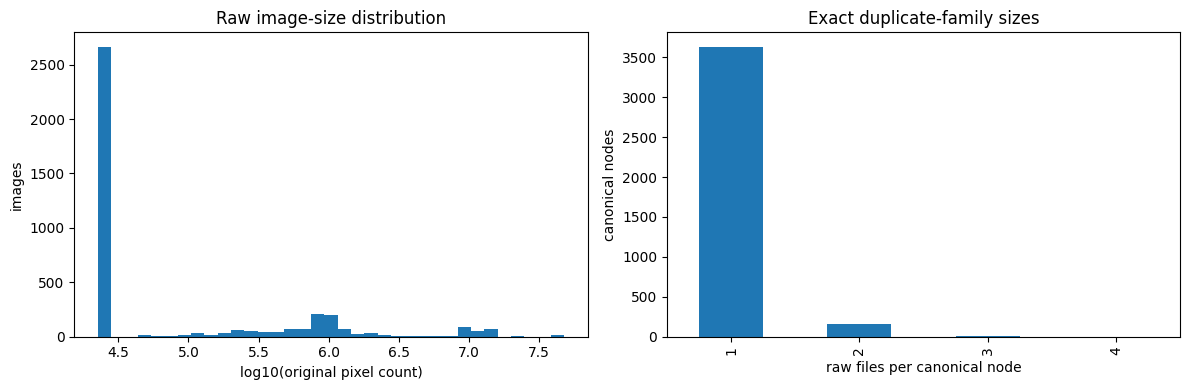

In [6]:
# 5. Ringkasan integritas dataset dan exact-duplicate.

DATASET_SUMMARY = pd.DataFrame([{'raw_files_discovered': len(files),
    'readable_images': len(RAW_MANIFEST),
    'corrupt_images': len(BAD),
    'canonical_nodes': N_CANONICAL,
    'exact_duplicate_files_collapsed': len(RAW_MANIFEST) - N_CANONICAL,
    'duplicate_families': len(DUP),
    'representation_fit_rows': len(FIT_IDX),
    'representation_holdout_rows': len(FIT_HOLDOUT_IDX),
    'cohort_fingerprint': COHORT_FP}])
display(DATASET_SUMMARY.T)
DATASET_SUMMARY.to_csv(OUT / 'metrics' / 'dataset_summary.csv', index=False)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(np.log10(np.maximum(RAW_MANIFEST.pixels.to_numpy(), 1)), bins=35)
axs[0].set_xlabel('log10(original pixel count)')
axs[0].set_ylabel('images')
axs[0].set_title('Raw image-size distribution')
CANONICAL_NODES.duplicate_count.value_counts().sort_index().plot(kind='bar', ax=axs[1])
axs[1].set_xlabel('raw files per canonical node')
axs[1].set_ylabel('canonical nodes')
axs[1].set_title('Exact duplicate-family sizes')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'dataset_duplicate_summary.png', dpi=170)
plt.show()


In [7]:
# 6. Cache fitur ter-fingerprint untuk run ini.

def snapshot_identity(root):
    """Collect local checkpoint metadata used in the fresh-run representation fingerprint."""
    root = Path(root)
    out = {'path': str(root)}
    for name in ['CIRCLE_STAGING.json', 'config.json', 'preprocessor_config.json']:
        p = root / name
        if p.is_file():
            out[name] = {'sha256': sha256_file(p), 'bytes': p.stat().st_size}
    weights = []
    for pat in ['*.safetensors', '*.pth', '*.tar']:
        for p in sorted(root.glob(pat)):
            weights.append({'name': p.name, 'bytes': p.stat().st_size})
    out['weight_files'] = weights
    return out
MODEL_IDENTITY = {'dino': snapshot_identity(DINO_DIR), 'cradio': snapshot_identity(CRADIO_DIR)}
FEATURE_FP = sha256_object({'representation': 'C-RADIO-slot1-PCA256 + DINO-hires-VLAD32-PCA512 + DINO-concepts512',
    'cohort': COHORT_FP,
    'models': MODEL_IDENTITY,
    'dino_short': DINO_SHORT,
    'dino_max_long': DINO_MAX_LONG,
    'patches_per_image': PATCHES_PER_IMAGE,
    'vlad_k': VLAD_K,
    'concept_k': CONCEPT_K,
    'fit_fraction': FIT_FRACTION})
CACHE_META = OUT / 'cache' / 'feature_cache.json'
FEATURES = {}
FEATURE_ORIGIN = {}
RESOURCE_PATHS = {}

def load_own_cache():
    """Load a complete representation cache only when it belongs to this exact fresh run."""
    if not CACHE_META.is_file():
        return False
    try:
        meta = json.loads(CACHE_META.read_text())
    except Exception:
        return False
    if meta.get('feature_fp') != FEATURE_FP or meta.get('cohort_fp') != COHORT_FP:
        return False
    arrays = meta.get('arrays', {})
    required = {'G', 'L', 'HSOFT', 'HFG', 'HBG', 'SPRAW', 'SCALARS'}
    if not required.issubset(arrays):
        return False
    for name in required:
        rec = arrays[name]
        p = Path(rec.get('path', ''))
        if not p.is_file() or (rec.get('sha256') and sha256_file(p) != rec['sha256']):
            return False
        validate_matrix(name, np.load(p, mmap_mode='r'), N_CANONICAL)
    for name in required:
        p = Path(arrays[name]['path'])
        FEATURES[name] = np.load(p, mmap_mode='r')
        FEATURE_ORIGIN[name] = 'fresh-run-cache'
    for k, vv in meta.get('resources', {}).items():
        p = Path(vv)
        if p.exists():
            RESOURCE_PATHS[k] = p
    print('[reuse] complete feature cache from this run only')
    return True

def load_partial_current_run():
    """Recover compatible partial artifacts from the same run after an interruption."""
    g = OUT / 'views' / 'G.npy'
    cm = OUT / 'cache' / 'cradio_complete.json'
    if g.is_file() and cm.is_file():
        try:
            if json.loads(cm.read_text()).get('feature_fp') == FEATURE_FP:
                x = np.load(g, mmap_mode='r')
                validate_matrix('G', x, N_CANONICAL)
                FEATURES['G'] = x
                FEATURE_ORIGIN['G'] = 'fresh-run-partial'
        except Exception:
            pass
    dcomp = OUT / 'cache' / 'dino_passB_complete.json'
    lp = OUT / 'views' / 'L.npy'
    dpaths = {'HFG': OUT / 'cache' / 'hist_fg.npy',
        'HBG': OUT / 'cache' / 'hist_bg.npy',
        'HSOFT': OUT / 'cache' / 'hist_soft_fg.npy',
        'SPRAW': OUT / 'cache' / 'spatial4_fg.npy',
        'SCALARS': OUT / 'cache' / 'scalars.npy'}
    if dcomp.is_file() and lp.is_file() and all((p.is_file() for p in dpaths.values())):
        try:
            if json.loads(dcomp.read_text()).get('feature_fp') == FEATURE_FP:
                x = np.load(lp, mmap_mode='r')
                validate_matrix('L', x, N_CANONICAL)
                FEATURES['L'] = x
                FEATURE_ORIGIN['L'] = 'fresh-run-partial'
                for name, p in dpaths.items():
                    x = np.load(p, mmap_mode='r')
                    validate_matrix(name, x, N_CANONICAL)
                    FEATURES[name] = x
                    FEATURE_ORIGIN[name] = 'fresh-run-partial'
        except Exception:
            pass
    local_resources = {'reservoir_mid': OUT / 'cache' / 'dino_reservoir_mid_f16.npy',
        'reservoir_late': OUT / 'cache' / 'dino_reservoir_late_f16.npy',
        'bbox': OUT / 'cache' / 'foreground_bbox.npy',
        'concept_mid_pca': OUT / 'models' / 'concept_mid_pca64.npz',
        'concept_late_pca': OUT / 'models' / 'concept_late_pca64.npz',
        'concept512_centers': OUT / 'models' / 'concept512_centers.npy',
        'vlad_patch_pca': OUT / 'models' / 'vlad_patch_pca64.npz',
        'vlad32_centers': OUT / 'models' / 'vlad32_centers.npy',
        'vlad_out_pca': OUT / 'models' / 'vlad32_pca512_alpha05.npz',
        'cradio_out_pca': OUT / 'models' / 'cradio_slot1_pca256.npz'}
    for k, p in local_resources.items():
        if p.is_file():
            RESOURCE_PATHS[k] = p
if not load_own_cache():
    load_partial_current_run()
print({k: (tuple(v.shape), FEATURE_ORIGIN[k]) for k, v in FEATURES.items()})


[reuse] complete feature cache from this run only
{'HFG': ((3793, 512), 'fresh-run-cache'), 'L': ((3793, 512), 'fresh-run-cache'), 'HBG': ((3793, 512), 'fresh-run-cache'), 'SCALARS': ((3793, 8), 'fresh-run-cache'), 'SPRAW': ((3793, 2048), 'fresh-run-cache'), 'G': ((3793, 256), 'fresh-run-cache'), 'HSOFT': ((3793, 512), 'fresh-run-cache')}


In [8]:
# 7. Utility resize citra dan pemeriksaan runtime model.

def choose_aspect_preserving_size(h, w, short, patch=16, max_long=1024):
    """Choose an aspect-preserving resolution compatible with the encoder patch step and long-side cap."""
    scale = float(short) / min(h, w)
    if max(h, w) * scale > max_long:
        scale = float(max_long) / max(h, w)
    th = max(patch, int(round(h * scale / patch)) * patch)
    tw = max(patch, int(round(w * scale / patch)) * patch)
    return (th, tw)

def resize_rgb_exact(im, h, w):
    """Resize an RGB PIL image to an exact height and width using high-quality Lanczos resampling."""
    return im.resize((int(w), int(h)), Image.Resampling.BICUBIC)

def _resolution_hw(value, target_hw=None):
    """Normalize C-RADIO resolution API variants to (height,width)."""
    if value is None:
        raise TypeError('resolution is None')
    if hasattr(value, 'height') and hasattr(value, 'width'):
        return (int(value.height), int(value.width))
    if isinstance(value, dict) and 'height' in value and ('width' in value):
        return (int(value['height']), int(value['width']))
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        if len(value) >= 2 and np.isscalar(value[0]) and np.isscalar(value[1]):
            return (int(value[0]), int(value[1]))
        candidates = []
        for item in value:
            try:
                candidates.append(_resolution_hw(item, target_hw))
            except Exception:
                pass
        if candidates:
            if target_hw is None:
                return candidates[0]
            th, tw = map(int, target_hw)
            return min(candidates, key=lambda hw: (hw[0] - th) ** 2 + (hw[1] - tw) ** 2)
    raise TypeError(f'Unsupported C-RADIO resolution object: {type(value).__name__}: {value!r}')

def cradio_supported_hw(model, height, width):
    near = model.get_nearest_supported_resolution(int(height), int(width))
    return _resolution_hw(near, (height, width))
need_cr = 'G' not in FEATURES
need_dino = any((k not in FEATURES for k in ['L', 'HSOFT', 'HFG', 'HBG', 'SPRAW', 'SCALARS']))
if (need_cr or need_dino) and (not torch.cuda.is_available()):
    raise RuntimeError('CUDA is required because compatible cached features are incomplete.')
if need_cr and (not (CRADIO_DIR / 'config.json').is_file()):
    raise FileNotFoundError(CRADIO_DIR)
if need_dino and (not (DINO_DIR / 'config.json').is_file()):
    raise FileNotFoundError(DINO_DIR)
print({'need_cradio': need_cr, 'need_dino': need_dino})


{'need_cradio': False, 'need_dino': False}


In [9]:
# 8. Ekstraksi C-RADIO summary-slot-1 dan global view PCA256.

if need_cr:
    cuda_healthcheck('Before loading whole-image C-RADIO')
    from timm.layers import set_fused_attn
    set_fused_attn(not CRADIO_DISABLE_FUSED_ATTN)
    from transformers import AutoModel, CLIPImageProcessor
    proc = CLIPImageProcessor.from_pretrained(CRADIO_DIR, local_files_only=True)
    model = AutoModel.from_pretrained(CRADIO_DIR,
        trust_remote_code=True,
        local_files_only=True,
        low_cpu_mem_usage=True).eval().to(DEVICE,
        dtype=torch.float32)
    for p in model.parameters():
        p.requires_grad_(False)
    if hasattr(model, 'input_conditioner') and hasattr(model.input_conditioner, 'dtype'):
        model.input_conditioner.dtype = torch.float32
    amp_dtype = torch.bfloat16 if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported() else torch.float32
    step = int(getattr(model, 'min_resolution_step', 16) or 16)
    raw_path = OUT / 'cache' / 'cradio_summary_slot1_raw.npy'
    progress = OUT / 'cache' / 'cradio_progress.json'
    complete = OUT / 'cache' / 'cradio_complete.json'
    stage_fp = sha256_object({'feature_fp': FEATURE_FP,
        'stage': 'cradio-summary-slot1',
        'short': CRADIO_SHORT,
        'max_long': CRADIO_MAX_LONG})
    start = 0
    raw = None
    if raw_path.is_file():
        try:
            raw = np.lib.format.open_memmap(raw_path, mode='r+')
            if raw.ndim != 2 or len(raw) != N_CANONICAL:
                raw = None
        except Exception:
            raw = None
    if raw is None:
        im = load_rgb_image(CANONICAL_NODES.iloc[0]['image_path'])
        th0, tw0 = choose_aspect_preserving_size(im.height, im.width, CRADIO_SHORT, step, CRADIO_MAX_LONG)
        th, tw = cradio_supported_hw(model, th0, tw0)
        gpu_attempt_log('cradio_whole_probe', 0, CANONICAL_NODES.iloc[0]['image_path'], (th, tw))
        x = proc(images=im,
            return_tensors='pt',
            do_resize=True,
            size={'height': th, 'width': tw},
            do_center_crop=False).pixel_values.to(DEVICE,
            dtype=torch.float32)
        with torch.inference_mode(), torch.autocast('cuda',
            dtype=amp_dtype,
            enabled=DEVICE.type == 'cuda' and amp_dtype != torch.float32):
            summary, _ = model(x)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        d = int(summary.shape[1])
        del x, summary
        if d % 2:
            raise RuntimeError(f'Expected even C-RADIO summary dimension, got {d}')
        slot = d // 2
        raw = np.lib.format.open_memmap(raw_path, mode='w+', dtype=np.float32, shape=(N_CANONICAL, slot))
        start = 0
    elif complete.is_file():
        try:
            start = N_CANONICAL if json.loads(complete.read_text()).get('stage_fp') == stage_fp else 0
        except Exception:
            start = 0
    elif progress.is_file():
        try:
            q = json.loads(progress.read_text())
            start = min(N_CANONICAL,
                max(0, int(q.get('next_index', 0)))) if q.get('stage_fp') == stage_fp else 0
        except Exception:
            start = 0
    else:
        start = 0
    if start:
        print('[resume] C-RADIO row', start, '/', N_CANONICAL)
    last_committed = start
    try:
        for i in range(start, N_CANONICAL):
            path = CANONICAL_NODES.iloc[i].image_path
            im = load_rgb_image(path)
            th0, tw0 = choose_aspect_preserving_size(im.height,
                im.width,
                CRADIO_SHORT,
                step,
                CRADIO_MAX_LONG)
            th, tw = cradio_supported_hw(model, th0, tw0)
            gpu_attempt_log('cradio_whole',
                i,
                path,
                (th, tw),
                {'source_hw': [int(im.height), int(im.width)], 'amp_dtype': str(amp_dtype), 'fused_attn': bool(not CRADIO_DISABLE_FUSED_ATTN)})
            x = proc(images=im,
                return_tensors='pt',
                do_resize=True,
                size={'height': th, 'width': tw},
                do_center_crop=False).pixel_values.to(DEVICE,
                dtype=torch.float32)
            with torch.inference_mode(), torch.autocast('cuda',
                dtype=amp_dtype,
                enabled=DEVICE.type == 'cuda' and amp_dtype != torch.float32):
                summary, _ = model(x)
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            s = summary.float().cpu().numpy()
            raw[i] = normalize_rows_l2(s[:, s.shape[1] // 2:])[0]
            del x, summary, s, im
            if (i + 1) % GPU_CHECKPOINT_EVERY == 0 or i + 1 == N_CANONICAL:
                raw.flush()
                last_committed = i + 1
                write_json_atomic(progress, {'stage_fp': stage_fp, 'next_index': last_committed})
                print('C-RADIO', last_committed, '/', N_CANONICAL)
    except Exception as e:
        try:
            raw.flush()
        except Exception:
            pass
        write_json_atomic(progress, {'stage_fp': stage_fp, 'next_index': int(last_committed)})
        rec = gpu_failure_log('cradio_whole',
            int(i) if 'i' in locals() else int(last_committed),
            CANONICAL_NODES.iloc[int(i) if 'i' in locals() else min(last_committed, N_CANONICAL - 1)].image_path,
            (th, tw) if 'th' in locals() else None,
            e,
            last_committed)
        raise RuntimeError(f"Whole-image C-RADIO failed at canonical index {rec['canonical_index']} after committed row {last_committed}. This is resumable. Restart the kernel before continuing; do not retry CUDA in the poisoned kernel. Failure record: {OUT / 'cache' / 'cradio_whole_failure.json'}. Original error: {e!r}") from e
    raw.flush()
    write_json_atomic(complete, {'feature_fp': FEATURE_FP, 'stage_fp': stage_fp, 'rows': N_CANONICAL})
    progress.unlink(missing_ok=True)
    CRADIO_WHOLE, pcaG = pca_alpha_fit_transform(raw, 256, FIT_IDX, alpha=0.0)
    save_pca(OUT / 'models' / 'cradio_slot1_pca256.npz', pcaG, 0.0)
    write_npy_atomic(OUT / 'views' / 'G.npy', CRADIO_WHOLE)
    FEATURES['G'] = CRADIO_WHOLE
    FEATURE_ORIGIN['G'] = 'computed-final'
    del model, proc, raw
    release_cuda_memory()
    print('G', CRADIO_WHOLE.shape)
if need_cr:
    RESOURCE_PATHS['cradio_out_pca'] = OUT / 'models' / 'cradio_slot1_pca256.npz'


In [10]:
# 9. Loader DINO resolusi tinggi, akses patch, dan proposal foreground deterministik.

def _otsu_threshold(x, bins=64):
    v = np.asarray(x, float).ravel()
    lo, hi = (float(v.min()), float(v.max()))
    if not np.isfinite(lo + hi) or hi <= lo + 1e-12:
        return float(np.median(v))
    hist, edges = np.histogram(v, bins=bins, range=(lo, hi))
    p = hist / max(hist.sum(), 1)
    cent = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(p)
    w1 = 1 - w0
    mu0 = np.cumsum(p * cent) / np.maximum(w0, 1e-12)
    mt = (p * cent).sum()
    mu1 = (mt - np.cumsum(p * cent)) / np.maximum(w1, 1e-12)
    score = w0 * w1 * (mu0 - mu1) ** 2
    return float(cent[int(np.nanargmax(score))])

def foreground_bbox_from_patches(patches, cls_vec, grid, pad=0.08):
    """Estimate a deterministic foreground bounding box from DINO patch activations."""
    gh, gw = grid
    p = normalize_rows_l2(patches)
    c = normalize_rows_l2(np.asarray(cls_vec).reshape(1, -1))[0]
    score = (p @ c).reshape(gh, gw)
    score = gaussian_filter(score, sigma=0.8)
    cand = []
    for t in [_otsu_threshold(score), float(np.quantile(score, 0.55)), float(np.quantile(score, 0.65))]:
        mask = score >= t
        if mask.mean() < 0.04 or mask.mean() > 0.95:
            continue
        lab, nc = cc_label(mask)
        comps = []
        for k in range(1, nc + 1):
            m = lab == k
            if m.sum() < max(2, 0.01 * mask.size):
                continue
            border = np.r_[m[0], m[-1], m[:, 0], m[:, -1]].mean()
            val = float(score[m].mean() + 0.2 * np.log1p(m.sum()) - 0.25 * border)
            comps.append((val, m))
        if comps:
            mask = max(comps, key=lambda q: q[0])[1]
        ys, xs = np.where(mask)
        if not len(xs):
            continue
        x0, x1 = (xs.min() / gw, (xs.max() + 1) / gw)
        y0, y1 = (ys.min() / gh, (ys.max() + 1) / gh)
        area = (x1 - x0) * (y1 - y0)
        centrality = 1 - (abs((x0 + x1) / 2 - 0.5) + abs((y0 + y1) / 2 - 0.5)) / 2
        conf = float(np.clip((score[mask].mean() - score.mean()) / (score.std() + 1e-06), 0, 3) / 3)
        qual = conf + 0.25 * centrality - 0.15 * abs(area - 0.55)
        cand.append((qual, (x0, y0, x1, y1, conf, area)))
    if not cand:
        return np.array([0, 0, 1, 1, 0, 1], np.float32)
    _, (x0, y0, x1, y1, conf, area) = max(cand, key=lambda q: q[0])
    dx = (x1 - x0) * pad
    dy = (y1 - y0) * pad
    return np.array([max(0, x0 - dx), max(0, y0 - dy), min(1, x1 + dx), min(1, y1 + dy), conf, area],
        np.float32)

def patch_mask_from_bbox(grid, b):
    """Convert a normalized foreground box into a boolean mask over a patch grid."""
    gh, gw = grid
    yy = (np.arange(gh) + 0.5) / gh
    xx = (np.arange(gw) + 0.5) / gw
    X, Y = np.meshgrid(xx, yy)
    return ((X >= b[0]) & (X <= b[2]) & (Y >= b[1]) & (Y <= b[3])).ravel()
if need_dino:
    from transformers import AutoImageProcessor, AutoModel
    DINO_PROC = AutoImageProcessor.from_pretrained(DINO_DIR, local_files_only=True)
    DINO_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    DINO_MODEL = AutoModel.from_pretrained(DINO_DIR,
        local_files_only=True,
        low_cpu_mem_usage=True,
        dtype=DINO_DTYPE,
        attn_implementation='sdpa').eval().to(DEVICE)
    for p in DINO_MODEL.parameters():
        p.requires_grad_(False)
    DINO_PATCH = int(getattr(DINO_MODEL.config, 'patch_size', 16))
    DINO_REG = int(getattr(DINO_MODEL.config, 'num_register_tokens', 0) or 0)
    DINO_DEPTH = int(DINO_MODEL.config.num_hidden_layers)
    DINO_HIDDEN = int(DINO_MODEL.config.hidden_size)
    DINO_MID = max(1, min(DINO_DEPTH, int(round(DINO_MID_FRACTION * DINO_DEPTH))))

    def dino_forward(im):
        """Run frozen DINO inference and return the middle/final patch representations used by this pipeline."""
        th, tw = choose_aspect_preserving_size(im.height, im.width, DINO_SHORT, DINO_PATCH, DINO_MAX_LONG)
        rr = resize_rgb_exact(im, th, tw)
        inp = DINO_PROC(images=rr, return_tensors='pt', do_resize=False, do_center_crop=False)
        x = inp.pixel_values.to(DEVICE, dtype=DINO_DTYPE)
        with torch.inference_mode():
            o = DINO_MODEL(pixel_values=x, output_hidden_states=True)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        npre = 1 + DINO_REG
        gh, gw = (th // DINO_PATCH, tw // DINO_PATCH)
        hf = o.last_hidden_state
        hs = o.hidden_states
        if len(hs) == DINO_DEPTH + 1:
            hm = hs[DINO_MID]
        elif len(hs) == DINO_DEPTH:
            hm = hs[DINO_MID - 1]
        else:
            raise RuntimeError(f'Unexpected DINO hidden-state count {len(hs)} for depth {DINO_DEPTH}')
        hm = DINO_MODEL.norm(hm)
        pf = hf[:, npre:][0].float().cpu().numpy().copy()
        pm = hm[:, npre:][0].float().cpu().numpy().copy()
        cls = normalize_rows_l2(hf[:, 0].float().cpu().numpy())[0].copy()
        if len(pf) != gh * gw:
            raise RuntimeError('DINO patch/grid mismatch')
        del x, o, hf, hs, hm
        return {'cls': cls, 'late': pf, 'mid': pm, 'grid': (gh, gw)}
    print({'DINO_depth': DINO_DEPTH,
        'mid_layer': DINO_MID,
        'hidden': DINO_HIDDEN,
        'dtype': str(DINO_DTYPE)})


In [11]:
# 10. DINO pass A: reservoir patch middle/late dan foreground boxes.

if need_dino:
    midp = OUT / 'cache' / 'dino_reservoir_mid_f16.npy'
    latep = OUT / 'cache' / 'dino_reservoir_late_f16.npy'
    bboxp = OUT / 'cache' / 'foreground_bbox.npy'
    prog = OUT / 'cache' / 'dino_passA_progress.json'
    completeA = OUT / 'cache' / 'dino_passA_complete.json'
    stage_fp = sha256_object({'feature_fp': FEATURE_FP,
        'stage': 'dino-passA',
        'patches_per_image': PATCHES_PER_IMAGE,
        'mid_fraction': DINO_MID_FRACTION})
    reuseA = False
    if midp.is_file() and latep.is_file() and bboxp.is_file() and completeA.is_file():
        try:
            qa = json.loads(completeA.read_text())
            rm = np.load(midp, mmap_mode='r')
            rl = np.load(latep, mmap_mode='r')
            bb = np.load(bboxp, mmap_mode='r')
            reuseA = qa.get('stage_fp') == stage_fp and rm.shape == (N_CANONICAL,
                PATCHES_PER_IMAGE,
                DINO_HIDDEN) and (rl.shape == (N_CANONICAL, PATCHES_PER_IMAGE, DINO_HIDDEN)) and (bb.shape == (N_CANONICAL, 6))
        except Exception:
            reuseA = False
    if reuseA:
        RMID = np.load(midp, mmap_mode='r')
        RLATE = np.load(latep, mmap_mode='r')
        FOREGROUND_BOXES = np.load(bboxp, mmap_mode='r')
        print('[reuse] DINO pass A')
    else:
        pm = Path(str(midp) + '.partial.npy')
        pl = Path(str(latep) + '.partial.npy')
        pb = Path(str(bboxp) + '.partial.npy')
        start = 0
        if prog.is_file():
            try:
                qp = json.loads(prog.read_text())
                start = int(qp.get('next_index', 0)) if qp.get('stage_fp') == stage_fp else 0
            except Exception:
                start = 0
        if start == 0:
            AM = np.lib.format.open_memmap(pm,
                mode='w+',
                dtype=np.float16,
                shape=(N_CANONICAL, PATCHES_PER_IMAGE, DINO_HIDDEN))
            AL = np.lib.format.open_memmap(pl,
                mode='w+',
                dtype=np.float16,
                shape=(N_CANONICAL, PATCHES_PER_IMAGE, DINO_HIDDEN))
            AB = np.lib.format.open_memmap(pb, mode='w+', dtype=np.float32, shape=(N_CANONICAL, 6))
        else:
            AM = np.lib.format.open_memmap(pm, mode='r+')
            AL = np.lib.format.open_memmap(pl, mode='r+')
            AB = np.lib.format.open_memmap(pb, mode='r+')
        if start:
            print('[resume] DINO pass A row', start, '/', N_CANONICAL)
        last_committed = start
        try:
            for i in range(start, N_CANONICAL):
                path = CANONICAL_NODES.iloc[i].image_path
                gpu_attempt_log('dino_passA', i, path, None)
                rec = dino_forward(load_rgb_image(path))
                b = foreground_bbox_from_patches(rec['late'], rec['cls'], rec['grid'])
                AB[i] = b
                rr = np.random.default_rng(SEED + i)
                sel = rr.choice(len(rec['late']),
                    size=PATCHES_PER_IMAGE,
                    replace=len(rec['late']) < PATCHES_PER_IMAGE)
                AM[i] = rec['mid'][sel].astype(np.float16)
                AL[i] = rec['late'][sel].astype(np.float16)
                if (i + 1) % GPU_CHECKPOINT_EVERY == 0 or i + 1 == N_CANONICAL:
                    AM.flush()
                    AL.flush()
                    AB.flush()
                    last_committed = i + 1
                    write_json_atomic(prog, {'stage_fp': stage_fp, 'next_index': last_committed})
                    print('DINO pass A', last_committed, '/', N_CANONICAL)
        except Exception as e:
            try:
                AM.flush()
                AL.flush()
                AB.flush()
            except Exception:
                pass
            write_json_atomic(prog, {'stage_fp': stage_fp, 'next_index': int(last_committed)})
            recf = gpu_failure_log('dino_passA',
                int(i) if 'i' in locals() else int(last_committed),
                CANONICAL_NODES.iloc[int(i) if 'i' in locals() else min(last_committed, N_CANONICAL - 1)].image_path,
                None,
                e,
                last_committed)
            raise RuntimeError(f"DINO pass A failed at canonical index {recf['canonical_index']} after committed row {last_committed}. Restart the kernel before resuming.") from e
        del AM, AL, AB
        os.replace(pm, midp)
        os.replace(pl, latep)
        os.replace(pb, bboxp)
        write_json_atomic(completeA, {'feature_fp': FEATURE_FP, 'stage_fp': stage_fp})
        prog.unlink(missing_ok=True)
        RMID = np.load(midp, mmap_mode='r')
        RLATE = np.load(latep, mmap_mode='r')
        FOREGROUND_BOXES = np.load(bboxp, mmap_mode='r')
if need_dino:
    RESOURCE_PATHS.update({'reservoir_mid': midp, 'reservoir_late': latep, 'bbox': bboxp})


In [12]:
# 11. Fit sistem patch pada cohort representation-fit: VLAD32 dan 512 visual concepts.

if need_dino:
    late_fit = np.asarray(RLATE[FIT_IDX], np.float32).reshape(-1, DINO_HIDDEN)
    maxfit = min(len(late_fit), 150000)
    sel = np.random.default_rng(SEED).choice(len(late_fit), maxfit, replace=False)
    late_fit = late_fit[sel]
    VLAD_PCA = PCA(n_components=PATCH_PCA_DIM, svd_solver='randomized', random_state=SEED).fit(late_fit)
    Z = normalize_rows_l2(VLAD_PCA.transform(late_fit))
    VLAD_KM = MiniBatchKMeans(n_clusters=VLAD_K,
        batch_size=4096,
        n_init=5,
        max_iter=300,
        reassignment_ratio=0.01,
        random_state=SEED + VLAD_K).fit(Z)
    VLAD_C = normalize_rows_l2(VLAD_KM.cluster_centers_).astype(np.float32)
    save_pca(OUT / 'models' / 'vlad_patch_pca64.npz', VLAD_PCA)
    np.save(OUT / 'models' / 'vlad32_centers.npy', VLAD_C)
    mid_fit = np.asarray(RMID[FIT_IDX], np.float32).reshape(-1, DINO_HIDDEN)
    late_fit2 = np.asarray(RLATE[FIT_IDX], np.float32).reshape(-1, DINO_HIDDEN)
    nfit = min(len(mid_fit), 150000)
    sel = np.random.default_rng(SEED + 91).choice(len(mid_fit), nfit, replace=False)
    mid_fit = mid_fit[sel]
    late_fit2 = late_fit2[sel]
    PCA_MID = PCA(n_components=64, svd_solver='randomized', random_state=SEED).fit(mid_fit)
    PCA_LATE = PCA(n_components=64, svd_solver='randomized', random_state=SEED).fit(late_fit2)
    DESC = normalize_rows_l2(np.c_[normalize_rows_l2(PCA_MID.transform(mid_fit)) / np.sqrt(2),
        normalize_rows_l2(PCA_LATE.transform(late_fit2)) / np.sqrt(2)])
    CONCEPT_KM = MiniBatchKMeans(n_clusters=CONCEPT_K,
        batch_size=4096,
        n_init=5,
        max_iter=300,
        reassignment_ratio=0.01,
        random_state=SEED + CONCEPT_K).fit(DESC)
    CONCEPT_C = normalize_rows_l2(CONCEPT_KM.cluster_centers_).astype(np.float32)
    save_pca(OUT / 'models' / 'concept_mid_pca64.npz', PCA_MID)
    save_pca(OUT / 'models' / 'concept_late_pca64.npz', PCA_LATE)
    np.save(OUT / 'models' / 'concept512_centers.npy', CONCEPT_C)
    print('VLAD/concept models fit:', VLAD_C.shape, CONCEPT_C.shape)
if need_dino:
    RESOURCE_PATHS.update({'vlad_patch_pca': OUT / 'models' / 'vlad_patch_pca64.npz',
        'vlad32_centers': OUT / 'models' / 'vlad32_centers.npy',
        'concept_mid_pca': OUT / 'models' / 'concept_mid_pca64.npz',
        'concept_late_pca': OUT / 'models' / 'concept_late_pca64.npz',
        'concept512_centers': OUT / 'models' / 'concept512_centers.npy'})
if need_dino:
    RESOURCE_PATHS.update({'vlad_patch_pca': OUT / 'models' / 'vlad_patch_pca64.npz',
        'vlad32_centers': OUT / 'models' / 'vlad32_centers.npy',
        'concept_mid_pca': OUT / 'models' / 'concept_mid_pca64.npz',
        'concept_late_pca': OUT / 'models' / 'concept_late_pca64.npz',
        'concept512_centers': OUT / 'models' / 'concept512_centers.npy'})


In [13]:
# 12. DINO pass B: VLAD, concepts foreground/background/soft, spatial concepts, dan composition scalars.

def vlad_encode(patches):
    """Aggregate patch descriptors into a residual VLAD descriptor using the frozen run-local codebook."""
    p = normalize_rows_l2(VLAD_PCA.transform(np.asarray(patches, np.float32)))
    assign = np.argmax(p @ VLAD_C.T, axis=1)
    V = np.zeros_like(VLAD_C, np.float32)
    for c in range(VLAD_K):
        m = assign == c
        if np.any(m):
            r = (p[m] - VLAD_C[c]).sum(0)
            nr = np.linalg.norm(r)
            V[c] = r / nr if nr > 1e-12 else r
    v = V.reshape(-1)
    v = np.sign(v) * np.sqrt(np.abs(v) + 1e-12)
    return normalize_rows_l2(v.reshape(1, -1))[0]

def patch_desc(mid, late):
    """Build the normalized middle+late DINO patch descriptor used by local representations."""
    return normalize_rows_l2(np.c_[normalize_rows_l2(PCA_MID.transform(np.asarray(mid, np.float32))) / np.sqrt(2),
        normalize_rows_l2(PCA_LATE.transform(np.asarray(late, np.float32))) / np.sqrt(2)])

def entropy_prob(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum()) if len(p) else 0.0

def js_div(p, q):
    p = np.asarray(p, float)
    q = np.asarray(q, float)
    p = p / max(p.sum(), 1e-12)
    q = q / max(q.sum(), 1e-12)
    m = 0.5 * (p + q)

    def kl(a, b):
        z = a > 0
        return float(np.sum(a[z] * np.log(a[z] / np.maximum(b[z], 1e-12))))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def spatial_hist(assign, grid, fg):
    gh, gw = grid
    yy = np.repeat(np.arange(gh), gw)
    xx = np.tile(np.arange(gw), gh)
    quad = (yy >= gh / 2).astype(int) * 2 + (xx >= gw / 2).astype(int)
    out = np.zeros((4, CONCEPT_K), np.float32)
    den = max(int(fg.sum()), 1)
    for q in range(4):
        out[q] = np.bincount(assign[fg & (quad == q)], minlength=CONCEPT_K) / den
    return out.reshape(-1)

def spatial_fragment(assign, grid, fg):
    gh, gw = grid
    yy = np.repeat(np.arange(gh), gw)
    xx = np.tile(np.arange(gw), gh)
    quad = (yy >= gh / 2).astype(int) * 2 + (xx >= gw / 2).astype(int)
    vals = []
    weights = []
    for c in np.unique(assign[fg]):
        ids = fg & (assign == c)
        cnt = np.array([(ids & (quad == q)).sum() for q in range(4)], float)
        tot = cnt.sum()
        if tot > 1:
            vals.append(entropy_prob(cnt / tot) / math.log(4))
            weights.append(tot)
    return float(np.average(vals, weights=weights)) if vals else 0.0
if need_dino:
    finals = {'VLAD_RAW': OUT / 'cache' / 'vlad32_raw.npy',
        'HFG': OUT / 'cache' / 'hist_fg.npy',
        'HBG': OUT / 'cache' / 'hist_bg.npy',
        'HSOFT': OUT / 'cache' / 'hist_soft_fg.npy',
        'SPRAW': OUT / 'cache' / 'spatial4_fg.npy',
        'SCALARS': OUT / 'cache' / 'scalars.npy'}
    prog = OUT / 'cache' / 'dino_passB_progress.json'
    complete = OUT / 'cache' / 'dino_passB_complete.json'
    if complete.is_file() and all((q.is_file() for q in finals.values())) and (json.loads(complete.read_text()).get('feature_fp') == FEATURE_FP):
        print('[reuse] DINO pass B')
    else:
        dims = {'VLAD_RAW': VLAD_K * PATCH_PCA_DIM,
            'HFG': CONCEPT_K,
            'HBG': CONCEPT_K,
            'HSOFT': CONCEPT_K,
            'SPRAW': 4 * CONCEPT_K,
            'SCALARS': 8}
        parts = {k: OUT / 'cache' / f'.{k}.passB.partial.npy' for k in dims}
        start = 0
        if prog.is_file():
            q = json.loads(prog.read_text())
            start = int(q.get('next_index', 0)) if q.get('feature_fp') == FEATURE_FP else 0
        if start == 0:
            arr = {k: np.lib.format.open_memmap(parts[k], mode='w+', dtype=np.float32, shape=(N_CANONICAL, d)) for k,
                d in dims.items()}
            write_json_atomic(prog, {'feature_fp': FEATURE_FP, 'next_index': 0})
        else:
            arr = {k: np.lib.format.open_memmap(parts[k], mode='r+') for k in dims}
            print('[resume] DINO pass B row', start, '/', N_CANONICAL)
        for i in range(start, N_CANONICAL):
            path = CANONICAL_NODES.iloc[i].image_path
            gpu_attempt_log('dino_passB', i, path, None)
            rec = dino_forward(load_rgb_image(path))
            arr['VLAD_RAW'][i] = vlad_encode(rec['late'])
            desc = patch_desc(rec['mid'], rec['late'])
            sim = desc @ CONCEPT_C.T
            assign = np.argmax(sim, axis=1)
            fg = patch_mask_from_bbox(rec['grid'], FOREGROUND_BOXES[i])
            if fg.sum() < max(4, 0.05 * len(fg)):
                fg[:] = True
            bg = ~fg
            hfg = np.bincount(assign[fg], minlength=CONCEPT_K).astype(np.float32)
            hfg /= max(hfg.sum(), 1)
            hbg = np.bincount(assign[bg],
                minlength=CONCEPT_K).astype(np.float32) if bg.any() else np.zeros(CONCEPT_K,
                np.float32)
            hbg /= max(hbg.sum(), 1) if hbg.sum() else 1
            top = np.argpartition(sim[fg], -3, axis=1)[:, -3:]
            ss = np.take_along_axis(sim[fg], top, axis=1)
            ww = np.exp((ss - ss.max(1, keepdims=True)) / 0.07)
            ww /= ww.sum(1, keepdims=True)
            soft = np.zeros(CONCEPT_K, np.float32)
            for rr in range(len(top)):
                np.add.at(soft, top[rr], ww[rr])
            soft /= max(soft.sum(), 1e-12)
            arr['HFG'][i] = hfg
            arr['HBG'][i] = hbg
            arr['HSOFT'][i] = soft
            arr['SPRAW'][i] = spatial_hist(assign, rec['grid'], fg)
            richness = float((hfg > 0.001).sum())
            dom = float(hfg.max())
            ff = float(fg.mean())
            full = np.bincount(assign, minlength=CONCEPT_K).astype(np.float32)
            full /= max(full.sum(), 1)
            ent_full = entropy_prob(full) / max(math.log(CONCEPT_K), 1)
            ent_fg = entropy_prob(hfg) / max(math.log(CONCEPT_K), 1)
            frag = spatial_fragment(assign, rec['grid'], fg)
            sample = desc[np.random.default_rng(SEED + i).choice(len(desc),
                min(64, len(desc)),
                replace=False)]
            ps = sample @ sample.T
            div = float(1 - (ps.sum() - len(sample)) / (len(sample) * (len(sample) - 1))) if len(sample) > 1 else 0
            arr['SCALARS'][i] = [ent_full,
                ent_fg,
                richness,
                dom,
                ff,
                js_div(hfg, hbg) if bg.any() else 0,
                frag,
                div]
            if (i + 1) % GPU_CHECKPOINT_EVERY == 0 or i + 1 == N_CANONICAL:
                for a in arr.values():
                    a.flush()
                write_json_atomic(prog, {'feature_fp': FEATURE_FP, 'next_index': i + 1})
                print('DINO pass B', i + 1, '/', N_CANONICAL)
        for a in arr.values():
            a.flush()
        del arr
        for k, q in parts.items():
            os.replace(q, finals[k])
        write_json_atomic(complete, {'feature_fp': FEATURE_FP})
        prog.unlink(missing_ok=True)
    RAW_VLAD = np.load(finals['VLAD_RAW'], mmap_mode='r')
    DINO_VLAD_WHOLE, pcaL = pca_alpha_fit_transform(RAW_VLAD, 512, FIT_IDX, alpha=0.5)
    save_pca(OUT / 'models' / 'vlad32_pca512_alpha05.npz', pcaL, 0.5)
    write_npy_atomic(OUT / 'views' / 'L.npy', DINO_VLAD_WHOLE)
    FEATURES['L'] = DINO_VLAD_WHOLE
    FEATURE_ORIGIN['L'] = 'computed-final'
    for key in ['HFG', 'HBG', 'HSOFT', 'SPRAW', 'SCALARS']:
        FEATURES[key] = np.load(finals[key], mmap_mode='r')
        FEATURE_ORIGIN[key] = 'computed-final'
    del DINO_MODEL, DINO_PROC, RMID, RLATE
    release_cuda_memory()
if need_dino:
    RESOURCE_PATHS['vlad_out_pca'] = OUT / 'models' / 'vlad32_pca512_alpha05.npz'


In [14]:
# 13. Simpan cache fitur setelah semua array wajib tervalidasi.

for req in ['G', 'L', 'HSOFT', 'HFG', 'HBG', 'SPRAW', 'SCALARS']:
    if req not in FEATURES:
        raise RuntimeError(f'Missing required feature {req}')
    validate_matrix(req, FEATURES[req], N_CANONICAL)
CRADIO_WHOLE = normalize_rows_l2(FEATURES['G'])
DINO_VLAD_WHOLE = normalize_rows_l2(FEATURES['L'])
DINO_CONCEPT_SOFT = np.asarray(FEATURES['HSOFT'], np.float32)
DINO_CONCEPT_FOREGROUND = np.asarray(FEATURES['HFG'], np.float32)
DINO_CONCEPT_BACKGROUND = np.asarray(FEATURES['HBG'], np.float32)
DINO_SPATIAL_CONCEPTS = np.asarray(FEATURES['SPRAW'], np.float32)
DINO_COMPOSITION_FEATURES = np.asarray(FEATURES['SCALARS'], np.float32)
arr_paths = {}
for name, x in [('G', CRADIO_WHOLE),
    ('L', DINO_VLAD_WHOLE),
    ('HSOFT', DINO_CONCEPT_SOFT),
    ('HFG', DINO_CONCEPT_FOREGROUND),
    ('HBG', DINO_CONCEPT_BACKGROUND),
    ('SPRAW', DINO_SPATIAL_CONCEPTS),
    ('SCALARS', DINO_COMPOSITION_FEATURES)]:
    p = OUT / 'views' / f'{name}.npy'
    write_npy_atomic(p, np.asarray(x, np.float32))
    arr_paths[name] = {'path': str(p),
        'sha256': sha256_file(p),
        'origin': FEATURE_ORIGIN[name],
        'shape': list(x.shape)}
write_json_atomic(CACHE_META,
    {'feature_fp': FEATURE_FP, 'cohort_fp': COHORT_FP, 'arrays': arr_paths, 'resources': {k: str(v) for k, v in RESOURCE_PATHS.items()}})
print(pd.DataFrame([{'view': k, 'shape': v.shape, 'origin': FEATURE_ORIGIN[k]} for k,
    v in [('G', CRADIO_WHOLE), ('L', DINO_VLAD_WHOLE), ('HSOFT', DINO_CONCEPT_SOFT), ('SPRAW', DINO_SPATIAL_CONCEPTS)]]))


    view         shape           origin
0      G   (3793, 256)  fresh-run-cache
1      L   (3793, 512)  fresh-run-cache
2  HSOFT   (3793, 512)  fresh-run-cache
3  SPRAW  (3793, 2048)  fresh-run-cache


In [15]:
# 14. Pemeriksaan integritas representasi dasar.

rep_rows = []
for name, X in [('G_whole', CRADIO_WHOLE), ('L_whole', DINO_VLAD_WHOLE)]:
    nrm = np.linalg.norm(np.asarray(X, np.float32), axis=1)
    rep_rows.append({'view': name,
        'rows': len(X),
        'dim': X.shape[1],
        'dtype': str(X.dtype),
        'finite': bool(np.isfinite(X).all()),
        'zero_norm_rows': int((nrm < 1e-08).sum()),
        'norm_mean': float(nrm.mean()),
        'norm_std': float(nrm.std())})
REP_INTEGRITY = pd.DataFrame(rep_rows)
display(REP_INTEGRITY)
REP_INTEGRITY.to_csv(OUT / 'metrics' / 'representation_integrity_base.csv', index=False)
assert REP_INTEGRITY.finite.all() and (REP_INTEGRITY.zero_norm_rows == 0).all()


,view,rows,dim,dtype,finite,zero_norm_rows,norm_mean,norm_std
0,G_whole,3793,256,float32,True,0,1.0,1.298449e-08
1,L_whole,3793,512,float32,True,0,1.0,6.120948e-09


## 2. Validation group untuk near-duplicate

Perceptual near-duplicate tetap dipertahankan sebagai node discovery yang berbeda, tetapi citra yang sangat mirip tidak boleh tersebar bebas di antara split resampling atau withholding. Karena itu, connected component dari neighbourhood pHash/dHash digunakan **hanya sebagai validation group**.

Definisi strict, primary, dan loose tetap dilaporkan sebagai sensitivity analysis. Definisi primary yang sudah ditetapkan digunakan pada tahap berikutnya.

**Output:** `VALIDATION_GROUPS` untuk resampling, withholding, confidence calibration, dan robustness analysis. Validation group tidak menentukan cluster membership.


In [16]:
# 15. Near-duplicate graph berbasis canonical hash dan cross-check EDA.

BITCOUNT8 = np.array([bin(i).count('1') for i in range(256)], dtype=np.uint8)

def hex64(s):
    return np.uint64(int(str(s), 16))
PH = np.array([hex64(x) for x in CANONICAL_NODES.phash if False],
    dtype=np.uint64) if 'phash' in CANONICAL_NODES.columns else None
parts = CANONICAL_NODES.duplicate_key.astype(str).str.split('__', n=1, expand=True)
PH = np.array([hex64(x) for x in parts[0]], dtype=np.uint64)
DH = np.array([hex64(x) for x in parts[1]], dtype=np.uint64)

def popcount_u64_matrix(x):
    x = np.ascontiguousarray(x, dtype=np.uint64)
    b = x.view(np.uint8).reshape(x.shape + (8,))
    return BITCOUNT8[b].sum(axis=-1, dtype=np.uint16)

def compute_near_duplicate_edges(rules, block=192):
    """Compute validation-only perceptual near-duplicate edges directly from canonical pHash/dHash values."""
    out = {k: [] for k in rules}
    Nn = len(PH)
    for i0 in range(0, Nn, block):
        i1 = min(i0 + block, Nn)
        pd = popcount_u64_matrix(PH[i0:i1, None] ^ PH[None, :])
        dd = popcount_u64_matrix(DH[i0:i1, None] ^ DH[None, :])
        rows = np.arange(i0, i1)[:, None]
        cols = np.arange(Nn)[None, :]
        upper = cols > rows
        for name, r in rules.items():
            m = upper & (pd <= r['pmax']) & (dd <= r['dmax']) & (pd + dd <= r['summax'])
            ii, jj = np.where(m)
            out[name].extend(((int(i0 + i), int(j), int(pd[i, j]), int(dd[i, j])) for i, j in zip(ii, jj)))
        if i1 % 768 == 0 or i1 == Nn:
            print('near-duplicate scan', i1, '/', Nn, {k: len(v) for k, v in out.items()})
    return out
NEAR_BY_RULE = compute_near_duplicate_edges(NEAR_DUP_RULES)

def connected_components_from_edges(n, edges):
    """Convert pairwise near-duplicate edges into validation-group connected components."""
    uf = list(range(n))

    def find(a):
        while uf[a] != a:
            uf[a] = uf[uf[a]]
            a = uf[a]
        return a

    def union(a, b):
        a, b = (find(a), find(b))
        if a != b:
            uf[b] = a
    for e in edges:
        union(int(e[0]), int(e[1]))
    roots = {}
    y = np.empty(n, np.int32)
    for i in range(n):
        r = find(i)
        roots.setdefault(r, len(roots))
        y[i] = roots[r]
    return y
VAL_GROUPS = {k: connected_components_from_edges(N_CANONICAL, v) for k, v in NEAR_BY_RULE.items()}
VALIDATION_GROUPS = VAL_GROUPS[VAL_GROUP_RULE]
rows = []
for name, e in NEAR_BY_RULE.items():
    y = VAL_GROUPS[name]
    sz = pd.Series(y).value_counts()
    rows.append({'rule': name,
        'edges': len(e),
        'components': len(sz),
        'non_singleton_components': int((sz > 1).sum()),
        'images_in_non_singletons': int(sz[sz > 1].sum()),
        'largest_component': int(sz.max())})
NEAR_SUM = pd.DataFrame(rows)
display(NEAR_SUM)
NEAR_SUM.to_csv(OUT / 'validation' / 'near_duplicate_sensitivity.csv', index=False)
pd.DataFrame(NEAR_BY_RULE[VAL_GROUP_RULE],
    columns=['canonical_a', 'canonical_b', 'phash_hamming', 'dhash_hamming']).to_csv(OUT / 'validation' / 'validation_near_duplicate_edges.csv',
    index=False)
pd.DataFrame({'canonical_index': np.arange(N_CANONICAL), 'validation_group_id': VALIDATION_GROUPS}).to_csv(OUT / 'manifests' / 'validation_groups.csv',
    index=False)
legacy = EDA_DIR / 'near_duplicate_pairs_train.csv'
audit = {'legacy_exists': legacy.is_file()}
if legacy.is_file():
    try:
        ed = pd.read_csv(legacy)
        audit.update({'legacy_rows': len(ed), 'columns': list(ed.columns)})
        pathcols = [c for c in ed.columns if 'path' in c.lower() or 'file' in c.lower()]
        audit['path_columns'] = pathcols
        rawkeys = set(RAW_TO_CANONICAL.rel_path.astype(str)) | set(RAW_TO_CANONICAL.raw_path.astype(str))
        rawbase = set((Path(x).name for x in rawkeys))
        audit['path_match_rates'] = {c: float(ed[c].astype(str).isin(rawkeys).mean()) for c in pathcols}
        audit['basename_match_rates'] = {c: float(ed[c].astype(str).map(lambda x: Path(x).name).isin(rawbase).mean()) for c in pathcols}
    except Exception as e:
        audit['legacy_error'] = repr(e)
write_json_atomic(OUT / 'validation' / 'near_duplicate_legacy_audit.json', audit)
print(audit)
assert all((not a == b for a, b, *_ in NEAR_BY_RULE[VAL_GROUP_RULE]))
assert len(VALIDATION_GROUPS) == N_CANONICAL and np.isfinite(VALIDATION_GROUPS).all()


near-duplicate scan 768 / 3793 {'strict': 35, 'primary': 38, 'loose': 44}
near-duplicate scan 1536 / 3793 {'strict': 64, 'primary': 74, 'loose': 91}
near-duplicate scan 2304 / 3793 {'strict': 89, 'primary': 104, 'loose': 123}
near-duplicate scan 3072 / 3793 {'strict': 106, 'primary': 121, 'loose': 141}
near-duplicate scan 3793 / 3793 {'strict': 112, 'primary': 127, 'loose': 147}


,rule,edges,components,non_singleton_components,images_in_non_singletons,largest_component
0,strict,112,3681,112,224,2
1,primary,127,3666,127,254,2
2,loose,147,3646,147,294,2


{'legacy_exists': True, 'legacy_rows': 4129, 'columns': ['hamming_distance', 'rel_path_a', 'class_a', 'rel_path_b', 'class_b', 'cross_label', 'dhash_a', 'dhash_b'], 'path_columns': ['rel_path_a', 'rel_path_b'], 'path_match_rates': {'rel_path_a': 0.0, 'rel_path_b': 0.0}, 'basename_match_rates': {'rel_path_a': 0.09493824170501332, 'rel_path_b': 0.14700896100750788}}


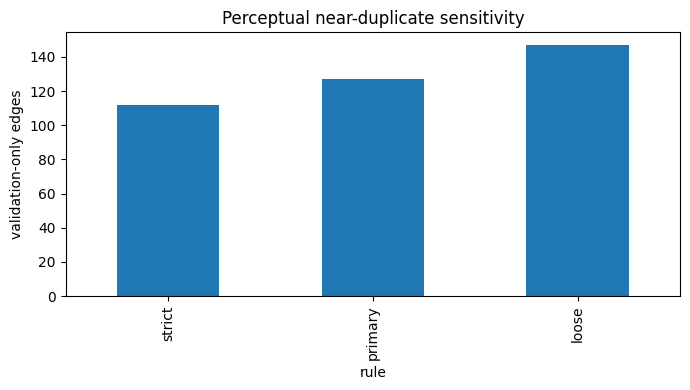

,rule,edges,components,non_singleton_components,images_in_non_singletons,largest_component
0,strict,112,3681,112,224,2
1,primary,127,3666,127,254,2
2,loose,147,3646,147,294,2


In [17]:
# 16. Sensitivity near-duplicate dan input montage audit.

fig, ax = plt.subplots(figsize=(7, 4))
NEAR_SUM.set_index('rule')['edges'].plot(kind='bar', ax=ax)
ax.set_ylabel('validation-only edges')
ax.set_title('Perceptual near-duplicate sensitivity')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'near_duplicate_sensitivity.png', dpi=160)
plt.show()
display(NEAR_SUM)


## 3. Representasi foreground

Pipeline mempertahankan dua sudut pandang: whole image dan foreground. Fitur foreground C-RADIO dan DINO-VLAD diproyeksikan menggunakan transformasi PCA/VLAD yang sama dengan whole-image view sehingga perbandingan whole ↔ foreground mencerminkan perubahan area citra, bukan perubahan sistem koordinat embedding.


In [18]:
# 17. Current-run transforms and foreground helpers. Historical artifact directories are never searched.

def local_resource(key, rel):
    p = RESOURCE_PATHS.get(key)
    if p is not None and Path(p).is_file():
        return Path(p)
    q = OUT / rel
    if q.is_file():
        RESOURCE_PATHS[key] = q
        return q
    return None
BBOX_PATH = local_resource('bbox', 'cache/foreground_bbox.npy')
CR_PCA_PATH = local_resource('cradio_out_pca', 'models/cradio_slot1_pca256.npz')
VLAD_PATCH_PCA_PATH = local_resource('vlad_patch_pca', 'models/vlad_patch_pca64.npz')
VLAD_CENTER_PATH = local_resource('vlad32_centers', 'models/vlad32_centers.npy')
VLAD_OUT_PATH = local_resource('vlad_out_pca', 'models/vlad32_pca512_alpha05.npz')
for name, p in {'bbox': BBOX_PATH,
    'cradio_pca': CR_PCA_PATH,
    'vlad_patch_pca': VLAD_PATCH_PCA_PATH,
    'vlad_centers': VLAD_CENTER_PATH,
    'vlad_out': VLAD_OUT_PATH}.items():
    if p is None:
        raise RuntimeError(f'Missing current-run resource {name}; rerun the preceding embedding stage.')
FOREGROUND_BOXES = np.load(BBOX_PATH, mmap_mode='r')
assert FOREGROUND_BOXES.shape == (N_CANONICAL, 6)

def load_npz_transform(path):
    z = np.load(path)
    return {k: z[k] for k in z.files}

def apply_npz_transform(X, z):
    Y = (np.asarray(X, np.float32) - z['mean']) @ z['components'].T
    alpha = float(z['alpha']) if 'alpha' in z else 0.0
    if alpha:
        Y *= np.power(np.maximum(z['explained_variance'], 1e-05), -0.5 * alpha)
    return normalize_rows_l2(Y)

def bbox_crop(im, b, margin=0.0):
    w, h = im.size
    x0, y0, x1, y1 = map(float, b[:4])
    if margin > 0:
        bw = max(x1 - x0, 1e-06)
        bh = max(y1 - y0, 1e-06)
        x0 -= margin * bw
        x1 += margin * bw
        y0 -= margin * bh
        y1 += margin * bh
    box = (int(np.clip(x0, 0, 1) * w),
        int(np.clip(y0, 0, 1) * h),
        int(np.clip(x1, 0, 1) * w),
        int(np.clip(y1, 0, 1) * h))
    return im.crop(box) if box[2] - box[0] >= 16 and box[3] - box[1] >= 16 else im.copy()

def letterbox_square(im, size=FOREGROUND_CANVAS, fill=FOREGROUND_FILL):
    x = ImageOps.contain(im.convert('RGB'), (int(size), int(size)), method=Image.Resampling.LANCZOS)
    canvas = Image.new('RGB', (int(size), int(size)), tuple(fill))
    canvas.paste(x, ((size - x.width) // 2, (size - x.height) // 2))
    return canvas

def foreground_canvas(im, b):
    """Crop the estimated foreground, add the fixed margin, and place it on the deterministic square canvas."""
    return letterbox_square(bbox_crop(im, b, FOREGROUND_MARGIN), FOREGROUND_CANVAS, FOREGROUND_FILL)

def load_cradio_safe():
    """Load C-RADIO with the validated runtime configuration for the 8-GB GPU environment."""
    cuda_healthcheck('Before loading C-RADIO')
    from timm.layers import set_fused_attn
    set_fused_attn(not CRADIO_DISABLE_FUSED_ATTN)
    from transformers import AutoModel, CLIPImageProcessor
    proc = CLIPImageProcessor.from_pretrained(CRADIO_DIR, local_files_only=True)
    model = AutoModel.from_pretrained(CRADIO_DIR,
        trust_remote_code=True,
        local_files_only=True,
        low_cpu_mem_usage=True).eval().to(DEVICE,
        dtype=torch.float32)
    for p in model.parameters():
        p.requires_grad_(False)
    if hasattr(model, 'input_conditioner') and hasattr(model.input_conditioner, 'dtype'):
        model.input_conditioner.dtype = torch.float32
    amp_dtype = torch.bfloat16 if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported() else torch.float32
    step = int(getattr(model, 'min_resolution_step', 16) or 16)
    return (model, proc, amp_dtype, step)

def _resolution_hw(value, target_hw=None):
    if value is None:
        raise TypeError('resolution is None')
    if hasattr(value, 'height') and hasattr(value, 'width'):
        return (int(value.height), int(value.width))
    if isinstance(value, dict) and 'height' in value and ('width' in value):
        return (int(value['height']), int(value['width']))
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        if len(value) >= 2 and np.isscalar(value[0]) and np.isscalar(value[1]):
            return (int(value[0]), int(value[1]))
        candidates = []
        for item in value:
            try:
                candidates.append(_resolution_hw(item, target_hw))
            except Exception:
                pass
        if candidates:
            if target_hw is None:
                return candidates[0]
            th, tw = map(int, target_hw)
            return min(candidates, key=lambda hw: (hw[0] - th) ** 2 + (hw[1] - tw) ** 2)
    raise TypeError(f'Unsupported C-RADIO resolution object: {type(value).__name__}: {value!r}')

def cradio_supported_hw(model, height, width):
    return _resolution_hw(model.get_nearest_supported_resolution(int(height), int(width)), (height, width))

def cradio_embed_pca(model, proc, cpca, im, amp_dtype, step, fixed_preferred=False):
    """Encode one image with C-RADIO slot-1 and project it through the run-local PCA transform."""
    if fixed_preferred:
        th, tw = cradio_supported_hw(model, FOREGROUND_CANVAS, FOREGROUND_CANVAS)
    else:
        th0, tw0 = choose_aspect_preserving_size(im.height, im.width, CRADIO_SHORT, step, CRADIO_MAX_LONG)
        th, tw = cradio_supported_hw(model, th0, tw0)
    x = proc(images=im,
        return_tensors='pt',
        do_resize=True,
        size={'height': int(th), 'width': int(tw)},
        do_center_crop=False).pixel_values.to(DEVICE,
        dtype=torch.float32)
    with torch.inference_mode(), torch.autocast('cuda',
        dtype=amp_dtype,
        enabled=DEVICE.type == 'cuda' and amp_dtype != torch.float32):
        summary, _ = model(x)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    sc = summary.float().cpu().numpy()
    if sc.ndim != 2 or sc.shape[1] % 2 != 0:
        raise RuntimeError(f'Unexpected C-RADIO summary shape {sc.shape}')
    raw = normalize_rows_l2(sc[:, sc.shape[1] // 2:])
    del x, summary, sc
    return apply_npz_transform(raw, cpca)[0]
print({k: str(v) for k,
    v in {'bbox': BBOX_PATH, 'cradio_pca': CR_PCA_PATH, 'vlad_patch_pca': VLAD_PATCH_PCA_PATH, 'vlad_centers': VLAD_CENTER_PATH, 'vlad_out': VLAD_OUT_PATH}.items()})


{'bbox': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/cache/foreground_bbox.npy', 'cradio_pca': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/models/cradio_slot1_pca256.npz', 'vlad_patch_pca': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/models/vlad_patch_pca64.npz', 'vlad_centers': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/models/vlad32_centers.npy', 'vlad_out': '/home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/models/vlad32_pca512_alpha05.npz'}


In [19]:
# 18. Foreground-object C-RADIO Gf. Same frozen model/PCA, robust preferred-resolution letterbox preprocessing.

GF_PATH = OUT / 'views' / 'G_foreground.npy'
GF_META = OUT / 'cache' / 'G_foreground_complete.json'
GF_FP = sha256_object({'cohort': COHORT_FP,
    'feature': FEATURE_FP,
    'bbox_sha': sha256_file(BBOX_PATH),
    'cr_pca': sha256_file(CR_PCA_PATH) if CR_PCA_PATH else None,
    'foreground_preproc': FOREGROUND_PREPROC_VERSION,
    'fused_attn': not CRADIO_DISABLE_FUSED_ATTN})
if RUN_FOREGROUND_EMBEDDINGS:
    ok = False
    if GF_PATH.is_file() and GF_META.is_file():
        try:
            ok = json.loads(GF_META.read_text()).get('fp') == GF_FP and tuple(np.load(GF_PATH, mmap_mode='r').shape) == (N_CANONICAL,
                CRADIO_WHOLE.shape[1])
        except Exception:
            ok = False
    if ok:
        CRADIO_FOREGROUND = normalize_rows_l2(np.load(GF_PATH, mmap_mode='r'))
        print('[reuse] G foreground')
    else:
        if CR_PCA_PATH is None:
            raise RuntimeError('C-RADIO PCA transform missing; cannot make comparable foreground G.')
        model = proc = None
        cpca = load_npz_transform(CR_PCA_PATH)
        part = OUT / 'cache' / '.G_foreground.partial.npy'
        prog = OUT / 'cache' / 'G_foreground_progress.json'
        start = 0
        if prog.is_file() and part.is_file():
            try:
                q = json.loads(prog.read_text())
                start = int(q.get('next_index', 0)) if q.get('fp') == GF_FP else 0
            except Exception:
                start = 0
        if start == 0:
            part.unlink(missing_ok=True)
        MM = np.lib.format.open_memmap(part,
            mode='r+' if start and part.is_file() else 'w+',
            dtype=np.float32,
            shape=(N_CANONICAL, CRADIO_WHOLE.shape[1]))
        try:
            model, proc, amp_dtype, step = load_cradio_safe()
            _fhw = cradio_supported_hw(model, FOREGROUND_CANVAS, FOREGROUND_CANVAS)
            print('C-RADIO foreground supported resolution', _fhw)
            for i in range(start, N_CANONICAL):
                im = foreground_canvas(load_rgb_image(CANONICAL_NODES.iloc[i].image_path),
                    FOREGROUND_BOXES[i])
                MM[i] = cradio_embed_pca(model, proc, cpca, im, amp_dtype, step, fixed_preferred=True)
                if (i + 1) % GPU_CHECKPOINT_EVERY == 0 or i + 1 == N_CANONICAL:
                    MM.flush()
                    write_json_atomic(prog, {'fp': GF_FP, 'next_index': i + 1})
                    print('G foreground', i + 1, '/', N_CANONICAL)
        except Exception as e:
            MM.flush()
            write_json_atomic(prog,
                {'fp': GF_FP, 'next_index': i if 'i' in locals() else start, 'failed_index': int(i) if 'i' in locals() else None, 'error': repr(e)})
            raise RuntimeError(f"Foreground C-RADIO failed at canonical index {(int(i) if 'i' in locals() else start)}. The stage is resumable. If this is a CUDA/AcceleratorError, restart the kernel before resuming. Original: {e!r}") from e
        finally:
            try:
                del model, proc
            except Exception:
                pass
            release_cuda_memory()
        MM.flush()
        del MM
        os.replace(part, GF_PATH)
        write_json_atomic(GF_META, {'fp': GF_FP, 'foreground_preproc': FOREGROUND_PREPROC_VERSION})
        prog.unlink(missing_ok=True)
        CRADIO_FOREGROUND = normalize_rows_l2(np.load(GF_PATH, mmap_mode='r'))
else:
    CRADIO_FOREGROUND = CRADIO_WHOLE.copy()
validate_matrix('GF', CRADIO_FOREGROUND, N_CANONICAL)


[reuse] G foreground


In [20]:
# 19. Foreground-object DINO VLAD Lf. Same frozen patch/VLAD transforms on an aspect-preserving object crop.

LF_PATH = OUT / 'views' / 'L_foreground.npy'
LF_META = OUT / 'cache' / 'L_foreground_complete.json'
LF_FP = sha256_object({'cohort': COHORT_FP,
    'feature': FEATURE_FP,
    'bbox_sha': sha256_file(BBOX_PATH),
    'vpca': sha256_file(VLAD_PATCH_PCA_PATH) if VLAD_PATCH_PCA_PATH else None,
    'centers': sha256_file(VLAD_CENTER_PATH) if VLAD_CENTER_PATH else None,
    'out': sha256_file(VLAD_OUT_PATH) if VLAD_OUT_PATH else None,
    'foreground_preproc': FOREGROUND_DINO_PREPROC_VERSION})
if RUN_FOREGROUND_EMBEDDINGS:
    ok = False
    if LF_PATH.is_file() and LF_META.is_file():
        try:
            ok = json.loads(LF_META.read_text()).get('fp') == LF_FP and tuple(np.load(LF_PATH, mmap_mode='r').shape) == (N_CANONICAL,
                DINO_VLAD_WHOLE.shape[1])
        except Exception:
            ok = False
    if ok:
        DINO_VLAD_FOREGROUND = normalize_rows_l2(np.load(LF_PATH, mmap_mode='r'))
        print('[reuse] L foreground')
    else:
        if not all([VLAD_PATCH_PCA_PATH, VLAD_CENTER_PATH, VLAD_OUT_PATH]):
            raise RuntimeError('Frozen DINO/VLAD transforms missing; cannot make comparable foreground L.')
        cuda_healthcheck('Before loading foreground DINO')
        from transformers import AutoImageProcessor, AutoModel
        dproc = AutoImageProcessor.from_pretrained(DINO_DIR, local_files_only=True)
        ddtype = torch.bfloat16 if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported() else torch.float16 if DEVICE.type == 'cuda' else torch.float32
        dmodel = AutoModel.from_pretrained(DINO_DIR,
            local_files_only=True,
            low_cpu_mem_usage=True,
            dtype=ddtype,
            attn_implementation='sdpa').eval().to(DEVICE)
        for p in dmodel.parameters():
            p.requires_grad_(False)
        patch = int(getattr(dmodel.config, 'patch_size', 16))
        reg = int(getattr(dmodel.config, 'num_register_tokens', 0) or 0)
        vpca = load_npz_transform(VLAD_PATCH_PCA_PATH)
        cent = normalize_rows_l2(np.load(VLAD_CENTER_PATH))
        opca = load_npz_transform(VLAD_OUT_PATH)
        part = OUT / 'cache' / '.L_foreground.partial.npy'
        prog = OUT / 'cache' / 'L_foreground_progress.json'
        start = 0
        if prog.is_file() and part.is_file():
            try:
                q = json.loads(prog.read_text())
                start = int(q.get('next_index', 0)) if q.get('fp') == LF_FP else 0
            except Exception:
                start = 0
        if start == 0:
            part.unlink(missing_ok=True)
        MM = np.lib.format.open_memmap(part,
            mode='r+' if start and part.is_file() else 'w+',
            dtype=np.float32,
            shape=(N_CANONICAL, DINO_VLAD_WHOLE.shape[1]))
        try:
            for i in range(start, N_CANONICAL):
                im = bbox_crop(load_rgb_image(CANONICAL_NODES.iloc[i].image_path),
                    FOREGROUND_BOXES[i],
                    FOREGROUND_MARGIN)
                th, tw = choose_aspect_preserving_size(im.height,
                    im.width,
                    DINO_SHORT,
                    patch,
                    DINO_MAX_LONG)
                rr = resize_rgb_exact(im, th, tw)
                x = dproc(images=rr,
                    return_tensors='pt',
                    do_resize=False,
                    do_center_crop=False).pixel_values.to(DEVICE,
                    dtype=ddtype)
                with torch.inference_mode():
                    o = dmodel(pixel_values=x)
                if DEVICE.type == 'cuda':
                    torch.cuda.synchronize()
                tok = o.last_hidden_state[:, 1 + reg:][0].float().cpu().numpy()
                pz = apply_npz_transform(tok, vpca)
                assign = np.argmax(pz @ cent.T, axis=1)
                V = np.zeros_like(cent, np.float32)
                for cc in range(len(cent)):
                    m = assign == cc
                    if m.any():
                        r = (pz[m] - cent[cc]).sum(0)
                        V[cc] = r / max(np.linalg.norm(r), 1e-12)
                v = V.reshape(-1)
                v = np.sign(v) * np.sqrt(np.abs(v) + 1e-12)
                MM[i] = apply_npz_transform(normalize_rows_l2(v.reshape(1, -1)), opca)[0]
                del x, o
                if (i + 1) % 20 == 0 or i + 1 == N_CANONICAL:
                    MM.flush()
                    write_json_atomic(prog, {'fp': LF_FP, 'next_index': i + 1})
                    print('L foreground', i + 1, '/', N_CANONICAL)
        except Exception as e:
            MM.flush()
            write_json_atomic(prog,
                {'fp': LF_FP, 'next_index': i if 'i' in locals() else start, 'failed_index': int(i) if 'i' in locals() else None, 'error': repr(e)})
            raise RuntimeError(f"Foreground DINO failed at canonical index {(int(i) if 'i' in locals() else start)}. The stage is resumable. Restart the kernel after any CUDA/AcceleratorError. Original: {e!r}") from e
        finally:
            try:
                del dmodel, dproc
            except Exception:
                pass
            release_cuda_memory()
        MM.flush()
        del MM
        os.replace(part, LF_PATH)
        write_json_atomic(LF_META, {'fp': LF_FP, 'foreground_preproc': FOREGROUND_DINO_PREPROC_VERSION})
        prog.unlink(missing_ok=True)
        DINO_VLAD_FOREGROUND = normalize_rows_l2(np.load(LF_PATH, mmap_mode='r'))
else:
    DINO_VLAD_FOREGROUND = DINO_VLAD_WHOLE.copy()
validate_matrix('LF', DINO_VLAD_FOREGROUND, N_CANONICAL)
CRADIO_DUAL = normalize_rows_l2(np.c_[CRADIO_WHOLE / np.sqrt(2), CRADIO_FOREGROUND / np.sqrt(2)])
DINO_VLAD_DUAL = normalize_rows_l2(np.c_[DINO_VLAD_WHOLE / np.sqrt(2), DINO_VLAD_FOREGROUND / np.sqrt(2)])


[reuse] L foreground


## 4. Audit representasi dan pemeriksaan nearest-neighbour

Tahap diagnostik ini memeriksa integritas numerik, geometri representasi, keterprediksian background/acquisition, konsistensi whole ↔ foreground, serta koherensi visual nearest-neighbour sebelum pemilihan cluster final.

Metadata audit tidak dimasukkan ke embedding. Output tahap ini hanya digunakan untuk mengevaluasi kualitas representasi dan mendukung keputusan metode berikutnya.


In [21]:
# 20. Appearance/acquisition audit features. These NEVER enter clustering.

APP_PATH = OUT / 'cache' / 'appearance_audit.npy'
if APP_PATH.is_file():
    APPEAR = np.load(APP_PATH)
else:
    APPEAR = np.zeros((N_CANONICAL, 9), np.float32)
    for i, r in CANONICAL_NODES.iterrows():
        im = load_rgb_image(r.image_path)
        im.thumbnail((160, 160), Image.Resampling.BILINEAR)
        a = np.asarray(im, np.float32) / 255.0
        gray = 0.299 * a[..., 0] + 0.587 * a[..., 1] + 0.114 * a[..., 2]
        mx = a.max(-1)
        mn = a.min(-1)
        sat = (mx - mn) / np.maximum(mx, 1e-06)
        gx = np.diff(gray, axis=1)
        gy = np.diff(gray, axis=0)
        edge = (np.mean(np.abs(gx)) + np.mean(np.abs(gy))) / 2
        hist = np.histogram(gray, bins=32, range=(0, 1), density=False)[0].astype(float)
        p = hist / max(hist.sum(), 1)
        ent = float(-(p[p > 0] * np.log(p[p > 0])).sum() / np.log(32))
        color = np.sqrt(np.var(a[..., 0] - a[..., 1]) + np.var(0.5 * (a[..., 0] + a[..., 1]) - a[..., 2]))
        APPEAR[i] = [gray.mean(),
            gray.std(),
            (gray < 0.15).mean(),
            (gray > 0.85).mean(),
            sat.mean(),
            edge,
            ent,
            color,
            np.var(gx) + np.var(gy)]
        if (i + 1) % 500 == 0:
            print('appearance', i + 1, '/', N_CANONICAL)
    np.save(APP_PATH, APPEAR)
bg = np.asarray(DINO_CONCEPT_BACKGROUND, np.float32).copy()
ok = bg.sum(1) > 1e-08
if ok.any():
    bg[~ok] = bg[ok].mean(0)
bgpc = PCA(n_components=min(8, bg.shape[1], N_CANONICAL - 1), random_state=SEED).fit_transform(bg)
META = np.c_[np.log1p(CANONICAL_NODES.pixels.to_numpy()),
    np.log1p(CANONICAL_NODES.file_size.to_numpy()),
    np.log(np.maximum(CANONICAL_NODES.width / CANONICAL_NODES.height, 1e-06)),
    DINO_COMPOSITION_FEATURES[:, 4]]
NUISANCE_X = StandardScaler().fit_transform(np.c_[APPEAR, META, bgpc])
np.save(OUT / 'validation' / 'nuisance_audit_features.npy', NUISANCE_X)

def nuisance_probe(ids, y):
    """Measure audit-only acquisition/source predictability; the result never enters clustering."""
    ids = np.asarray(ids)
    y = np.asarray(y)
    m = y >= 0
    ids = ids[m]
    y = y[m]
    if len(np.unique(y)) < 2:
        return np.nan
    groups = VALIDATION_GROUPS[ids]
    ng = len(np.unique(groups))
    splits = min(5, ng)
    if splits < 2:
        return np.nan
    cv = GroupKFold(n_splits=splits)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5, random_state=SEED))
    try:
        pred = cross_val_predict(model, NUISANCE_X[ids], y, groups=groups, cv=cv)
    except ValueError:
        return np.nan
    return float(balanced_accuracy_score(y, pred))


In [22]:
# 21. Representation audit: geometry, original↔foreground persistence, and nuisance encoding.

def effective_rank(X):
    """Estimate representation effective rank from the normalized covariance spectrum."""
    ids = np.random.default_rng(SEED).choice(len(X), min(1500, len(X)), replace=False)
    z = np.asarray(X[ids], np.float32) - np.asarray(X[ids], np.float32).mean(0)
    s = np.linalg.svd(z, compute_uv=False)
    p = s * s / max((s * s).sum(), 1e-12)
    return float(np.exp(-(p[p > 0] * np.log(p[p > 0])).sum()))

def nn_overlap(A, B, k=20):
    """Measure nearest-neighbour overlap between two representation views."""
    IA = NearestNeighbors(n_neighbors=k + 1,
        metric='cosine',
        algorithm='brute').fit(A).kneighbors(A,
        return_distance=False)[:,
        1:]
    IB = NearestNeighbors(n_neighbors=k + 1,
        metric='cosine',
        algorithm='brute').fit(B).kneighbors(B,
        return_distance=False)[:,
        1:]
    return float(np.mean([len(set(a) & set(b)) / k for a, b in zip(IA, IB)]))

def pair_geometry_corr(A, B, n=30000):
    """Measure correlation between pairwise cosine geometry in two representations."""
    r = np.random.default_rng(SEED)
    i = r.integers(0, len(A), n)
    j = r.integers(0, len(A), n)
    x = np.sum(A[i] * A[j], axis=1)
    y = np.sum(B[i] * B[j], axis=1)
    return float(np.corrcoef(x, y)[0, 1])

def nuisance_from_rep(X, maxdim=64):
    Z = PCA(n_components=min(maxdim, X.shape[1], N_CANONICAL - 1),
        random_state=SEED).fit_transform(np.asarray(X, np.float32))
    groups = VALIDATION_GROUPS
    ng = len(np.unique(groups))
    cv = GroupKFold(n_splits=min(5, ng))
    vals = []
    for j in range(NUISANCE_X.shape[1]):
        try:
            pred = cross_val_predict(Ridge(alpha=10.0), Z, NUISANCE_X[:, j], groups=groups, cv=cv)
            vals.append(max(-1.0, r2_score(NUISANCE_X[:, j], pred)))
        except Exception:
            vals.append(np.nan)
    return (float(np.nanmedian(vals)), float(np.nanquantile(vals, 0.9)))
VIEW_AUDIT = []
for name, X in [('G_whole', CRADIO_WHOLE),
    ('G_foreground', CRADIO_FOREGROUND),
    ('G_dual', CRADIO_DUAL),
    ('L_whole', DINO_VLAD_WHOLE),
    ('L_foreground', DINO_VLAD_FOREGROUND),
    ('L_dual', DINO_VLAD_DUAL)]:
    med, q90 = nuisance_from_rep(X)
    VIEW_AUDIT.append({'view': name,
        'dim': X.shape[1],
        'effective_rank': effective_rank(X),
        'nuisance_r2_median': med,
        'nuisance_r2_q90': q90})
VIEW_AUDIT = pd.DataFrame(VIEW_AUDIT)
display(VIEW_AUDIT)
VIEW_AUDIT.to_csv(OUT / 'metrics' / 'representation_audit.csv', index=False)
CROSS_VIEW = pd.DataFrame([{'pair': 'G whole↔foreground', 'nn20_overlap': nn_overlap(CRADIO_WHOLE, CRADIO_FOREGROUND), 'geometry_corr': pair_geometry_corr(CRADIO_WHOLE, CRADIO_FOREGROUND)},
    {'pair': 'L whole↔foreground', 'nn20_overlap': nn_overlap(DINO_VLAD_WHOLE, DINO_VLAD_FOREGROUND), 'geometry_corr': pair_geometry_corr(DINO_VLAD_WHOLE, DINO_VLAD_FOREGROUND)}])
display(CROSS_VIEW)
CROSS_VIEW.to_csv(OUT / 'metrics' / 'foreground_persistence.csv', index=False)


,view,dim,effective_rank,nuisance_r2_median,nuisance_r2_q90
0,G_whole,256,47.651009,0.358230,0.608880
1,G_foreground,256,46.624043,0.353060,0.574970
2,G_dual,512,48.830189,0.358942,0.594505
3,L_whole,512,346.052032,0.582764,0.753935
4,L_foreground,512,313.000824,0.528737,0.730093
5,L_dual,1024,421.326813,0.568209,0.742795


,pair,nn20_overlap,geometry_corr
0,G whole↔foreground,0.787424,0.987914
1,L whole↔foreground,0.550316,0.765145


In [23]:
# 22. Final representation integrity + nearest-neighbour qualitative audit.

rows = []
for name, X in [('G_whole', CRADIO_WHOLE),
    ('G_foreground', CRADIO_FOREGROUND),
    ('G_dual', CRADIO_DUAL),
    ('L_whole', DINO_VLAD_WHOLE),
    ('L_foreground', DINO_VLAD_FOREGROUND),
    ('L_dual', DINO_VLAD_DUAL)]:
    nrm = np.linalg.norm(np.asarray(X, np.float32), axis=1)
    rows.append({'view': name,
        'rows': len(X),
        'dim': X.shape[1],
        'finite': bool(np.isfinite(X).all()),
        'zero_norm_rows': int((nrm < 1e-08).sum()),
        'norm_mean': float(nrm.mean()),
        'norm_std': float(nrm.std())})
REP_INTEGRITY_ALL = pd.DataFrame(rows)
REP_INTEGRITY_ALL.to_csv(OUT / 'metrics' / 'representation_integrity_all.csv', index=False)
display(REP_INTEGRITY_ALL)
assert REP_INTEGRITY_ALL.finite.all() and (REP_INTEGRITY_ALL.zero_norm_rows == 0).all()

def fit_tile(im, size=120):
    x = im.copy()
    x.thumbnail((size, size), Image.Resampling.LANCZOS)
    c = Image.new('RGB', (size, size), 'white')
    c.paste(x, ((size - x.width) // 2, (size - x.height) // 2))
    return c

def nn_audit_sheet(name, X, anchors, path, k=6, tile=120):
    nn = NearestNeighbors(n_neighbors=min(k + 1, len(X)), metric='cosine', algorithm='brute').fit(X)
    I = nn.kneighbors(X[anchors], return_distance=False)
    can = Image.new('RGB', ((k + 1) * tile, len(anchors) * (tile + 18) + 25), 'white')
    dr = ImageDraw.Draw(can)
    dr.text((4, 4), name, fill='black')
    for r, (a, row) in enumerate(zip(anchors, I)):
        y = 25 + r * (tile + 18)
        for j, i in enumerate(row):
            can.paste(fit_tile(load_rgb_image(CANONICAL_NODES.iloc[int(i)].image_path), tile),
                (j * tile, y))
            dr.text((j * tile + 2, y + tile), ('A ' if j == 0 else '') + str(int(i)), fill='black')
    can.save(path, quality=90)
anchors = np.random.default_rng(SEED + 222).choice(N_CANONICAL, min(8, N_CANONICAL), replace=False)
nn_audit_sheet('Foreground C-RADIO nearest neighbours',
    CRADIO_FOREGROUND,
    anchors,
    OUT / 'review/neighbors' / 'G_foreground_neighbors.jpg')
nn_audit_sheet('Foreground DINO-VLAD nearest neighbours',
    DINO_VLAD_FOREGROUND,
    anchors,
    OUT / 'review/neighbors' / 'L_foreground_neighbors.jpg')


,view,rows,dim,finite,zero_norm_rows,norm_mean,norm_std
0,G_whole,3793,256,True,0,1.0,1.298449e-08
1,G_foreground,3793,256,True,0,1.0,2.505106e-08
2,G_dual,3793,512,True,0,1.0,1.826054e-08
3,L_whole,3793,512,True,0,1.0,6.120948e-09
4,L_foreground,3793,512,True,0,1.0,2.382457e-08
5,L_dual,3793,1024,True,0,1.0,1.607842e-08


## 5. Discovery dan seleksi broad parent

Broad clustering menggunakan K-means pada normalized vectors. Kandidat dibentuk dari:

\[
\{G_{whole},\ G_{foreground},\ G_{dual}\}	imes K\in\{16,18,20\}.
\]

Seleksi dilakukan bertahap:

1. kandidat harus memenuhi batas minimum coverage, ukuran cluster, seed stability, group-resampling stability, routing quality, dan separation;
2. kandidat dengan worst-class recall dan precision yang mendekati hasil eligible terbaik masuk ke reliability frontier;
3. di dalam frontier tersebut, **nuisance excess yang lebih rendah menjadi pembeda utama**.

Dengan aturan ini, solusi dengan nuisance rendah tidak dapat dipilih jika struktur atau reproducibility-nya tidak memadai.


In [24]:
# 23. K-means-only clustering / validation helpers.

def weighted_feature_concat(A, B, wa, wb):
    """Fuse two normalized feature families by variance-balanced square-root weights and renormalize rows."""
    return normalize_rows_l2(np.c_[np.sqrt(float(wa)) * normalize_rows_l2(A),
        np.sqrt(float(wb)) * normalize_rows_l2(B)])

def cosine_silhouette_score(X, y):
    """Compute a bounded-sample cosine silhouette score for a non-noise partition."""
    y = np.asarray(y)
    m = y >= 0
    if m.sum() < 3 or len(np.unique(y[m])) < 2:
        return np.nan
    return float(silhouette_score(X[m],
        y[m],
        metric='cosine',
        sample_size=min(1500, m.sum()),
        random_state=SEED))

def partition_hash(y):
    """Create a stable short hash of an integer assignment vector."""
    return hashlib.sha256(np.asarray(y, np.int32).tobytes()).hexdigest()[:16]

def relabel_by_size(y):
    """Relabel non-negative clusters deterministically by decreasing size and first member index."""
    y = np.asarray(y)
    out = np.full(len(y), -1, np.int32)
    labs = [int(x) for x in np.unique(y) if int(x) >= 0]
    labs = sorted(labs, key=lambda cc: (-int((y == cc).sum()), int(np.flatnonzero(y == cc)[0])))
    for j, cc in enumerate(labs):
        out[y == cc] = j
    return out

def medoid_seed(labels):
    """Choose the seed run with the highest mean ARI to the other seed runs."""
    if len(labels) == 1:
        return (0, 1.0)
    S = np.eye(len(labels))
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            S[i, j] = S[j, i] = adjusted_rand_score(labels[i], labels[j])
    return (int(np.argmax(S.mean(1))), float(np.median(S[np.triu_indices(len(labels), 1)])))

def fit_medoid_kmeans(X, k, seeds=KMEANS_SEEDS):
    """Fit repeated normalized-vector K-means and return the medoid seed partition plus its model/remap."""
    X = normalize_rows_l2(X)
    runs = []
    labs = []
    for s in seeds:
        model = KMeans(n_clusters=int(k), n_init=20, random_state=int(s)).fit(X)
        raw = model.labels_.astype(np.int32)
        canon = relabel_by_size(raw)
        remap = {int(old): int(canon[np.flatnonzero(raw == old)[0]]) for old in np.unique(raw)}
        runs.append((int(s), model, canon, remap))
        labs.append(canon)
    idx, seedari = medoid_seed(labs)
    seed, model, canon, remap = runs[idx]
    return (model, canon, remap, seed, seedari)

def summarize_partition(X, y):
    """Return cluster count, coverage, minimum/median size, and cosine silhouette for a partition."""
    y = np.asarray(y)
    m = y >= 0
    cnt = pd.Series(y[m]).value_counts() if m.any() else pd.Series(dtype=int)
    return {'clusters': int(len(cnt)),
        'coverage': float(m.mean()),
        'min_cluster': int(cnt.min()) if len(cnt) else 0,
        'median_cluster': float(cnt.median()) if len(cnt) else 0.0,
        'silhouette': cosine_silhouette_score(X, y)}

def group_resample_ari_kmeans(
    X,
    groups,
    full_y,
    k,
    reps=GROUP_SPLIT_REPS,
    random_state=None,
):
    """Estimate K-means partition stability under validation-group-aware 80% resampling.

    ``random_state=None`` intentionally reproduces the selection-time behavior used by
    the successful pipeline. A separate seed can be supplied for the final audit.
    """
    values = []
    if random_state is None:
        split_seed = SEED + len(X) + 17 * int(k)
        fit_seed_base = SEED
    else:
        split_seed = int(random_state)
        fit_seed_base = int(random_state) + 10000

    splitter = GroupShuffleSplit(
        n_splits=reps,
        train_size=0.8,
        random_state=split_seed,
    )
    for repeat, (train_idx, _) in enumerate(
        splitter.split(np.arange(len(X)), groups=groups)
    ):
        labels = KMeans(
            n_clusters=int(k),
            n_init=20,
            random_state=fit_seed_base + repeat,
        ).fit(normalize_rows_l2(X[train_idx])).labels_
        labels = relabel_by_size(labels)
        values.append(adjusted_rand_score(full_y[train_idx], labels))

    return (
        float(np.median(values)),
        float(np.quantile(values, 0.1)),
        float(np.min(values)),
    )

def knn_weighted_vote(trainX, trainY, qX, k=15):
    """Predict labels from cosine-nearest neighbours and return support/margin/density confidence features."""
    m = np.asarray(trainY) >= 0
    trainX = np.asarray(trainX)[m]
    trainY = np.asarray(trainY)[m]
    if not len(trainX):
        return (np.full(len(qX), -1, int), np.zeros((len(qX), 5), float))
    nn = NearestNeighbors(n_neighbors=min(k, len(trainX)), metric='cosine', algorithm='brute').fit(trainX)
    d, I = nn.kneighbors(qX)
    pred = []
    feat = []
    for ds, ii in zip(d, I):
        labs = trainY[ii]
        sim = np.maximum(1 - ds, 0)
        score = {int(cc): float((sim[labs == cc] + 1e-06).sum()) for cc in np.unique(labs)}
        rank = sorted(score.items(), key=lambda z: z[1], reverse=True)
        p = rank[0][0]
        tot = sum(score.values())
        pred.append(p)
        feat.append([rank[0][1] / tot,
            (rank[0][1] - rank[1][1]) / tot if len(rank) > 1 else 1.0,
            float(sim[0]),
            float(sim[:min(5, len(sim))].mean()),
            float(sim.mean())])
    return (np.asarray(pred, int), np.asarray(feat, np.float32))

def withholding_events(
    X,
    y,
    groups,
    reps=HOLDOUT_REPS,
    random_state=None,
):
    """Generate group-aware withholding events for routing/confidence evaluation.

    Selection uses the historical default seed. The final audit supplies an independent
    seed so reported performance is not computed on the same split sequence used for
    model selection.
    """
    rows = []
    split_seed = (
        SEED + 909 + len(y)
        if random_state is None
        else int(random_state)
    )
    splitter = GroupShuffleSplit(
        n_splits=reps,
        test_size=HOLDOUT_FRAC,
        random_state=split_seed,
    )
    for repeat, (train_idx, valid_idx) in enumerate(
        splitter.split(np.arange(len(y)), groups=groups)
    ):
        pred, features = knn_weighted_vote(
            X[train_idx],
            y[train_idx],
            X[valid_idx],
            15,
        )
        for local_position, sample_idx in enumerate(valid_idx):
            rows.append({
                'rep': repeat,
                'local_idx': int(sample_idx),
                'true': int(y[sample_idx]),
                'pred': int(pred[local_position]),
                'correct': int(pred[local_position] == y[sample_idx]),
                'support': float(features[local_position, 0]),
                'margin': float(features[local_position, 1]),
                'nn1': float(features[local_position, 2]),
                'nn5': float(features[local_position, 3]),
                'density': float(features[local_position, 4]),
            })
    return pd.DataFrame(rows)

def routing_summary(e):
    """Summarize micro/macro/lower-tail recall, precision, and macro F1 from withholding events."""
    e = e[e.true >= 0]
    if not len(e):
        return {k: np.nan for k in ['routing_micro',
            'routing_macro',
            'routing_q10',
            'routing_worst',
            'precision_macro',
            'precision_q10',
            'precision_worst',
            'f1_macro']}
    rec = e.groupby('true').correct.mean()
    pk = e[e.pred >= 0]
    prec = pk.groupby('pred').correct.mean() if len(pk) else pd.Series(dtype=float)
    labs = sorted(set(map(int, rec.index)) | set(map(int, prec.index)))
    f = []
    for cc in labs:
        r = float(rec.get(cc, 0))
        p = float(prec.get(cc, 0))
        f.append(2 * p * r / max(p + r, 1e-12))
    return {'routing_micro': float(e.correct.mean()),
        'routing_macro': float(rec.mean()),
        'routing_q10': float(rec.quantile(0.1)),
        'routing_worst': float(rec.min()),
        'precision_macro': float(prec.mean()) if len(prec) else 0.0,
        'precision_q10': float(prec.quantile(0.1)) if len(prec) else 0.0,
        'precision_worst': float(prec.min()) if len(prec) else 0.0,
        'f1_macro': float(np.mean(f)) if f else 0.0}

def hungarian_overlap_pairs(reference, candidate):
    """Match two partitions one-to-one by maximum Jaccard overlap using the Hungarian algorithm."""
    a = np.asarray(reference, dtype=np.int64)
    b = np.asarray(candidate, dtype=np.int64)
    A = np.asarray([int(x) for x in np.unique(a) if x >= 0], np.int64)
    B = np.asarray([int(x) for x in np.unique(b) if x >= 0], np.int64)
    if not len(A) or not len(B):
        return []
    M = np.zeros((len(A), len(B)), float)
    for i, x in enumerate(A):
        ma = a == x
        for j, y in enumerate(B):
            mb = b == y
            inter = int((ma & mb).sum())
            M[i, j] = inter / max(int((ma | mb).sum()), 1)
    ri, cj = linear_sum_assignment(-M)
    return [(int(A[int(i)]), int(B[int(j)]), float(M[int(i), int(j)])) for i, j in zip(ri, cj)]

def pareto_mask(df, max_cols):
    """Return the non-dominated rows when all supplied columns are maximization objectives."""
    V = df[max_cols].replace([np.inf, -np.inf], np.nan).fillna(-1e+30).to_numpy(float)
    keep = np.ones(len(df), bool)
    for i in range(len(df)):
        for j in range(len(df)):
            if i != j and np.all(V[j] >= V[i]) and np.any(V[j] > V[i]):
                keep[i] = False
                break
    return keep
_yt = np.repeat(np.arange(3), 20)
_yp = np.array([2, 0, 1])[_yt]
_pairs = hungarian_overlap_pairs(_yt, _yp)
assert len(_pairs) == 3 and min((s for _, _, s in _pairs)) > 0.999
print('clustering helper integrity test: PASS')


clustering helper integrity test: PASS


In [25]:
# 24. Broad-parent candidates: compact K-means grid and selection-time diagnostics.

ROOT_VIEWS = {'G_whole': CRADIO_WHOLE, 'G_foreground': CRADIO_FOREGROUND, 'G_dual': CRADIO_DUAL}
support = defaultdict(list)
screen = []
for view, X in ROOT_VIEWS.items():
    for k in PARENT_KS:
        cid = f'{view}__K{k}'
        model, y, remap, seed, seedari = fit_medoid_kmeans(X, k)
        st = summarize_partition(X, y)
        h = partition_hash(y)
        screen.append({'id': cid,
            'view': view,
            'k': k,
            **st,
            'seed_ari': seedari,
            'medoid_seed': seed,
            'partition_hash': h})
        support[h].append({'id': cid,
            'view': view,
            'k': k,
            'model': model,
            'y': y,
            'remap': remap,
            'seed': seed,
            'seed_ari': seedari,
            'stats': st})
ROOT_SCREEN = pd.DataFrame(screen)
ROOT_SCREEN.to_csv(OUT / 'metrics' / 'root_screening_all.csv', index=False)
display(ROOT_SCREEN)
root_rows = []
ROOT_PARTS = {}
for h, items in support.items():
    rep = max(items, key=lambda z: z['seed_ari'])
    X = ROOT_VIEWS[rep['view']]
    y = rep['y']
    med, q10, mn = group_resample_ari_kmeans(X, VALIDATION_GROUPS, y, rep['k'])
    ev = withholding_events(X, y, VALIDATION_GROUPS, HOLDOUT_REPS)
    rs = routing_summary(ev)
    nu = nuisance_probe(np.arange(N_CANONICAL), y)
    chance = 1 / max(rep['k'], 1)
    nu_excess = float(np.clip((nu - chance) / max(1 - chance, 1e-09), 0, 1)) if np.isfinite(nu) else np.nan
    views = sorted({z['view'] for z in items})
    root_rows.append({'id': rep['id'],
        'view': rep['view'],
        'k': rep['k'],
        **rep['stats'],
        'seed_ari': rep['seed_ari'],
        'medoid_seed': rep['seed'],
        'group_ari': med,
        'group_ari_q10': q10,
        'group_ari_min': mn,
        **rs,
        'nuisance_bal_acc': nu,
        'nuisance_excess': nu_excess,
        'partition_hash': h,
        'exact_support_views': len(views),
        'support_view_names': json.dumps(views)})
    ROOT_PARTS[h] = rep
ROOT_METRICS = pd.DataFrame(root_rows)
ROOT_METRICS.to_csv(OUT / 'metrics' / 'root_candidates.csv', index=False)
ROOT_SELECTION_DIAGNOSTICS = ROOT_METRICS[[
    'id', 'view', 'k', 'coverage', 'min_cluster', 'silhouette', 'seed_ari',
    'group_ari', 'routing_macro', 'routing_q10', 'routing_worst',
    'precision_q10', 'precision_worst', 'nuisance_excess'
]].copy()
display(ROOT_SELECTION_DIAGNOSTICS.sort_values(
    ['routing_worst', 'nuisance_excess'],
    ascending=[False, True],
))


,id,view,k,clusters,coverage,min_cluster,median_cluster,silhouette,seed_ari,medoid_seed,partition_hash
0,G_whole__K16,G_whole,16,16,1.0,81,237.5,0.461832,0.911224,42,55a08227e3c5a9d2
1,G_whole__K18,G_whole,18,18,1.0,81,233.5,0.454245,0.907750,42,f8bebcf29840f048
2,G_whole__K20,G_whole,20,20,1.0,52,185.0,0.463792,0.857181,42,902df6180ec4c60f
3,G_foreground__K16,G_foreground,16,16,1.0,100,233.5,0.478345,0.924149,11,381cc42c414abffb
4,G_foreground__K18,G_foreground,18,18,1.0,99,209.0,0.469285,0.881031,11,52b03cd90d587093
5,G_foreground__K20,G_foreground,20,20,1.0,80,182.5,0.475337,0.864528,42,0bd63e9927dca213
6,G_dual__K16,G_dual,16,16,1.0,105,237.0,0.471058,0.989979,71,08bdcac8893feea3
7,G_dual__K18,G_dual,18,18,1.0,81,218.0,0.475138,0.881107,71,15ddee500d578e88
8,G_dual__K20,G_dual,20,20,1.0,72,191.5,0.467558,0.914389,11,a8c692a1080e4360


,id,view,k,coverage,min_cluster,silhouette,seed_ari,group_ari,routing_macro,routing_q10,routing_worst,precision_q10,precision_worst,nuisance_excess
3,G_foreground__K16,G_foreground,16,1.0,100,0.478345,0.924149,0.931001,0.961654,0.942067,0.703794,0.897155,0.891892,0.395687
6,G_dual__K16,G_dual,16,1.0,105,0.471058,0.989979,0.940366,0.962187,0.921095,0.695870,0.899706,0.874525,0.403742
0,G_whole__K16,G_whole,16,1.0,81,0.461832,0.911224,0.930009,0.966706,0.951437,0.695153,0.901336,0.866667,0.422688
5,G_foreground__K20,G_foreground,20,1.0,80,0.475337,0.864528,0.906334,0.953125,0.906060,0.674820,0.904670,0.886266,0.350305
4,G_foreground__K18,G_foreground,18,1.0,99,0.469285,0.881031,0.907355,0.954709,0.908398,0.672000,0.903112,0.888651,0.369257
7,G_dual__K18,G_dual,18,1.0,81,0.475138,0.881107,0.896492,0.956660,0.931580,0.598802,0.893793,0.870455,0.381187
1,G_whole__K18,G_whole,18,1.0,81,0.454245,0.907750,0.894911,0.952749,0.885175,0.584496,0.903508,0.869565,0.397306
8,G_dual__K20,G_dual,20,1.0,72,0.467558,0.914389,0.887125,0.941927,0.883563,0.577193,0.896022,0.873762,0.357645
2,G_whole__K20,G_whole,20,1.0,52,0.463792,0.857181,0.926992,0.948598,0.880185,0.573466,0.872850,0.858824,0.362785


Selection rule: hard gates -> near-best worst-case recall/precision -> lowest nuisance.


,id,view,k,routing_worst,precision_worst,group_ari,silhouette,nuisance_excess,selected
3,G_foreground__K16,G_foreground,16,0.703794,0.891892,0.931001,0.478345,0.395687,True
6,G_dual__K16,G_dual,16,0.695870,0.874525,0.940366,0.471058,0.403742,False


SELECTED G_foreground__K16 parents 16


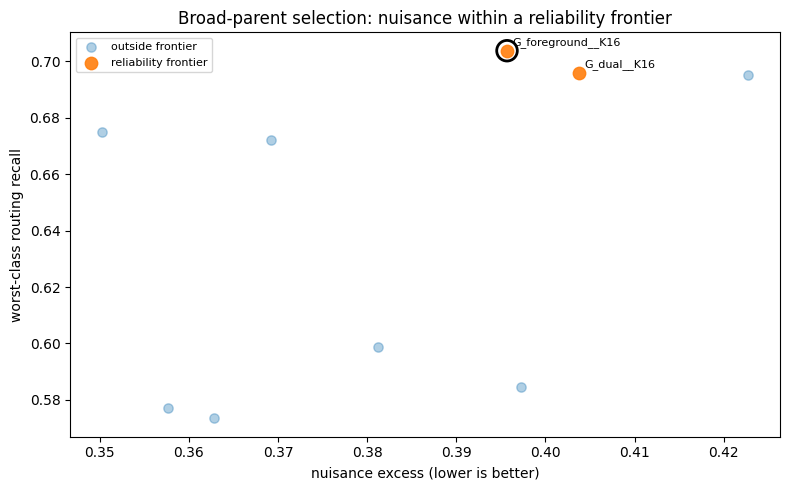

In [26]:
# 25. Broad-parent selection: hard gates -> near-best reliability frontier -> lowest nuisance.

selection = ROOT_METRICS.copy()
selection['passes_hard_gates'] = (
    (selection['coverage'] >= ROOT_MIN_COVERAGE)
    & (selection['min_cluster'] >= ROOT_MIN_SIZE)
    & (selection['seed_ari'] >= ROOT_MIN_SEED_ARI)
    & (selection['group_ari'] >= ROOT_MIN_GROUP_ARI)
    & (selection['routing_macro'] >= ROOT_MIN_MACRO_RECALL)
    & (selection['routing_q10'] >= ROOT_MIN_Q10_RECALL)
    & (selection['precision_q10'] >= ROOT_MIN_Q10_PREC)
    & (selection['silhouette'] >= ROOT_MIN_SIL)
)

eligible = selection[selection['passes_hard_gates']].copy()
if len(eligible) == 0:
    raise RuntimeError(
        'No broad-parent candidate passes the predeclared structural/reproducibility gates. '
        'Inspect root_candidates.csv; do not silently relax thresholds.'
    )

# Nuisance is intentionally primary only after we restrict attention to candidates whose
# worst-case routing recall and precision are essentially tied with the best eligible model.
best_worst_recall = float(eligible['routing_worst'].max())
best_worst_precision = float(eligible['precision_worst'].max())
eligible['reliability_frontier'] = (
    (eligible['routing_worst'] >= best_worst_recall - ROOT_RELIABILITY_RECALL_TOL)
    & (
        eligible['precision_worst']
        >= best_worst_precision - ROOT_RELIABILITY_PRECISION_TOL
    )
)

frontier = eligible[eligible['reliability_frontier']].copy()
if len(frontier) == 0:
    raise RuntimeError('Reliability frontier is unexpectedly empty.')

frontier = frontier.sort_values(
    [
        'nuisance_excess',
        'group_ari',
        'silhouette',
        'seed_ari',
        'k',
    ],
    ascending=[True, False, False, False, True],
)
chosen = frontier.iloc[0]

SELECTED_ROOT_ID = str(chosen['id'])
SELECTED_ROOT_VIEW_NAME = str(chosen['view'])
SELECTED_ROOT_FEATURES = ROOT_VIEWS[SELECTED_ROOT_VIEW_NAME]
root_obj = ROOT_PARTS[str(chosen['partition_hash'])]
ROOT_KMEANS_MODEL = root_obj['model']
ROOT_LABEL_REMAP = root_obj['remap']
PARENT_LABELS = root_obj['y'].copy()
ROOT_SEED = int(root_obj['seed'])

selection['reliability_frontier'] = selection['id'].isin(frontier['id'])
selection['selected'] = selection['id'].astype(str) == SELECTED_ROOT_ID
selection.to_csv(OUT / 'metrics' / 'root_selection.csv', index=False)

np.save(OUT / 'root' / 'raw_parent_id.npy', PARENT_LABELS)
joblib.dump(ROOT_KMEANS_MODEL, OUT / 'models' / 'root_kmeans.joblib')
write_json_atomic(OUT / 'models' / 'root_label_remap.json', ROOT_LABEL_REMAP)

ROOT_SELECTION = pd.DataFrame([chosen.to_dict()])
ROOT_SELECTION_FRONTIER = frontier[[
    'id',
    'view',
    'k',
    'routing_worst',
    'precision_worst',
    'group_ari',
    'silhouette',
    'nuisance_excess',
]].copy()
ROOT_SELECTION_FRONTIER['selected'] = (
    ROOT_SELECTION_FRONTIER['id'].astype(str) == SELECTED_ROOT_ID
)

print(
    'Selection rule: hard gates -> near-best worst-case recall/precision -> lowest nuisance.'
)
display(ROOT_SELECTION_FRONTIER)
print('SELECTED', SELECTED_ROOT_ID, 'parents', len(np.unique(PARENT_LABELS)))

fig, ax = plt.subplots(figsize=(8, 5))
for is_frontier, group in selection.groupby('reliability_frontier'):
    ax.scatter(
        group['nuisance_excess'],
        group['routing_worst'],
        s=80 if is_frontier else 45,
        alpha=0.9 if is_frontier else 0.35,
        label='reliability frontier' if is_frontier else 'outside frontier',
    )
for _, row in frontier.iterrows():
    ax.annotate(
        str(row['id']),
        (float(row['nuisance_excess']), float(row['routing_worst'])),
        fontsize=8,
        xytext=(4, 4),
        textcoords='offset points',
    )
selected_row = selection[selection['selected']].iloc[0]
ax.scatter(
    [float(selected_row['nuisance_excess'])],
    [float(selected_row['routing_worst'])],
    s=220,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
)
ax.set_xlabel('nuisance excess (lower is better)')
ax.set_ylabel('worst-class routing recall')
ax.set_title('Broad-parent selection: nuisance within a reliability frontier')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'root_selection_nuisance_frontier.png', dpi=180)
plt.show()

In [27]:
# 26. Selection-time parent reliability used only to decide which parents may expose fine groups.

ROOT_WITHHOLDOUT_EVENTS = withholding_events(
    SELECTED_ROOT_FEATURES,
    PARENT_LABELS,
    VALIDATION_GROUPS,
    HOLDOUT_REPS,
)
ROOT_WITHHOLDOUT_EVENTS['global_idx'] = ROOT_WITHHOLDOUT_EVENTS['local_idx']
ROOT_WITHHOLDOUT_EVENTS['validation_group_id'] = VALIDATION_GROUPS[
    ROOT_WITHHOLDOUT_EVENTS['global_idx'].to_numpy()
]
ROOT_WITHHOLDOUT_EVENTS.to_csv(
    OUT / 'validation' / 'root_withholding_events_selection.csv',
    index=False,
)

selection_parent_rows = []
for parent_id in sorted(np.unique(PARENT_LABELS)):
    true_events = ROOT_WITHHOLDOUT_EVENTS[
        ROOT_WITHHOLDOUT_EVENTS['true'] == parent_id
    ]
    predicted_events = ROOT_WITHHOLDOUT_EVENTS[
        ROOT_WITHHOLDOUT_EVENTS['pred'] == parent_id
    ]
    recall = float(true_events['correct'].mean()) if len(true_events) else 0.0
    precision = (
        float(predicted_events['correct'].mean())
        if len(predicted_events)
        else 0.0
    )
    reliability = min(recall, precision)
    selection_parent_rows.append({
        'parent_id': int(parent_id),
        'n': int((PARENT_LABELS == parent_id).sum()),
        'withholding_recall': recall,
        'withholding_precision': precision,
        'withholding_f1': 2 * recall * precision / max(recall + precision, 1e-12),
        'operational_reliability': reliability,
        'residual_parent': bool(reliability < RESIDUAL_PARENT_RELIABILITY),
    })

PARENT_RELIABILITY_TABLE = pd.DataFrame(selection_parent_rows)
PARENT_RELIABILITY_BY_ID = PARENT_RELIABILITY_TABLE.set_index(
    'parent_id'
)['operational_reliability'].to_dict()
PARENT_RELIABILITY_TABLE.to_csv(
    OUT / 'metrics' / 'parent_reliability_selection.csv',
    index=False,
)
# Backward-compatible artifact name used by downstream consumers.
PARENT_RELIABILITY_TABLE.to_csv(
    OUT / 'metrics' / 'parent_reliability.csv',
    index=False,
)

display(
    PARENT_RELIABILITY_TABLE[
        ['parent_id', 'n', 'operational_reliability', 'residual_parent']
    ]
)
print(
    'These values gate fine discovery only. Independent final-audit reliability is reported later.'
)

,parent_id,n,operational_reliability,residual_parent
0,0,384,0.703794,True
1,1,368,0.966398,False
2,2,354,0.968345,False
3,3,304,0.974152,False
4,4,269,0.958549,False
5,5,263,0.971275,False
6,6,252,0.931429,False
7,7,235,0.967811,False
8,8,232,0.901606,False
9,9,218,0.892704,False


These values gate fine discovery only. Independent final-audit reliability is reported later.


,method,input_view,rows,input_dim,explained_variance_pc1,explained_variance_pc2,explained_variance_2d_total,used_for_clustering,used_for_model_selection
0,PCA,G_foreground,3793,256,0.111981,0.089288,0.201269,False,False


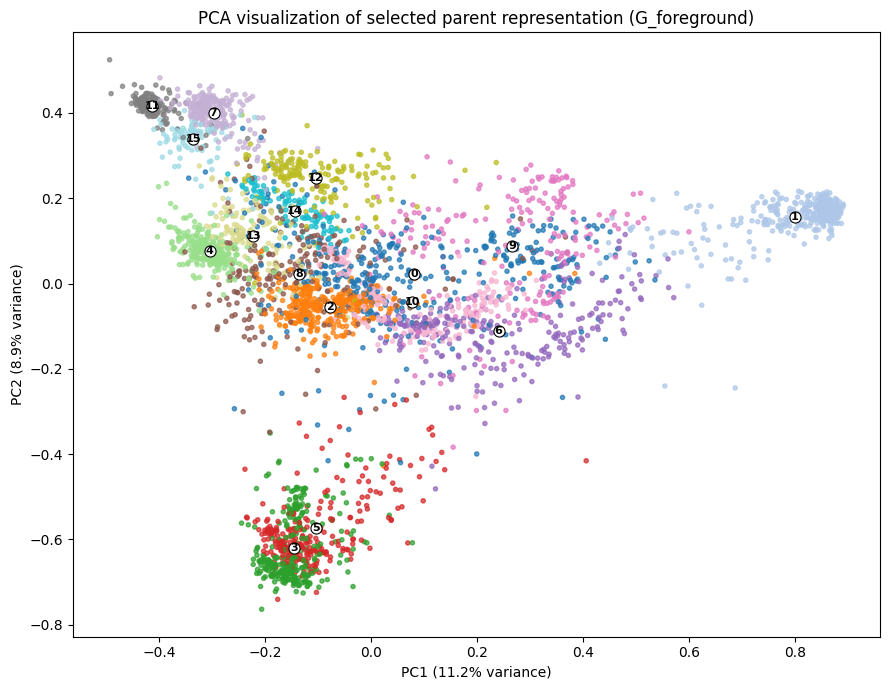

In [28]:
# 27. Deterministic two-dimensional communication plot only; never used for clustering or selection.

if ROOT_2D_VISUALIZATION != 'PCA':
    raise RuntimeError(f'Unsupported core 2D visualization policy: {ROOT_2D_VISUALIZATION!r}. Final discovery uses deterministic PCA only.')
_root_vis = np.asarray(SELECTED_ROOT_FEATURES, np.float32)
ROOT_PCA2 = PCA(n_components=2, svd_solver='full').fit(_root_vis)
ZP = ROOT_PCA2.transform(_root_vis).astype(np.float32)
assert ZP.shape == (N_CANONICAL, 2) and np.isfinite(ZP).all()
np.save(OUT / 'plots' / 'root_pca2.npy', ZP)
joblib.dump(ROOT_PCA2, OUT / 'models' / 'root_pca2.joblib')
PCA2_REPORT = pd.DataFrame([{'method': 'PCA',
    'input_view': SELECTED_ROOT_VIEW_NAME,
    'rows': int(len(ZP)),
    'input_dim': int(SELECTED_ROOT_FEATURES.shape[1]),
    'explained_variance_pc1': float(ROOT_PCA2.explained_variance_ratio_[0]),
    'explained_variance_pc2': float(ROOT_PCA2.explained_variance_ratio_[1]),
    'explained_variance_2d_total': float(ROOT_PCA2.explained_variance_ratio_.sum()),
    'used_for_clustering': False,
    'used_for_model_selection': False}])
PCA2_REPORT.to_csv(OUT / 'metrics' / 'root_2d_visualization.csv', index=False)
display(PCA2_REPORT)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(ZP[:, 0], ZP[:, 1], c=PARENT_LABELS, s=9, cmap='tab20', alpha=0.72, rasterized=True)
for g in sorted((int(x) for x in np.unique(PARENT_LABELS))):
    z = ZP[PARENT_LABELS == g].mean(0)
    ax.scatter([z[0]], [z[1]], s=64, c='white', edgecolors='black', linewidths=0.8, zorder=3)
    ax.text(z[0], z[1], str(g), ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
ax.set_title(f'PCA visualization of selected parent representation ({SELECTED_ROOT_VIEW_NAME})')
ax.set_xlabel(f'PC1 ({ROOT_PCA2.explained_variance_ratio_[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({ROOT_PCA2.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'parent_pca2.png', dpi=180)
plt.show()


## 6. Fine discovery dan raw-visual discovery

Setelah parent partition ditetapkan, fine discovery dilakukan secara konservatif. Candidate child partition harus lolos stability/routing gate, lalu setiap child divalidasi melalui resampling survival, withholding recall, dan corroboration dari independent view. Fine layer hanya diekspos jika sedikitnya dua child bertahan.

Raw-visual branch dipertahankan sebagai struktur visual pelengkap yang dapat menangkap state, configuration, scene, atau acquisition pattern. Branch ini tidak diperlakukan sebagai hierarki subtype operasional.


In [29]:
# 28. Final representation registries retained after the completed ablation phase.

FINE_VIEWS = {'G_whole': CRADIO_WHOLE,
    'G_foreground': CRADIO_FOREGROUND,
    'G_dual': CRADIO_DUAL,
    'Gdual_Lf25': weighted_feature_concat(CRADIO_DUAL, DINO_VLAD_FOREGROUND, 0.75, 0.25),
    'Gdual_Lf40': weighted_feature_concat(CRADIO_DUAL, DINO_VLAD_FOREGROUND, 0.6, 0.4)}
RAW_VISUAL_VIEWS = {'whole_G35_L65': weighted_feature_concat(CRADIO_WHOLE, DINO_VLAD_WHOLE, 0.35, 0.65),
    'whole_G50_L50': weighted_feature_concat(CRADIO_WHOLE, DINO_VLAD_WHOLE, 0.5, 0.5),
    'whole_G65_L35': weighted_feature_concat(CRADIO_WHOLE, DINO_VLAD_WHOLE, 0.65, 0.35),
    'dual_G35_L65': weighted_feature_concat(CRADIO_DUAL, DINO_VLAD_DUAL, 0.35, 0.65)}


In [30]:
# 29. Parent-conditional K-means candidate evaluation with independent-view persistence.

def evaluate_parent_candidates(parent_id, views, ks, mode):
    """Evaluate one parent-specific K-means candidate family with stability, routing, nuisance, and cross-view evidence."""
    ids = np.flatnonzero(PARENT_LABELS == parent_id)
    groups = VALIDATION_GROUPS[ids]
    unique = {}
    for view, Xfull in views.items():
        X = Xfull[ids]
        for k in ks:
            model, y, remap, seed, seedari = fit_medoid_kmeans(X, k)
            st = summarize_partition(X, y)
            h = partition_hash(y)
            minsize = VISUAL_MIN_SIZE if mode == 'visual' else ID_MIN_SIZE
            mincov = VISUAL_MIN_COVERAGE if mode == 'visual' else ID_MIN_COVERAGE
            if st['clusters'] < 2 or st['coverage'] < mincov or st['min_cluster'] < minsize:
                continue
            prov = {'view': view, 'k': int(k), 'seed_ari': float(seedari)}
            obj = {'y': y,
                'model': model,
                'remap': remap,
                'seed': seed,
                'seed_ari': seedari,
                'view': view,
                'k': int(k),
                'X': X,
                'ids': ids,
                'stats': st,
                'provenance': [prov]}
            if h in unique:
                unique[h]['provenance'].append(prov)
                if seedari > unique[h]['seed_ari']:
                    keep = unique[h]['provenance']
                    unique[h] = obj
                    unique[h]['provenance'] = keep
            else:
                unique[h] = obj
    rows = []
    parts = {}
    for h, obj in unique.items():
        y = obj['y']
        X = obj['X']
        med, q10, mn = group_resample_ari_kmeans(X, groups, y, obj['k'])
        ev = withholding_events(X, y, groups, max(6, HOLDOUT_REPS // 2))
        rs = routing_summary(ev)
        nu = nuisance_probe(ids, y)
        chance = 1 / max(obj['k'], 1)
        nu_excess = float(np.clip((nu - chance) / max(1 - chance, 1e-09),
            0,
            1)) if np.isfinite(nu) else np.nan
        exact_views = sorted({p['view'] for p in obj['provenance']})
        row = {'parent': int(parent_id),
            'mode': mode,
            'view': obj['view'],
            'k': obj['k'],
            **obj['stats'],
            'seed_ari': obj['seed_ari'],
            'medoid_seed': obj['seed'],
            'group_ari': med,
            'group_ari_q10': q10,
            'group_ari_min': mn,
            'nuisance_bal_acc': nu,
            'nuisance_excess': nu_excess,
            **rs,
            'hash': h,
            'exact_support_views': len(exact_views),
            'exact_view_names': json.dumps(exact_views)}
        rows.append(row)
        obj['events'] = ev
        parts[h] = obj
    df = pd.DataFrame(rows)
    if len(df):
        if mode == 'fine':
            base = df[(df.group_ari >= ID_MIN_GROUP_ARI) & (df.seed_ari >= ID_MIN_SEED_ARI) & (df.routing_macro >= ID_MIN_ROUTING_MACRO)].copy()
        else:
            base = df[(df.group_ari >= VISUAL_MIN_GROUP_ARI) & (df.seed_ari >= VISUAL_MIN_SEED_ARI)].copy()
        if len(base) == 0:
            base = df
        all_views = sorted(views)
        for idx, r in df.iterrows():
            y = parts[str(r['hash'])]['y']
            target = int(r['clusters'])
            rep_view = str(r['view'])
            exact = set(json.loads(r['exact_view_names']))
            scores = []
            for vv in all_views:
                if vv == rep_view:
                    continue
                if vv in exact:
                    scores.append(1.0)
                    continue
                vals = []
                for _, rr in base.iterrows():
                    if rr['hash'] == r['hash'] or str(rr['view']) != vv or abs(int(rr['clusters']) - target) > 1:
                        continue
                    vals.append(adjusted_rand_score(y, parts[str(rr['hash'])]['y']))
                if vals:
                    scores.append(max(vals))
            df.loc[idx, 'cross_view_median'] = float(np.median(scores)) if scores else np.nan
            df.loc[idx, 'cross_view_q10'] = float(np.quantile(scores, 0.1)) if scores else np.nan
            df.loc[idx, 'cross_view_min'] = float(np.min(scores)) if scores else np.nan
            df.loc[idx, 'cross_view_support'] = len(scores)
    return (df, parts)


In [31]:
# 30. Select one provisional fine partition per reliable parent from the compact direct K-means family.

FINE_CANDIDATES = {}
FINE_SELECTION = {}
all_rows = []
selection_rows = []
for g in sorted(np.unique(PARENT_LABELS)):
    df, parts = evaluate_parent_candidates(int(g), FINE_VIEWS, IDENTITY_KS, 'fine')
    FINE_CANDIDATES[int(g)] = (df, parts)
    all_rows.extend(df.to_dict('records'))
    if PARENT_RELIABILITY_BY_ID[int(g)] < RESIDUAL_PARENT_RELIABILITY or len(df) == 0:
        FINE_SELECTION[int(g)] = None
        continue
    q = df[(df.group_ari >= ID_MIN_GROUP_ARI) & (df.seed_ari >= ID_MIN_SEED_ARI) & (df.routing_macro >= ID_MIN_ROUTING_MACRO) & (df.routing_q10 >= ID_MIN_ROUTING_Q10) & (df.coverage >= ID_MIN_COVERAGE) & (df.min_cluster >= ID_MIN_SIZE) & (df.cross_view_support.fillna(0) >= MIN_CROSS_VIEW_SUPPORT)].copy()
    if len(q) == 0:
        FINE_SELECTION[int(g)] = None
        continue
    q['neg_nuisance'] = -q.nuisance_excess.fillna(0.5)
    q['pareto'] = pareto_mask(q,
        ['group_ari', 'routing_macro', 'routing_q10', 'precision_macro', 'cross_view_median', 'cross_view_support', 'neg_nuisance'])
    front = q[q.pareto].copy()
    front = front[front.group_ari >= front.group_ari.max() - 0.04]
    front = front.sort_values(['clusters', 'routing_q10', 'cross_view_support', 'cross_view_median', 'group_ari', 'nuisance_excess'],
        ascending=[False, False, False, False, False, True])
    r = front.iloc[0]
    obj = parts[str(r['hash'])]
    FINE_SELECTION[int(g)] = {'row': r.to_dict(), 'obj': obj}
    selection_rows.append(r.to_dict())
FINE_CANDIDATE_TABLE = pd.DataFrame(all_rows)
FINE_SELECTED_TABLE = pd.DataFrame(selection_rows)
FINE_CANDIDATE_TABLE.to_csv(OUT / 'metrics' / 'fine_candidates.csv', index=False)
FINE_SELECTED_TABLE.to_csv(OUT / 'metrics' / 'fine_provisional_selection.csv', index=False)
display(FINE_SELECTED_TABLE)


,parent,mode,view,k,clusters,coverage,min_cluster,median_cluster,silhouette,seed_ari,...,f1_macro,hash,exact_support_views,exact_view_names,cross_view_median,cross_view_q10,cross_view_min,cross_view_support,neg_nuisance,pareto
0,1,fine,G_foreground,2,2,1.0,95,184.0,0.304700,1.000000,...,0.947261,d71d98741d84a99c,1,"[""G_foreground""]",0.868077,0.686607,0.622087,4.0,-0.350993,True
1,2,fine,G_dual,5,5,1.0,15,66.0,0.412944,0.991571,...,0.932938,050fbde650fc965c,1,"[""G_dual""]",0.920397,0.914039,0.912450,3.0,-0.335761,True
2,3,fine,G_foreground,2,2,1.0,79,152.0,0.478095,1.000000,...,0.979798,6c2cb68771c4d000,1,"[""G_foreground""]",0.911763,0.905188,0.905188,4.0,-0.156062,True
3,4,fine,Gdual_Lf40,2,2,1.0,133,134.5,0.166333,0.985130,...,0.959876,74a1199cacf1a2ed,1,"[""Gdual_Lf40""]",0.919713,0.878588,0.870166,4.0,-0.270953,True
4,5,fine,G_foreground,2,2,1.0,64,131.5,0.480796,1.000000,...,0.926438,8dac9655c2dfcb22,1,"[""G_foreground""]",0.887659,0.822406,0.801242,4.0,-0.059673,True
5,6,fine,G_foreground,3,3,1.0,50,65.0,0.457189,1.000000,...,0.969311,5e6de5b3dd025513,1,"[""G_foreground""]",0.960800,0.938726,0.937550,4.0,-0.393178,True
6,7,fine,Gdual_Lf40,2,2,1.0,40,117.5,0.324717,0.979184,...,0.917423,3b06f1e7cfdb85cc,1,"[""Gdual_Lf40""]",0.938440,0.905845,0.897697,2.0,-0.167949,True
7,8,fine,Gdual_Lf40,2,2,1.0,84,116.0,0.142616,0.898189,...,0.935102,8558cb6251d315b6,1,"[""Gdual_Lf40""]",0.865397,0.616531,0.509939,4.0,-0.460103,True
8,9,fine,G_whole,4,4,1.0,20,55.5,0.370627,0.969479,...,0.928663,82151c309f3e7605,1,"[""G_whole""]",0.863998,0.822113,0.806216,4.0,-0.523761,True
9,10,fine,G_foreground,4,4,1.0,38,47.0,0.629712,1.000000,...,0.992922,dd741d3f8c31005d,2,"[""G_dual"", ""G_foreground""]",0.970985,0.904766,0.882977,4.0,-0.467899,True


In [32]:
# 31. Individual-child survival + cross-view corroboration; expose a fine layer only when >=2 children survive.

def child_survival(
    obj,
    reps=GROUP_SPLIT_REPS,
    random_state=None,
):
    """Measure each proposed child cluster survival under group-aware resampling.

    The default preserves selection-time behavior. Final evaluation supplies an
    independent seed and therefore cannot influence which children were accepted.
    """
    labels = obj['y']
    features = obj['X']
    groups = VALIDATION_GROUPS[obj['ids']]
    n_clusters = int(obj['k'])
    scores = {int(child): [] for child in np.unique(labels) if child >= 0}

    if random_state is None:
        split_seed = SEED + 808 + len(labels) + n_clusters
        fit_seed_base = SEED
    else:
        split_seed = int(random_state)
        fit_seed_base = int(random_state) + 10000

    splitter = GroupShuffleSplit(
        n_splits=reps,
        train_size=0.8,
        random_state=split_seed,
    )
    for repeat, (train_idx, _) in enumerate(
        splitter.split(np.arange(len(labels)), groups=groups)
    ):
        resampled_labels = KMeans(
            n_clusters=n_clusters,
            n_init=20,
            random_state=fit_seed_base + repeat,
        ).fit(normalize_rows_l2(features[train_idx])).labels_
        resampled_labels = relabel_by_size(resampled_labels)
        matched = {
            int(reference_child): float(score)
            for reference_child, _, score in hungarian_overlap_pairs(
                labels[train_idx],
                resampled_labels,
            )
        }
        for child in scores:
            scores[child].append(float(matched.get(child, 0.0)))
    return scores

def child_view_corroboration(g, obj):
    """Measure whether each child is independently corroborated by alternative representation views."""
    df, parts = FINE_CANDIDATES[int(g)]
    y = obj['y']
    target = len(np.unique(y))
    selected_hash = partition_hash(y)
    rows = {int(cc): [] for cc in np.unique(y) if cc >= 0}
    sel = df[df['hash'] == selected_hash]
    rep_view = obj['view']
    exact = set(json.loads(sel.iloc[0]['exact_view_names'])) if len(sel) else {rep_view}
    for vv in exact:
        if vv != rep_view:
            for cc in rows:
                rows[cc].append(1.0)
    credible = df[(df.group_ari >= ID_MIN_GROUP_ARI) & (df.seed_ari >= ID_MIN_SEED_ARI) & (df.routing_macro >= ID_MIN_ROUTING_MACRO)]
    for vv in sorted(FINE_VIEWS):
        if vv == rep_view or vv in exact:
            continue
        candidate_maps = []
        for _, r in credible.iterrows():
            if str(r['view']) != vv or abs(int(r['clusters']) - target) > 1:
                continue
            yy = parts[str(r['hash'])]['y']
            candidate_maps.append({a: s for a, b, s in hungarian_overlap_pairs(y, yy)})
        if candidate_maps:
            for cc in rows:
                rows[cc].append(max((d.get(cc, 0.0) for d in candidate_maps)))
    return rows
RAW_LOCAL_CHILD = np.full(N_CANONICAL, -1, np.int32)
FINE_GROUP_LABELS = np.full(N_CANONICAL, -1, np.int32)
fine_metrics = []
fine_map = []
fine_models = {}
fine_offset = 0
for g in sorted(np.unique(PARENT_LABELS)):
    sel = FINE_SELECTION.get(int(g))
    ids = np.flatnonzero(PARENT_LABELS == g)
    if sel is None:
        continue
    obj = sel['obj']
    y = obj['y']
    RAW_LOCAL_CHILD[ids] = y
    surv = child_survival(obj)
    corr = child_view_corroboration(int(g), obj)
    accepted = []
    for cc in sorted(np.unique(y)):
        sv = surv[int(cc)]
        er = obj['events'][obj['events'].true == cc]
        rec = float(er.correct.mean()) if len(er) else 0.0
        cv = corr[int(cc)]
        med = float(np.median(sv)) if sv else 0.0
        q10 = float(np.quantile(sv, 0.1)) if sv else 0.0
        cm = float(np.median(cv)) if cv else np.nan
        cq = float(np.quantile(cv, 0.1)) if cv else np.nan
        ok = bool(med >= CHILD_SURVIVAL_MED and q10 >= CHILD_SURVIVAL_Q10 and (rec >= CHILD_WITHHOLD_RECALL) and (len(cv) >= MIN_CHILD_CORROBORATORS) and (cm >= CHILD_VIEW_MED) and (cq >= CHILD_VIEW_Q10))
        fine_metrics.append({'parent': int(g),
            'local_child': int(cc),
            'n': int((y == cc).sum()),
            'view': obj['view'],
            'k': obj['k'],
            'survival_median': med,
            'survival_q10': q10,
            'withholding_recall': rec,
            'cross_view_median': cm,
            'cross_view_q10': cq,
            'cross_view_comparators': len(cv),
            'accepted': ok})
        if ok:
            accepted.append(int(cc))
    if len(accepted) < 2:
        continue
    model, remap = (obj['model'], obj['remap'])
    spec = {'view': obj['view'], 'k': obj['k'], 'accepted_local': accepted, 'medoid_seed': obj['seed']}
    fine_models[int(g)] = (model, remap, spec)
    joblib.dump(model,
        OUT / 'models' / f"fine_parent_{int(g):02d}_{safe_path_component(obj['view'])}_K{obj['k']}.joblib")
    write_json_atomic(OUT / 'models' / f'fine_parent_{int(g):02d}_remap.json', remap)
    for cc in accepted:
        FINE_GROUP_LABELS[ids[y == cc]] = fine_offset
        fine_map.append({'validated_fine_group_id': fine_offset,
            'parent_id': int(g),
            'local_child_id': int(cc),
            'view': obj['view'],
            'k': int(obj['k']),
            'medoid_seed': int(obj['seed'])})
        fine_offset += 1
FINE_VALIDATION = pd.DataFrame(fine_metrics,
    columns=['parent', 'local_child', 'n', 'view', 'k', 'survival_median', 'survival_q10', 'withholding_recall', 'cross_view_median', 'cross_view_q10', 'cross_view_comparators', 'accepted'])
FINE_GROUP_MAP = pd.DataFrame(fine_map,
    columns=['validated_fine_group_id', 'parent_id', 'local_child_id', 'view', 'k', 'medoid_seed'])
FINE_VALIDATION.to_csv(OUT / 'metrics' / 'fine_child_validation.csv', index=False)
FINE_GROUP_MAP.to_csv(OUT / 'fine' / 'fine_group_map.csv', index=False)
np.save(OUT / 'fine' / 'raw_local_child_id.npy', RAW_LOCAL_CHILD)
np.save(OUT / 'fine' / 'validated_fine_group_id.npy', FINE_GROUP_LABELS)
display(FINE_VALIDATION)
print({'validated_fine_groups': fine_offset, 'images_with_fine_group': int((FINE_GROUP_LABELS >= 0).sum())})


,parent,local_child,n,view,k,survival_median,survival_q10,withholding_recall,cross_view_median,cross_view_q10,cross_view_comparators,accepted
0,1,0,273,G_foreground,2,0.993056,0.975867,0.952830,0.956282,0.886081,4,True
1,1,1,95,G_foreground,2,0.979604,0.933713,0.961832,0.937905,0.914895,4,True
2,2,0,142,G_dual,5,0.986683,0.928054,0.966480,0.943662,0.938028,3,True
3,2,1,84,G_dual,5,1.000000,0.903030,0.990196,0.964286,0.946346,3,True
4,2,2,66,G_dual,5,0.981379,0.963434,0.987342,0.969697,0.933333,3,True
5,2,3,47,G_dual,5,0.958687,0.736385,0.648148,0.937500,0.910577,3,False
6,2,4,15,G_dual,5,0.925824,0.908333,1.000000,1.000000,1.000000,3,True
7,3,0,225,G_foreground,2,0.994444,0.986813,0.977695,0.971366,0.969163,4,True
8,3,1,79,G_foreground,2,0.984612,0.964615,1.000000,0.922189,0.916667,4,True
9,4,0,136,Gdual_Lf40,2,0.990377,0.956285,1.000000,0.960789,0.941356,4,True


{'validated_fine_groups': 28, 'images_with_fine_group': 2478}


In [33]:
# 33. Complementary raw-visual leaves: select the finest partition inside a near-best stability frontier.

RAW_VISUAL_CANDIDATES = {}
RAW_VISUAL_SELECTION = {}
RAW_VISUAL_LABELS = np.full(N_CANONICAL, -1, np.int32)
visual_rows = []
visual_map = []
visual_models = {}
offset = 0
for g in sorted(np.unique(PARENT_LABELS)):
    df, parts = evaluate_parent_candidates(int(g), RAW_VISUAL_VIEWS, VISUAL_KS, 'visual')
    RAW_VISUAL_CANDIDATES[int(g)] = (df, parts)
    visual_rows.extend(df.assign(selected=False).to_dict('records'))
    ids = np.flatnonzero(PARENT_LABELS == g)
    q = df[(df.group_ari >= VISUAL_MIN_GROUP_ARI) & (df.seed_ari >= VISUAL_MIN_SEED_ARI)].copy() if len(df) else pd.DataFrame()
    if len(q) == 0:
        RAW_VISUAL_LABELS[ids] = offset
        visual_map.append({'raw_visual_leaf_id': offset,
            'parent_id': int(g),
            'local_visual_id': 0,
            'view': 'parent_only',
            'k': 1})
        RAW_VISUAL_SELECTION[int(g)] = None
        offset += 1
        continue
    bestg = q.group_ari.max()
    bests = q.seed_ari.max()
    q = q[(q.group_ari >= bestg - 0.05) & (q.seed_ari >= bests - 0.05)].sort_values(['clusters', 'group_ari', 'routing_q10', 'silhouette'],
        ascending=[False, False, False, False])
    r = q.iloc[0]
    obj = parts[str(r['hash'])]
    RAW_VISUAL_SELECTION[int(g)] = r.to_dict()
    model, remap = (obj['model'], obj['remap'])
    spec = {'view': obj['view'], 'k': obj['k'], 'medoid_seed': obj['seed']}
    visual_models[int(g)] = (model, remap, spec)
    joblib.dump(model,
        OUT / 'models' / f"raw_visual_parent_{int(g):02d}_{safe_path_component(obj['view'])}_K{obj['k']}.joblib")
    write_json_atomic(OUT / 'models' / f'raw_visual_parent_{int(g):02d}_remap.json', remap)
    for cc in sorted(np.unique(obj['y'])):
        RAW_VISUAL_LABELS[ids[obj['y'] == cc]] = offset
        visual_map.append({'raw_visual_leaf_id': offset,
            'parent_id': int(g),
            'local_visual_id': int(cc),
            'view': obj['view'],
            'k': int(obj['k']),
            'medoid_seed': int(obj['seed'])})
        offset += 1
RAW_VISUAL_METRICS = pd.DataFrame(visual_rows)
if len(RAW_VISUAL_METRICS):
    for g, r in RAW_VISUAL_SELECTION.items():
        if r is not None:
            RAW_VISUAL_METRICS.loc[(RAW_VISUAL_METRICS.parent == g) & (RAW_VISUAL_METRICS['hash'].astype(str) == str(r['hash'])),
                'selected'] = True
RAW_VISUAL_MAP_TABLE = pd.DataFrame(visual_map)
RAW_VISUAL_METRICS.to_csv(OUT / 'metrics' / 'raw_visual_candidates.csv', index=False)
RAW_VISUAL_MAP_TABLE.to_csv(OUT / 'visual' / 'raw_visual_map.csv', index=False)
np.save(OUT / 'visual' / 'raw_visual_leaf_id.npy', RAW_VISUAL_LABELS)

RAW_VISUAL_SELECTED_TABLE = RAW_VISUAL_METRICS[
    RAW_VISUAL_METRICS.get('selected', False) == True
].copy() if len(RAW_VISUAL_METRICS) else RAW_VISUAL_METRICS
RAW_VISUAL_SELECTED_TABLE.to_csv(
    OUT / 'metrics' / 'raw_visual_selected.csv',
    index=False,
)
display(
    RAW_VISUAL_SELECTED_TABLE[[
        'parent', 'view', 'k', 'clusters', 'group_ari', 'seed_ari',
        'routing_q10', 'nuisance_excess'
    ]] if len(RAW_VISUAL_SELECTED_TABLE) else RAW_VISUAL_SELECTED_TABLE
)


,parent,view,k,clusters,group_ari,seed_ari,routing_q10,nuisance_excess
8,0,whole_G50_L50,3,3,0.965808,0.981378,0.969048,0.364476
42,1,whole_G65_L35,2,2,0.919529,1.000000,0.957726,0.558983
71,2,whole_G65_L35,5,5,0.939998,0.938964,0.770805,0.328381
91,3,whole_G50_L50,5,5,0.933501,0.959915,0.610013,0.463482
121,4,whole_G65_L35,3,3,0.983568,1.000000,0.518631,0.209578
147,5,whole_G65_L35,3,3,0.928679,1.000000,0.798707,0.490743
167,6,whole_G50_L50,3,3,0.987242,1.000000,0.894187,0.481760
186,7,whole_G35_L65,2,2,0.946939,0.932760,0.824779,0.857612
230,8,dual_G35_L65,2,2,0.935355,0.948398,0.838000,0.494146
245,9,whole_G50_L50,5,5,0.964367,0.978454,0.673718,0.593051


## 7. Confidence dan abstention

Cross-fitted kNN support, margin, dan density digunakan untuk mengukur **reproducibility assignment**, bukan kebenaran semantik. Setelah struktur numerik dibekukan, sinyal tersebut digunakan untuk membentuk status operasional yang konservatif.

Background control ditempatkan pada evaluasi final agar tidak memengaruhi membership.


In [34]:
# 34. Cross-fitted parent/fine confidence. Confidence is assignment reproducibility, not semantic correctness.

def risk_curve(score, correct):
    """Compute empirical routing risk versus retained coverage over score thresholds."""
    rows = []
    score = np.asarray(score, float)
    correct = np.asarray(correct, int)
    m0 = np.isfinite(score)
    score = score[m0]
    correct = correct[m0]
    if not len(score):
        return pd.DataFrame(columns=['threshold', 'coverage', 'risk', 'n'])
    for t in np.unique(np.r_[np.linspace(0, 1, 101), np.quantile(score, np.linspace(0, 1, 101))]):
        m = score >= t
        if m.sum() >= 20:
            rows.append({'threshold': float(t),
                'coverage': float(m.mean()),
                'risk': float(1 - correct[m].mean()),
                'n': int(m.sum())})
    return pd.DataFrame(rows)

def choose_thr(curve, target=TARGET_ROUTING_RISK):
    """Choose the maximum-coverage confidence threshold meeting the target routing risk."""
    if len(curve) == 0:
        return float(REJECT_THRESHOLD)
    q = curve[curve.risk <= target]
    return float(q.sort_values(['coverage', 'threshold'],
        ascending=[False, True]).iloc[0].threshold) if len(q) else float(REJECT_THRESHOLD)

def calibrator(events):
    """Fit a group-aware logistic calibration model for numerical assignment correctness."""
    cols = ['support', 'margin', 'nn1', 'nn5', 'density']
    X = events[cols].to_numpy()
    y = events.correct.to_numpy()
    base = float(y.mean()) if len(y) else 0.0
    grp = events.validation_group_id.to_numpy() if 'validation_group_id' in events else events.global_idx.to_numpy()
    if len(np.unique(y)) < 2:
        return (None, np.full(len(events), base, float), base)
    ng = len(np.unique(grp))
    oof = np.full(len(events), np.nan, float)
    worked = False
    for nsp in range(min(5, ng), 1, -1):
        try:
            tmp = np.full(len(events), np.nan, float)
            for tr, va in GroupKFold(n_splits=nsp).split(X, y, grp):
                if len(np.unique(y[tr])) < 2:
                    raise ValueError('single-class calibration fold')
                m = make_pipeline(StandardScaler(),
                    LogisticRegression(C=1, max_iter=2000, class_weight='balanced', random_state=SEED)).fit(X[tr],
                    y[tr])
                tmp[va] = m.predict_proba(X[va])[:, 1]
            if np.isfinite(tmp).all():
                oof = tmp
                worked = True
                break
        except Exception:
            continue
    if not worked:
        return (None, np.full(len(events), base, float), base)
    final = make_pipeline(StandardScaler(),
        LogisticRegression(C=1, max_iter=2000, class_weight='balanced', random_state=SEED)).fit(X,
        y)
    return (final, oof, base)

def loo_group_knn_features(X, y, groups, k=15):
    """Compute leave-validation-group-out kNN support features for every item."""
    X = np.asarray(X)
    y = np.asarray(y)
    groups = np.asarray(groups)
    ref = np.flatnonzero(y >= 0)
    pred = np.full(len(X), -1, int)
    feat = np.zeros((len(X), 5), np.float32)
    if not len(ref):
        return (pred, feat)
    maxg = int(pd.Series(groups[ref]).value_counts().max())
    nn = NearestNeighbors(n_neighbors=min(len(ref), k + maxg + 4),
        metric='cosine',
        algorithm='brute').fit(X[ref])
    d, I0 = nn.kneighbors(X)
    I = ref[I0]
    for i in range(len(X)):
        m = groups[I[i]] != groups[i]
        ids = I[i][m][:k]
        ds = d[i][m][:k]
        if not len(ids):
            continue
        labs = y[ids]
        sim = np.maximum(1 - ds, 0)
        score = {int(cc): float((sim[labs == cc] + 1e-06).sum()) for cc in np.unique(labs)}
        rank = sorted(score.items(), key=lambda z: z[1], reverse=True)
        pred[i] = rank[0][0]
        tot = sum((v for _, v in rank))
        feat[i] = [rank[0][1] / tot,
            (rank[0][1] - rank[1][1]) / tot if len(rank) > 1 else 1.0,
            sim[0],
            sim[:min(5, len(sim))].mean(),
            sim.mean()]
    return (pred, feat)
ROOT_WITHHOLDOUT_EVENTS = withholding_events(SELECTED_ROOT_FEATURES,
    PARENT_LABELS,
    VALIDATION_GROUPS,
    HOLDOUT_REPS)
ROOT_WITHHOLDOUT_EVENTS['global_idx'] = ROOT_WITHHOLDOUT_EVENTS.local_idx
ROOT_WITHHOLDOUT_EVENTS['validation_group_id'] = VALIDATION_GROUPS[ROOT_WITHHOLDOUT_EVENTS.global_idx.to_numpy()]
P_CAL, P_OOF, P_BASE = calibrator(ROOT_WITHHOLDOUT_EVENTS)
ROOT_WITHHOLDOUT_EVENTS['oof_score'] = P_OOF
P_RISK = risk_curve(P_OOF, ROOT_WITHHOLDOUT_EVENTS.correct.to_numpy())
P_THR = choose_thr(P_RISK)
P_RISK.to_csv(OUT / 'validation' / 'parent_risk_coverage.csv', index=False)
joblib.dump(P_CAL, OUT / 'models' / 'parent_confidence_calibrator.joblib')
write_json_atomic(OUT / 'models' / 'parent_confidence_meta.json',
    {'base_score': float(P_BASE), 'global_threshold': float(P_THR), 'calibrator_present': bool(P_CAL is not None)})
P_LOCAL = {}
for g in sorted(np.unique(PARENT_LABELS)):
    e = ROOT_WITHHOLDOUT_EVENTS[ROOT_WITHHOLDOUT_EVENTS.pred == g]
    if len(e) >= 30 and len(np.unique(e.correct)) > 1:
        lc = risk_curve(e.oof_score.to_numpy(), e.correct.to_numpy())
        lt = choose_thr(lc)
        P_LOCAL[int(g)] = float(lt if lt > 1 else len(e) / (len(e) + LOCAL_THRESHOLD_SHRINK_N) * lt + LOCAL_THRESHOLD_SHRINK_N / (len(e) + LOCAL_THRESHOLD_SHRINK_N) * P_THR)
    else:
        P_LOCAL[int(g)] = float(P_THR)
write_json_atomic(OUT / 'models' / 'parent_confidence_thresholds.json', P_LOCAL)
PRED_PARENT, PFEAT = loo_group_knn_features(SELECTED_ROOT_FEATURES, PARENT_LABELS, VALIDATION_GROUPS)
PARENT_CONFIDENCE_SCORES = P_CAL.predict_proba(PFEAT)[:,
    1] if P_CAL is not None else np.full(N_CANONICAL,
    P_BASE,
    float)
PRED_FINE = np.full(N_CANONICAL, -1, int)
FINE_CONFIDENCE_SCORES = np.full(N_CANONICAL, np.nan, float)
FINE_THRESHOLDS = {}
FINE_CONF_META = {}
FINE_EVENTS = []
for g, (model, remap, spec) in fine_models.items():
    ids = np.flatnonzero(PARENT_LABELS == g)
    labs = FINE_GROUP_LABELS[ids]
    known = labs >= 0
    if len(np.unique(labs[known])) < 2:
        continue
    X = FINE_VIEWS[spec['view']][ids]
    known_local = np.flatnonzero(known)
    known_global = ids[known]
    ev = withholding_events(X[known], labs[known], VALIDATION_GROUPS[known_global], HOLDOUT_REPS)
    ev['global_idx'] = known_global[ev.local_idx.to_numpy()]
    ev['validation_group_id'] = VALIDATION_GROUPS[ev.global_idx.to_numpy()]
    ev['parent'] = g
    FINE_EVENTS.append(ev)
    m, oof, base = calibrator(ev)
    curve = risk_curve(oof, ev.correct.to_numpy())
    thr = choose_thr(curve)
    FINE_THRESHOLDS[int(g)] = float(thr)
    FINE_CONF_META[int(g)] = {'base_score': float(base),
        'threshold': float(thr),
        'calibrator_present': bool(m is not None)}
    pred, ff = loo_group_knn_features(X, labs, VALIDATION_GROUPS[ids])
    PRED_FINE[ids] = pred
    FINE_CONFIDENCE_SCORES[ids] = m.predict_proba(ff)[:, 1] if m is not None else base
    joblib.dump(m, OUT / 'models' / f'fine_confidence_parent_{g:02d}.joblib')
    curve.to_csv(OUT / 'validation' / f'fine_risk_parent_{g:02d}.csv', index=False)
FINE_EVENTS = pd.concat(FINE_EVENTS, ignore_index=True) if FINE_EVENTS else pd.DataFrame()
FINE_EVENTS.to_csv(OUT / 'validation' / 'fine_withholding_events.csv', index=False)
write_json_atomic(OUT / 'models' / 'fine_confidence_thresholds.json', FINE_THRESHOLDS)
write_json_atomic(OUT / 'models' / 'fine_confidence_meta.json', FINE_CONF_META)
DISCOVERY_STATUS = []
for i in range(N_CANONICAL):
    g = int(PARENT_LABELS[i])
    parent_ok = PRED_PARENT[i] == g and PARENT_CONFIDENCE_SCORES[i] >= P_LOCAL.get(g, P_THR)
    reliable = PARENT_RELIABILITY_BY_ID[g] >= RESIDUAL_PARENT_RELIABILITY
    if not parent_ok or not reliable:
        DISCOVERY_STATUS.append('unknown_mixed')
        continue
    if FINE_GROUP_LABELS[i] < 0:
        DISCOVERY_STATUS.append('reliable_parent_only')
        continue
    fine_ok = PRED_FINE[i] == FINE_GROUP_LABELS[i] and np.isfinite(FINE_CONFIDENCE_SCORES[i]) and (FINE_CONFIDENCE_SCORES[i] >= FINE_THRESHOLDS.get(g,
        REJECT_THRESHOLD))
    DISCOVERY_STATUS.append('reliable_parent_and_fine_group' if fine_ok else 'reliable_parent_only')
DISCOVERY_STATUS = np.asarray(DISCOVERY_STATUS, object)
CONF = pd.DataFrame({'canonical_index': np.arange(N_CANONICAL),
    'pred_parent': PRED_PARENT,
    'parent_confidence_score': PARENT_CONFIDENCE_SCORES,
    'pred_fine_group': PRED_FINE,
    'fine_group_confidence_score': FINE_CONFIDENCE_SCORES,
    'discovery_status': DISCOVERY_STATUS})
CONF.to_csv(OUT / 'fine' / 'confidence.csv', index=False)
display(CONF.discovery_status.value_counts().to_frame('n').assign(fraction=lambda x: x.n / N_CANONICAL))


,n,fraction
discovery_status,,
reliable_parent_and_fine_group,2360,0.622199
reliable_parent_only,979,0.258107
unknown_mixed,454,0.119694


## 8. Discovery atribut kontinu

Atribut kontinu dibentuk dengan signed identity-neighbour residual FastICA. Global ICA memilih neighbourhood scale dan rank dari grid yang ringkas, sedangkan family-specific ICA memilih rank secara independen di dalam parent yang telah ditetapkan.

Faktor-faktor ini tetap berupa latent continuous axes dan belum diberi nama semantik pada tahap ini. Perbandingan dengan NMF dilakukan sesudah evaluasi final sebagai ablation metodologis.


In [35]:
# 36. Current-run advanced DINO resources for the final 512-concept attribute branch.

RMID_PATH = OUT / 'cache' / 'dino_reservoir_mid_f16.npy'
RLATE_PATH = OUT / 'cache' / 'dino_reservoir_late_f16.npy'
MID_PCA_PATH = OUT / 'models' / 'concept_mid_pca64.npz'
LATE_PCA_PATH = OUT / 'models' / 'concept_late_pca64.npz'
C512_PATH = OUT / 'models' / 'concept512_centers.npy'
for p in [RMID_PATH, RLATE_PATH, BBOX_PATH, MID_PCA_PATH, LATE_PCA_PATH, C512_PATH]:
    if not Path(p).is_file():
        raise FileNotFoundError(f'Missing current-run attribute resource: {p}')

def pca_npz_apply(X, path):
    z = np.load(path)
    Y = (np.asarray(X, np.float32) - z['mean']) @ z['components'].T
    alpha = float(z['alpha']) if 'alpha' in z else 0.0
    if alpha:
        Y *= np.power(np.maximum(z['explained_variance'], 1e-05), -0.5 * alpha)
    return Y.astype(np.float32)

def build_advanced_patch_descriptor(mid, late):
    """Construct the normalized middle+late DINO descriptor used by the attribute and patch branches."""
    return normalize_rows_l2(np.c_[normalize_rows_l2(pca_npz_apply(mid, MID_PCA_PATH)) / np.sqrt(2),
        normalize_rows_l2(pca_npz_apply(late, LATE_PCA_PATH)) / np.sqrt(2)])
ADV_DINO_MODEL = None
ADV_DINO_PROC = None
ADV_PATCH = None
ADV_REG = None
ADV_DEPTH = None
ADV_MID = None
ADV_DTYPE = None

def load_advanced_dino():
    global ADV_DINO_MODEL, ADV_DINO_PROC, ADV_PATCH, ADV_REG, ADV_DEPTH, ADV_MID, ADV_DTYPE
    if ADV_DINO_MODEL is not None:
        return
    cuda_healthcheck('Before loading advanced DINO')
    from transformers import AutoImageProcessor, AutoModel
    ADV_DINO_PROC = AutoImageProcessor.from_pretrained(DINO_DIR, local_files_only=True)
    ADV_DTYPE = torch.bfloat16 if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported() else torch.float16 if DEVICE.type == 'cuda' else torch.float32
    ADV_DINO_MODEL = AutoModel.from_pretrained(DINO_DIR,
        local_files_only=True,
        low_cpu_mem_usage=True,
        dtype=ADV_DTYPE,
        attn_implementation='sdpa').eval().to(DEVICE)
    ADV_PATCH = int(getattr(ADV_DINO_MODEL.config, 'patch_size', 16))
    ADV_REG = int(getattr(ADV_DINO_MODEL.config, 'num_register_tokens', 0) or 0)
    ADV_DEPTH = int(ADV_DINO_MODEL.config.num_hidden_layers)
    ADV_MID = max(1, min(ADV_DEPTH, int(round(DINO_MID_FRACTION * ADV_DEPTH))))
    for p in ADV_DINO_MODEL.parameters():
        p.requires_grad_(False)

def adv_forward(im, short=DINO_SHORT, max_long=DINO_MAX_LONG):
    load_advanced_dino()
    th, tw = choose_aspect_preserving_size(im.height, im.width, short, ADV_PATCH, max_long)
    rr = resize_rgb_exact(im, th, tw)
    x = ADV_DINO_PROC(images=rr,
        return_tensors='pt',
        do_resize=False,
        do_center_crop=False).pixel_values.to(DEVICE,
        dtype=ADV_DTYPE)
    with torch.inference_mode():
        o = ADV_DINO_MODEL(pixel_values=x, output_hidden_states=True)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    hs = o.hidden_states
    hf = o.last_hidden_state
    hm = hs[ADV_MID] if len(hs) == ADV_DEPTH + 1 else hs[ADV_MID - 1]
    hm = ADV_DINO_MODEL.norm(hm)
    npre = 1 + ADV_REG
    late = hf[:, npre:][0].float().cpu().numpy().copy()
    mid = hm[:, npre:][0].float().cpu().numpy().copy()
    del x, o, hs, hf, hm
    return {'late': late, 'mid': mid, 'grid': (th // ADV_PATCH, tw // ADV_PATCH)}

def unload_advanced_dino():
    global ADV_DINO_MODEL, ADV_DINO_PROC, ADV_PATCH, ADV_REG, ADV_DEPTH, ADV_MID, ADV_DTYPE
    ADV_DINO_MODEL = ADV_DINO_PROC = ADV_PATCH = ADV_REG = ADV_DEPTH = ADV_MID = ADV_DTYPE = None
    release_cuda_memory()


In [36]:
# 37. High-resolution 512-concept foreground histogram used only for family-conditional attributes.

p512 = OUT / 'attributes' / 'hist512_hires_fg.npy'
meta = OUT / 'attributes' / 'hist512_hires_complete.json'
fp = sha256_object({'cohort': COHORT_FP,
    'feature': FEATURE_FP,
    'attr_short': ATTR_SHORT,
    'attr_max_long': ATTR_MAX_LONG,
    'centers': sha256_file(C512_PATH),
    'bbox': sha256_file(BBOX_PATH),
    'crop_margin': FOREGROUND_MARGIN})
ok = False
if p512.is_file() and meta.is_file():
    try:
        ok = json.loads(meta.read_text()).get('fingerprint') == fp and tuple(np.load(p512, mmap_mode='r').shape) == (N_CANONICAL,
            512)
    except Exception:
        ok = False
if not ok:
    C512 = normalize_rows_l2(np.load(C512_PATH))
    part = Path(str(p512) + '.partial.npy')
    prog = OUT / 'cache' / 'hist512_hires_progress.json'
    start = 0
    if prog.is_file() and part.is_file():
        try:
            q = json.loads(prog.read_text())
            start = int(q.get('next_index', 0)) if q.get('fingerprint') == fp and tuple(np.load(part, mmap_mode='r').shape) == (N_CANONICAL,
                512) else 0
        except Exception:
            start = 0
    if start == 0:
        part.unlink(missing_ok=True)
    A = np.lib.format.open_memmap(part,
        mode='r+' if start and part.is_file() else 'w+',
        dtype=np.float32,
        shape=(N_CANONICAL, 512))
    load_advanced_dino()

    def soft_hist(sim, k=512):
        top = np.argpartition(sim, -3, axis=1)[:, -3:]
        ss = np.take_along_axis(sim, top, axis=1)
        ww = np.exp((ss - ss.max(1, keepdims=True)) / 0.07)
        ww /= ww.sum(1, keepdims=True)
        h = np.zeros(k, np.float32)
        for rr in range(len(top)):
            np.add.at(h, top[rr], ww[rr])
        return h / max(h.sum(), 1e-12)
    for i in range(start, N_CANONICAL):
        rec = adv_forward(bbox_crop(load_rgb_image(CANONICAL_NODES.iloc[i].image_path), FOREGROUND_BOXES[i], FOREGROUND_MARGIN),
            ATTR_SHORT,
            ATTR_MAX_LONG)
        A[i] = soft_hist(build_advanced_patch_descriptor(rec['mid'], rec['late']) @ C512.T)
        if (i + 1) % 20 == 0 or i + 1 == N_CANONICAL:
            A.flush()
            write_json_atomic(prog, {'fingerprint': fp, 'next_index': i + 1})
            print('512-hires histogram', i + 1, '/', N_CANONICAL)
    A.flush()
    del A
    unload_advanced_dino()
    os.replace(part, p512)
    write_json_atomic(meta, {'fingerprint': fp})
    prog.unlink(missing_ok=True)
H512_HR = np.load(p512, mmap_mode='r')
assert H512_HR.shape == (N_CANONICAL, 512)


In [37]:
# 38. Same-parent, near-duplicate-safe identity neighbours and signed residual representation.

ATTR_ID_VIEW = CRADIO_DUAL
MAXK = max(max(GLOBAL_ICA_NEIGHBOR_KS), FAMILY_ICA_NEIGHBORS, 40)
MAX_PARENT_N = max((int((PARENT_LABELS == g).sum()) for g in np.unique(PARENT_LABELS)))
G_NEIGH_RANKED = np.full((N_CANONICAL, MAX_PARENT_N), -1, np.int32)
G_NSIM_RANKED = np.zeros((N_CANONICAL, MAX_PARENT_N), np.float32)
for g in sorted(np.unique(PARENT_LABELS)):
    ids = np.flatnonzero(PARENT_LABELS == g)
    if len(ids) <= 1:
        continue
    nn = NearestNeighbors(n_neighbors=len(ids), metric='cosine', algorithm='brute').fit(ATTR_ID_VIEW[ids])
    d, Iloc = nn.kneighbors(ATTR_ID_VIEW[ids])
    I = ids[Iloc]
    for rr, i in enumerate(ids):
        valid = (I[rr] != i) & (VALIDATION_GROUPS[I[rr]] != VALIDATION_GROUPS[i])
        cand = I[rr][valid]
        sim = 1 - d[rr][valid]
        G_NEIGH_RANKED[i, :len(cand)] = cand
        G_NSIM_RANKED[i, :len(cand)] = sim
G_NEIGH = G_NEIGH_RANKED[:, :MAXK].copy()
G_NSIM = G_NSIM_RANKED[:, :MAXK].copy()
np.save(OUT / 'attributes' / 'identity_neighbors.npy', G_NEIGH)
np.save(OUT / 'attributes' / 'identity_neighbor_similarity.npy', G_NSIM)
NEIGH_AUDIT = []
for g in sorted(np.unique(PARENT_LABELS)):
    ids = np.flatnonzero(PARENT_LABELS == g)
    counts = (G_NEIGH_RANKED[ids] >= 0).sum(1)
    NEIGH_AUDIT.append({'parent': int(g),
        'n': len(ids),
        'eligible_neighbor_count_min': int(counts.min()) if len(counts) else 0,
        'eligible_neighbor_count_median': float(np.median(counts)) if len(counts) else 0.0,
        'eligible_neighbor_count_max': int(counts.max()) if len(counts) else 0,
        'topk_available_min': int(np.minimum(counts, MAXK).min()) if len(counts) else 0})
NEIGH_AUDIT = pd.DataFrame(NEIGH_AUDIT)
NEIGH_AUDIT.to_csv(OUT / 'metrics' / 'identity_neighbor_audit.csv', index=False)
display(NEIGH_AUDIT)

def identity_neighbor_residual(H, k, query_indices=None, reference_indices=None):
    """Subtract a same-parent identity-neighbour concept profile in log space to emphasize secondary attributes."""
    qidx = np.arange(N_CANONICAL) if query_indices is None else np.asarray(query_indices, int)
    ridx = qidx if reference_indices is None else np.asarray(reference_indices, int)
    allowed = np.zeros(N_CANONICAL, bool)
    allowed[ridx] = True
    H = np.asarray(H, np.float32)
    R = np.zeros((len(qidx), H.shape[1]), np.float32)
    pmean = {int(g): H[ridx[PARENT_LABELS[ridx] == g]].mean(0) for g in np.unique(PARENT_LABELS[ridx]) if g >= 0 and np.any(PARENT_LABELS[ridx] == g)}
    global_mean = H[ridx].mean(0)
    for rr, i in enumerate(qidx):
        ns = G_NEIGH_RANKED[i]
        ss = G_NSIM_RANKED[i]
        valid = (ns >= 0) & allowed[np.maximum(ns, 0)]
        ns = ns[valid][:k]
        ss = ss[valid][:k]
        if len(ns) < max(3, k // 3):
            mu = pmean.get(int(PARENT_LABELS[i]), global_mean)
        else:
            w = np.exp((ss - ss.max()) / 0.07)
            w /= max(w.sum(), 1e-12)
            mu = (H[ns] * w[:, None]).sum(0)
        R[rr] = np.clip(np.log(H[i] + 0.0001) - np.log(mu + 0.0001), -4, 4)
    return R


,parent,n,eligible_neighbor_count_min,eligible_neighbor_count_median,eligible_neighbor_count_max,topk_available_min
0,0,384,382,383.0,383,40
1,1,368,366,367.0,367,40
2,2,354,352,353.0,353,40
3,3,304,302,303.0,303,40
4,4,269,268,268.0,268,40
5,5,263,261,262.0,262,40
6,6,252,250,251.0,251,40
7,7,235,233,234.0,234,40
8,8,232,231,231.0,231,40
9,9,218,216,217.0,217,40


In [38]:
# 39. Correct diagnostics + deterministic FastICA helpers.

def categorical_eta_squared(x, labels):
    """Compute eta-squared association between a continuous score and categorical labels."""
    x = np.asarray(x, float)
    labels = np.asarray(labels)
    m = (labels >= 0) & np.isfinite(x)
    x = x[m]
    labels = labels[m]
    if len(x) == 0:
        return 0.0
    gm = float(x.mean())
    tot = float(np.sum((x - gm) ** 2))
    if tot <= 1e-12:
        return 0.0
    return float(np.clip(sum((len(x[labels == g]) * (float(x[labels == g].mean()) - gm) ** 2 for g in np.unique(labels))) / tot,
        0,
        1))
assert np.isclose(categorical_eta_squared(np.array([0, 0, 1, 1.0]), np.array([0, 0, 1, 1])), 1.0)

def nuisance_cross_validated_r2(score, ids=None):
    """Estimate cross-validated nuisance predictability of a continuous factor score."""
    ids = np.arange(N_CANONICAL) if ids is None else np.asarray(ids, int)
    score = np.asarray(score, float)
    ng = len(np.unique(VALIDATION_GROUPS[ids]))
    if ng < 2:
        return np.nan
    pred = cross_val_predict(Ridge(alpha=10.0),
        NUISANCE_X[ids],
        score,
        groups=VALIDATION_GROUPS[ids],
        cv=GroupKFold(n_splits=min(5, ng)))
    return float(max(-1.0, r2_score(score, pred)))

def fit_ica_raw(R, rank, seed):
    """Fit one deterministic FastICA candidate and return scores plus component loadings."""
    m = FastICA(n_components=int(rank),
        whiten='unit-variance',
        algorithm='parallel',
        max_iter=1000,
        tol=0.0001,
        random_state=int(seed))
    W = m.fit_transform(np.asarray(R, np.float32)).astype(np.float32)
    if int(getattr(m, 'n_iter_', 0)) >= int(m.max_iter):
        raise RuntimeError(f'FastICA did not converge rank={rank}, seed={seed}')
    return (m, W, m.mixing_.T.astype(np.float32))

def factor_match(A, B):
    """Match ICA factors across fits by maximum absolute loading cosine similarity."""
    S = np.abs(normalize_rows_l2(A) @ normalize_rows_l2(B).T)
    ri, cj = linear_sum_assignment(-S)
    return (ri, cj, S[ri, cj])

def canonicalize_ica(W, A):
    """Orient and order ICA components deterministically for stable artifact identities."""
    W = W.copy()
    A = A.copy()
    anchors = []
    for f in range(A.shape[0]):
        j = int(np.argmax(np.abs(A[f])))
        sgn = 1.0 if A[f, j] >= 0 else -1.0
        W[:, f] *= sgn
        A[f] *= sgn
        anchors.append((j,
            -float(abs(A[f, j])),
            hashlib.sha256(np.round(A[f], 6).tobytes()).hexdigest(),
            f))
    order = [x[-1] for x in sorted(anchors)]
    return (W[:, order], A[order], np.asarray(order, int))

def medoid_ica(R, rank, seeds=ICA_SEEDS):
    """Choose the most reproducible ICA seed and canonicalize its factor orientation/order."""
    runs = []
    for s in seeds:
        try:
            m, W, A = fit_ica_raw(R, rank, s)
            runs.append((s, m, W, A))
        except RuntimeError as e:
            print('[ICA seed rejected]', e)
    if len(runs) < 2:
        raise RuntimeError(f'Fewer than two converged ICA fits for rank={rank}')
    scores = [np.mean([np.median(factor_match(a[3], b[3])[2]) for j, b in enumerate(runs) if j != i]) for i,
        a in enumerate(runs)]
    s, m, W, A = runs[int(np.argmax(scores))]
    W, A, order = canonicalize_ica(W, A)
    return (s, m, W, A, order, float(np.median(scores)))

def heldout_ica_recon(H, k, rank, ids=None, reps=3):
    """Estimate group-held-out residual reconstruction error for ICA model selection."""
    idx = np.arange(N_CANONICAL) if ids is None else np.asarray(ids, int)
    groups = VALIDATION_GROUPS[idx]
    vals = []
    gss = GroupShuffleSplit(n_splits=min(reps, len(np.unique(groups))),
        train_size=0.8,
        random_state=SEED + rank + k + len(idx))
    for rr, (tr, va) in enumerate(gss.split(np.arange(len(idx)), groups=groups)):
        Rt = identity_neighbor_residual(H, k, idx[tr], idx[tr])
        Rv = identity_neighbor_residual(H, k, idx[va], idx[tr])
        try:
            m, _, _ = fit_ica_raw(Rt, rank, SEED + rr)
            rec = m.inverse_transform(m.transform(Rv))
            vals.append(float(np.mean((Rv - rec) ** 2) / max(np.mean(Rv ** 2), 1e-12)))
        except Exception:
            vals.append(np.inf)
    return float(np.median(vals))

def bootstrap_factor_stability(H, k, ids, A, rank, reps=ICA_BOOTSTRAPS):
    """Estimate factor-level stability across validation-group-aware bootstrap/subsample fits."""
    idx = np.arange(N_CANONICAL) if ids is None else np.asarray(ids, int)
    groups = VALIDATION_GROUPS[idx]
    out = [[] for _ in range(rank)]
    gss = GroupShuffleSplit(n_splits=min(reps, len(np.unique(groups))),
        train_size=0.8,
        random_state=SEED + 777 + rank + k + len(idx))
    for rr, (tr, _) in enumerate(gss.split(np.arange(len(idx)), groups=groups)):
        sub = idx[tr]
        Rb = identity_neighbor_residual(H, k, sub, sub)
        try:
            _, _, Ab = fit_ica_raw(Rb, rank, SEED + rr)
            ri, cj, ss = factor_match(A, Ab)
            [out[int(f)].append(float(v)) for f, v in zip(ri, ss)]
        except Exception:
            pass
    return [(float(np.median(v)) if v else 0.0, float(np.quantile(v, 0.1)) if v else 0.0) for v in out]

def postmap_from_scores(model, R, W):
    """Build a one-to-one sign/permutation map from raw ICA transform output to canonical factor order."""
    raw = model.transform(R).astype(np.float32)
    rank = W.shape[1]
    C = np.zeros((rank, rank), np.float64)
    for i in range(rank):
        for j in range(rank):
            v = np.corrcoef(raw[:, i], W[:, j])[0, 1]
            C[i, j] = 0.0 if not np.isfinite(v) else v
    ri, cj = linear_sum_assignment(-np.abs(C))
    post = np.zeros((rank, rank), np.float32)
    for i, j in zip(ri, cj):
        post[int(i), int(j)] = 1.0 if C[int(i), int(j)] >= 0 else -1.0
    assert np.all(np.count_nonzero(post, axis=0) == 1) and np.all(np.count_nonzero(post, axis=1) == 1)
    return post


In [39]:
# 40. Global 512-base ICA: select neighbourhood and rank from the compact successful family.

GLOBAL_CONFIGS = {}
rank_rows = []
factor_rows = []
for k in GLOBAL_ICA_NEIGHBOR_KS:
    R = identity_neighbor_residual(DINO_CONCEPT_SOFT, k)
    runs = {}
    rr = []
    for rank in GLOBAL_ICA_RANKS:
        seedruns = []
        for s in ICA_SEEDS:
            try:
                m, W, A = fit_ica_raw(R, rank, s)
                seedruns.append((s, m, W, A))
            except Exception:
                pass
        if len(seedruns) < 2:
            continue
        stab = float(np.median([np.median(factor_match(seedruns[i][3], seedruns[j][3])[2]) for i in range(len(seedruns)) for j in range(i + 1,
            len(seedruns))]))
        recon = heldout_ica_recon(DINO_CONCEPT_SOFT, k, rank, None, 3)
        rr.append({'neighbor_k': k, 'rank': rank, 'seed_stability': stab, 'heldout_recon': recon})
        runs[rank] = seedruns
    rdf = pd.DataFrame(rr)
    if len(rdf) == 0:
        continue
    rdf = rdf[np.isfinite(rdf.heldout_recon)].copy()
    if len(rdf) == 0:
        continue
    rdf['neg_recon'] = -rdf.heldout_recon
    rdf['pareto'] = pareto_mask(rdf, ['seed_stability', 'neg_recon'])
    pr = rdf[rdf.pareto]
    be = pr.heldout_recon.min()
    pr = pr[pr.heldout_recon <= be * 1.12]
    rank = int(pr.sort_values(['rank', 'seed_stability'], ascending=[True, False]).iloc[0]['rank'])
    seed, model, W, A, order, seedstab = medoid_ica(R, rank)
    bst = bootstrap_factor_stability(DINO_CONCEPT_SOFT, k, None, A, rank)
    post = postmap_from_scores(model, R, W)
    rows = []
    for f, (med, q10) in enumerate(bst):
        sc = W[:, f]
        top = np.argsort(sc)[::-1][:max(20, int(0.1 * N_CANONICAL))]
        z = pd.Series(PARENT_LABELS[top]).value_counts(normalize=True)
        ent = float(-(z * np.log(z)).sum() / max(np.log(max(len(np.unique(PARENT_LABELS)), 2)), 1e-12))
        rows.append({'neighbor_k': k,
            'rank': rank,
            'factor': f,
            'bootstrap_match_median': med,
            'bootstrap_match_q10': q10,
            'stable': bool(med >= FACTOR_STABLE_MEDIAN and q10 >= FACTOR_STABLE_Q10),
            'eta2_parent': categorical_eta_squared(sc, PARENT_LABELS),
            'eta2_validated_fine': categorical_eta_squared(sc, FINE_GROUP_LABELS),
            'eta2_raw_visual': categorical_eta_squared(sc, RAW_VISUAL_LABELS),
            'nuisance_r2': nuisance_cross_validated_r2(sc),
            'top_parent_fraction': float(z.iloc[0]),
            'top_parent_entropy': ent})
    ft = pd.DataFrame(rows)
    stable = ft[ft.stable]
    cand = stable[(stable.eta2_validated_fine < FACTOR_IDENTITY_ETA2_WARN) & (stable.nuisance_r2 < FACTOR_NUISANCE_R2_WARN) & (stable.top_parent_fraction < FACTOR_TOP_PARENT_MAX)]
    if len(cand):
        C = np.abs(np.corrcoef(W[:, cand.factor.astype(int)], rowvar=False)) if len(cand) > 1 else np.eye(1)
        parent = list(range(len(cand)))

        def ff_find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        def ff_union(a, b):
            a, b = (ff_find(a), ff_find(b))
            if a != b:
                parent[b] = a
        for i in range(len(cand)):
            for j in range(i + 1, len(cand)):
                if C[i, j] >= 0.9:
                    ff_union(i, j)
        red_groups = len({ff_find(i) for i in range(len(cand))})
    else:
        red_groups = 0
    selrecon = float(rdf.loc[rdf['rank'] == rank, 'heldout_recon'].iloc[0])
    GLOBAL_CONFIGS[k] = {'k': k,
        'rank': rank,
        'seed': seed,
        'model': model,
        'W': W,
        'A': A,
        'post': post,
        'factor_table': ft,
        'rank_table': rdf,
        'heldout_recon': selrecon,
        'seed_stability': seedstab,
        'candidate_groups': red_groups}
    rank_rows.extend(rdf.assign(config_k=k).to_dict('records'))
    factor_rows.extend(ft.to_dict('records'))
if not GLOBAL_CONFIGS:
    raise RuntimeError('No global ICA configuration converged. Inspect the ICA warnings rather than silently dropping the attribute branch.')
GLOBAL_RANK_TABLE = pd.DataFrame(rank_rows)
GLOBAL_FACTOR_ALL = pd.DataFrame(factor_rows)
summ = []
for k, b in GLOBAL_CONFIGS.items():
    s = b['factor_table'][b['factor_table'].stable]
    cand = s[(s.eta2_validated_fine < FACTOR_IDENTITY_ETA2_WARN) & (s.nuisance_r2 < FACTOR_NUISANCE_R2_WARN) & (s.top_parent_fraction < FACTOR_TOP_PARENT_MAX)]
    summ.append({'neighbor_k': k,
        'rank': b['rank'],
        'heldout_recon': b['heldout_recon'],
        'seed_stability': b['seed_stability'],
        'stable_factors': len(s),
        'candidate_factors': len(cand),
        'candidate_redundancy_groups': b['candidate_groups'],
        'median_identity_eta2': float(s.eta2_validated_fine.median()) if len(s) else 1.0,
        'median_nuisance_r2': float(s.nuisance_r2.median()) if len(s) else 1.0,
        'median_cross_family_entropy': float(s.top_parent_entropy.median()) if len(s) else 0.0})
GLOBAL_CONFIG_SUM = pd.DataFrame(summ)
x = GLOBAL_CONFIG_SUM.copy()
x['neg_identity'] = -x.median_identity_eta2
x['neg_nuisance'] = -x.median_nuisance_r2
x['neg_recon'] = -x.heldout_recon
x['pareto'] = pareto_mask(x,
    ['candidate_redundancy_groups', 'seed_stability', 'median_cross_family_entropy', 'neg_identity', 'neg_nuisance', 'neg_recon'])
front = x[x.pareto].copy()
best = int(front.candidate_redundancy_groups.max())
min_groups = math.ceil(0.9 * best) if best > 0 else 0
front = front[front.candidate_redundancy_groups >= min_groups]
front = front.sort_values(['median_identity_eta2', 'median_nuisance_r2', 'heldout_recon', 'neighbor_k', 'seed_stability'],
    ascending=[True, True, True, True, False])
GLOBAL_ICA_SELECTED = front.iloc[0]
GLOBAL_ICA_NEIGHBORS = int(GLOBAL_ICA_SELECTED.neighbor_k)
gb = GLOBAL_CONFIGS[GLOBAL_ICA_NEIGHBORS]
GLOBAL_ICA_RANK = int(gb['rank'])
GLOBAL_ICA_MODEL = gb['model']
GLOBAL_ICA_SCORES = gb['W']
GLOBAL_ICA_A = gb['A']
GLOBAL_ICA_POST = gb['post']
GLOBAL_FACTOR_METRICS = gb['factor_table'].copy()
GLOBAL_FACTOR_METRICS['candidate_for_interpretation'] = GLOBAL_FACTOR_METRICS.stable & (GLOBAL_FACTOR_METRICS.eta2_validated_fine < FACTOR_IDENTITY_ETA2_WARN) & (GLOBAL_FACTOR_METRICS.nuisance_r2 < FACTOR_NUISANCE_R2_WARN) & (GLOBAL_FACTOR_METRICS.top_parent_fraction < FACTOR_TOP_PARENT_MAX)
GLOBAL_CONFIG_SUM['selected'] = GLOBAL_CONFIG_SUM.neighbor_k == GLOBAL_ICA_NEIGHBORS
GLOBAL_CONFIG_SUM.to_csv(OUT / 'metrics' / 'global_ica_config_selection.csv', index=False)
GLOBAL_RANK_TABLE.to_csv(OUT / 'metrics' / 'global_ica_rank_metrics.csv', index=False)
GLOBAL_FACTOR_METRICS.to_csv(OUT / 'metrics' / 'global_ica_factor_metrics.csv', index=False)
joblib.dump(GLOBAL_ICA_MODEL,
    OUT / 'models' / f'global_ica_k{GLOBAL_ICA_NEIGHBORS}_rank{GLOBAL_ICA_RANK}.joblib')
np.save(OUT / 'models' / 'global_ica_postmap.npy', GLOBAL_ICA_POST)
np.save(OUT / 'attributes' / 'global_ica_scores.npy', GLOBAL_ICA_SCORES)
np.save(OUT / 'attributes' / 'global_ica_mixing.npy', GLOBAL_ICA_A)
display(GLOBAL_CONFIG_SUM)
print('selected global ICA', {'k': GLOBAL_ICA_NEIGHBORS, 'rank': GLOBAL_ICA_RANK})


,neighbor_k,rank,heldout_recon,seed_stability,stable_factors,candidate_factors,candidate_redundancy_groups,median_identity_eta2,median_nuisance_r2,median_cross_family_entropy,selected
0,10,24,0.499990,0.985882,16,16,16,0.096448,0.068828,0.914440,True
1,20,16,0.510131,0.944918,11,11,11,0.116450,0.106010,0.912342,False
2,40,16,0.476941,0.998495,16,16,16,0.157905,0.127972,0.890065,False


selected global ICA {'k': 10, 'rank': 24}


[ICA seed rejected] FastICA did not converge rank=4, seed=42
[ICA seed rejected] FastICA did not converge rank=4, seed=11


,parent,n,rank,heldout_recon,seed_stability,stable_factors,candidate_factors
0,0,384,4,0.637540,0.999937,2,2
1,1,368,3,0.609921,0.999932,3,1
2,2,354,2,0.531142,0.999992,2,1
3,3,304,4,0.544824,0.999972,4,2
4,4,269,3,0.543045,0.999998,2,1
5,5,263,2,0.582149,0.999999,2,2
6,6,252,3,0.638789,0.999960,3,2
7,7,235,2,0.665425,0.999999,2,1
8,8,232,5,0.643191,1.000000,5,4
9,9,218,2,0.698876,1.000000,2,2


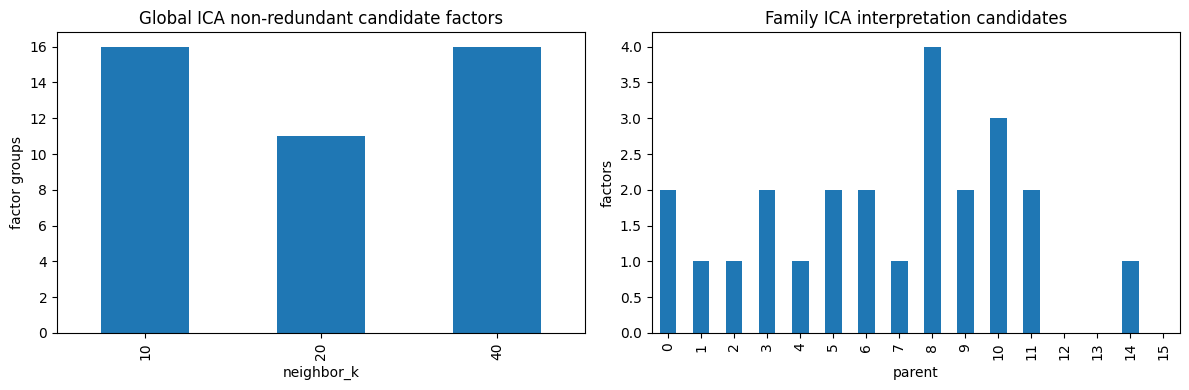

In [40]:
# 41. Family 512-hires ICA: select rank 2–6 independently inside each current-run parent.

FAMILY_ICA_BY_PARENT = {}
family_summary = []
family_rows = []
for g in sorted(np.unique(PARENT_LABELS)):
    ids = np.flatnonzero(PARENT_LABELS == g)
    if len(ids) < FAMILY_ICA_MIN_N:
        continue
    ranktab = []
    for rank in FAMILY_ICA_RANK_CANDIDATES:
        if rank >= max(2, len(ids) // 12):
            continue
        R = identity_neighbor_residual(H512_HR, FAMILY_ICA_NEIGHBORS, ids, ids)
        runs = []
        for s in ICA_SEEDS:
            try:
                m, W, A = fit_ica_raw(R, rank, s)
                runs.append((s, m, W, A))
            except Exception:
                pass
        if len(runs) < 2:
            continue
        stab = float(np.median([np.median(factor_match(runs[i][3], runs[j][3])[2]) for i in range(len(runs)) for j in range(i + 1,
            len(runs))]))
        recon = heldout_ica_recon(H512_HR, FAMILY_ICA_NEIGHBORS, rank, ids, 3)
        ranktab.append({'parent': int(g), 'rank': rank, 'seed_stability': stab, 'heldout_recon': recon})
    rdf = pd.DataFrame(ranktab)
    rdf = rdf[np.isfinite(rdf.heldout_recon)].copy()
    if len(rdf) == 0:
        continue
    rdf['neg_recon'] = -rdf.heldout_recon
    rdf['pareto'] = pareto_mask(rdf, ['seed_stability', 'neg_recon'])
    pr = rdf[rdf.pareto]
    be = pr.heldout_recon.min()
    pr = pr[pr.heldout_recon <= be * 1.15]
    rank = int(pr.sort_values(['rank', 'seed_stability'], ascending=[True, False]).iloc[0]['rank'])
    R = identity_neighbor_residual(H512_HR, FAMILY_ICA_NEIGHBORS, ids, ids)
    seed, model, W, A, order, seedstab = medoid_ica(R, rank)
    bst = bootstrap_factor_stability(H512_HR, FAMILY_ICA_NEIGHBORS, ids, A, rank)
    post = postmap_from_scores(model, R, W)
    joblib.dump(model, OUT / 'models' / f'family_ica_parent_{int(g):02d}_rank{rank}.joblib')
    np.save(OUT / 'models' / f'family_ica_parent_{int(g):02d}_postmap.npy', post)
    np.save(OUT / 'attributes' / f'family_ica_parent_{int(g):02d}_scores.npy', W)
    rows = []
    for f, (med, q10) in enumerate(bst):
        sc = W[:, f]
        row = {'parent': int(g),
            'factor': f,
            'rank': rank,
            'n': len(ids),
            'ica_seed': int(seed),
            'seed_medoid_stability': seedstab,
            'bootstrap_match_median': med,
            'bootstrap_match_q10': q10,
            'stable': bool(med >= FACTOR_STABLE_MEDIAN and q10 >= FACTOR_STABLE_Q10),
            'eta2_validated_fine': categorical_eta_squared(sc, FINE_GROUP_LABELS[ids]),
            'eta2_raw_visual': categorical_eta_squared(sc, RAW_VISUAL_LABELS[ids]),
            'nuisance_r2': nuisance_cross_validated_r2(sc, ids)}
        row['candidate_for_interpretation'] = row['stable'] and row['eta2_validated_fine'] < FACTOR_IDENTITY_ETA2_WARN and (row['nuisance_r2'] < FACTOR_NUISANCE_R2_WARN)
        rows.append(row)
        family_rows.append(row)
    FAMILY_ICA_BY_PARENT[int(g)] = {'ids': ids, 'rank': rank, 'W': W, 'A': A, 'model': model, 'post': post}
    family_summary.append({'parent': int(g),
        'n': len(ids),
        'rank': rank,
        'heldout_recon': float(rdf.loc[rdf['rank'] == rank, 'heldout_recon'].iloc[0]),
        'seed_stability': float(rdf.loc[rdf['rank'] == rank, 'seed_stability'].iloc[0]),
        'stable_factors': int(sum((r['stable'] for r in rows))),
        'candidate_factors': int(sum((r['candidate_for_interpretation'] for r in rows)))})
FAMILY_SUM = pd.DataFrame(family_summary,
    columns=['parent', 'n', 'rank', 'heldout_recon', 'seed_stability', 'stable_factors', 'candidate_factors'])
FAMILY_FACTOR_METRICS = pd.DataFrame(family_rows,
    columns=['parent', 'factor', 'rank', 'n', 'ica_seed', 'seed_medoid_stability', 'bootstrap_match_median', 'bootstrap_match_q10', 'stable', 'eta2_validated_fine', 'eta2_raw_visual', 'nuisance_r2', 'candidate_for_interpretation'])
FAMILY_SUM.to_csv(OUT / 'metrics' / 'family_ica_selection.csv', index=False)
FAMILY_FACTOR_METRICS.to_csv(OUT / 'metrics' / 'family_ica_factor_metrics.csv', index=False)
display(FAMILY_SUM)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
GLOBAL_CONFIG_SUM.set_index('neighbor_k').candidate_redundancy_groups.plot(kind='bar', ax=axs[0])
axs[0].set_title('Global ICA non-redundant candidate factors')
axs[0].set_ylabel('factor groups')
(FAMILY_SUM.set_index('parent').candidate_factors if len(FAMILY_SUM) else pd.Series(dtype=float)).plot(kind='bar',
    ax=axs[1])
axs[1].set_title('Family ICA interpretation candidates')
axs[1].set_ylabel('factors')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'ica_selection_summary.png', dpi=170)
plt.show()


## 9. Local patch atypicality 16×16

Descriptor patch DINO pada foreground dibandingkan dengan citra referensi yang identity-similar dan berasal dari parent yang sama. Outputnya adalah **identity-relative local visual atypicality**, bukan probabilitas kerusakan yang terkalibrasi.


In [41]:
# 42. Resumable 16×16 foreground DINO descriptor grid.

def valid_npy(path, shape, dtype):
    try:
        x = np.load(path, mmap_mode='r')
        return tuple(x.shape) == tuple(shape) and np.dtype(x.dtype) == np.dtype(dtype) and np.isfinite(np.asarray(x[:min(4, len(x))],
            np.float32)).all()
    except Exception:
        return False
DENSE_MAP = {}
grid = 16
p = OUT / 'cache' / 'dense_patch16x16_128_f16.npy'
meta = OUT / 'cache' / 'dense_patch16_complete.json'
fp = sha256_object({'cohort': COHORT_FP,
    'feature': FEATURE_FP,
    'grid': grid,
    'attr_short': ATTR_SHORT,
    'attr_max_long': ATTR_MAX_LONG,
    'mid_pca': sha256_file(MID_PCA_PATH),
    'late_pca': sha256_file(LATE_PCA_PATH),
    'bbox': sha256_file(BBOX_PATH),
    'crop_margin': FOREGROUND_MARGIN})
ok = p.is_file() and meta.is_file() and valid_npy(p, (N_CANONICAL, 256, 128), np.float16)
if ok:
    try:
        ok = json.loads(meta.read_text()).get('fingerprint') == fp
    except Exception:
        ok = False
if not ok:
    part = Path(str(p) + '.partial.npy')
    prog = OUT / 'cache' / 'dense16_progress.json'
    start = 0
    if prog.is_file() and valid_npy(part, (N_CANONICAL, 256, 128), np.float16):
        try:
            q = json.loads(prog.read_text())
            start = min(N_CANONICAL,
                max(0, int(q.get('next_index', 0)))) if q.get('fingerprint') == fp else 0
        except Exception:
            start = 0
    if start == 0:
        part.unlink(missing_ok=True)
    load_advanced_dino()
    import torch.nn.functional as Fnn
    M = np.lib.format.open_memmap(part,
        mode='r+' if start and part.is_file() else 'w+',
        dtype=np.float16,
        shape=(N_CANONICAL, 256, 128))
    for i in range(start, N_CANONICAL):
        gpu_attempt_log('dense16', i, CANONICAL_NODES.iloc[i].image_path, None)
        rec = adv_forward(bbox_crop(load_rgb_image(CANONICAL_NODES.iloc[i].image_path), FOREGROUND_BOXES[i], FOREGROUND_MARGIN),
            ATTR_SHORT,
            ATTR_MAX_LONG)
        D = build_advanced_patch_descriptor(rec['mid'], rec['late'])
        gh, gw = rec['grid']
        T = torch.from_numpy(D.reshape(gh, gw, -1)).permute(2, 0, 1)[None]
        M[i] = normalize_rows_l2(Fnn.adaptive_avg_pool2d(T,
            (16, 16))[0].permute(1,
            2,
            0).reshape(-1,
            128).numpy()).astype(np.float16)
        if (i + 1) % DENSE_PROGRESS_EVERY == 0 or i + 1 == N_CANONICAL:
            M.flush()
            write_json_atomic(prog, {'fingerprint': fp, 'next_index': i + 1})
            print('dense16', i + 1, '/', N_CANONICAL)
    M.flush()
    del M
    unload_advanced_dino()
    os.replace(part, p)
    write_json_atomic(meta, {'fingerprint': fp})
    prog.unlink(missing_ok=True)
DENSE_MAP[16] = np.load(p, mmap_mode='r')


In [42]:
# 43. Local identity-neighbour patch deviation + robust local normalization.

def fps(X, k):
    X = normalize_rows_l2(np.asarray(X, np.float32))
    k = min(k, len(X))
    sel = [int(np.argmax(np.linalg.norm(X - X.mean(0), axis=1)))]
    mind = 1 - X @ X[sel[0]]
    for _ in range(1, k):
        j = int(np.argmax(mind))
        sel.append(j)
        mind = np.minimum(mind, 1 - X @ X[j])
    return X[sel]
PATCH_RESULTS = {}
PATCH_AUDIT = []
NEIGH_SHA = hashlib.sha256(np.asarray(G_NEIGH, np.int32).tobytes()).hexdigest()
for grid, DENSE in DENSE_MAP.items():
    kproto = PATCH_PROTOTYPES[grid]
    pp = OUT / 'cache' / f'patch_proto_g{grid}.npy'
    pm = OUT / 'cache' / f'patch_proto_g{grid}.json'
    dp = OUT / 'patch_deviation' / f'devmap_g{grid}.npy'
    dm = OUT / 'patch_deviation' / f'devmap_g{grid}.json'
    dense_meta = OUT / 'cache' / (f'dense_patch{grid}_complete.json' if grid != 16 else 'dense_patch16_complete.json')
    dense_fp = json.loads(dense_meta.read_text()).get('fingerprint') if dense_meta.is_file() else None
    pfp = sha256_object({'cohort': COHORT_FP, 'dense_fp': dense_fp, 'grid': grid, 'prototypes': kproto})
    pok = valid_npy(pp, (N_CANONICAL, kproto, 128), np.float16) and pm.is_file()
    if pok:
        try:
            pok = json.loads(pm.read_text()).get('fingerprint') == pfp
        except Exception:
            pok = False
    if pok:
        PROT = np.load(pp, mmap_mode='r')
    else:
        mm = np.lib.format.open_memmap(pp, mode='w+', dtype=np.float16, shape=(N_CANONICAL, kproto, 128))
        for i in range(N_CANONICAL):
            mm[i] = fps(DENSE[i], kproto).astype(np.float16)
        mm.flush()
        del mm
        write_json_atomic(pm, {'fingerprint': pfp})
        PROT = np.load(pp, mmap_mode='r')
    dfp = sha256_object({'cohort': COHORT_FP,
        'prototype_fp': pfp,
        'neighbor_sha': NEIGH_SHA,
        'local_neighbors': LOCAL_PATCH_NEIGHBORS})
    dok = valid_npy(dp, (N_CANONICAL, grid, grid), np.float16) and dm.is_file()
    if dok:
        try:
            dok = json.loads(dm.read_text()).get('fingerprint') == dfp
        except Exception:
            dok = False
    if dok:
        DM = np.load(dp, mmap_mode='r')
    else:
        mm = np.lib.format.open_memmap(dp, mode='w+', dtype=np.float16, shape=(N_CANONICAL, grid, grid))
        for i in range(N_CANONICAL):
            ns = G_NEIGH[i]
            ns = ns[ns >= 0][:LOCAL_PATCH_NEIGHBORS]
            ref = np.asarray(PROT[ns],
                np.float32).reshape(-1,
                128) if len(ns) else np.asarray(PROT[i],
                np.float32)
            q = normalize_rows_l2(np.asarray(DENSE[i], np.float32))
            mm[i] = (1 - np.max(q @ normalize_rows_l2(ref).T, axis=1)).reshape(grid,
                grid).astype(np.float16)
            if (i + 1) % 200 == 0:
                mm.flush()
        mm.flush()
        del mm
        write_json_atomic(dm, {'fingerprint': dfp})
        DM = np.load(dp, mmap_mode='r')
    raw = np.asarray(DM, np.float32).reshape(N_CANONICAL, -1)
    S = np.c_[np.quantile(raw, 0.9, axis=1),
        np.quantile(raw, 0.95, axis=1),
        np.quantile(raw, 0.99, axis=1),
        raw.mean(1),
        raw.std(1)]
    z = np.zeros(N_CANONICAL)
    pct = np.zeros(N_CANONICAL)
    for i in range(N_CANONICAL):
        ns = G_NEIGH[i]
        ns = ns[ns >= 0][:max(20, LOCAL_PATCH_NEIGHBORS)]
        vals = S[ns, 2] if len(ns) else S[PARENT_LABELS == PARENT_LABELS[i], 2]
        med = np.median(vals)
        mad = np.median(np.abs(vals - med))
        z[i] = (S[i, 2] - med) / max(1.4826 * mad, 0.0001)
        pct[i] = (1 + (vals <= S[i, 2]).sum()) / (len(vals) + 1)
    S = np.c_[S, z, pct]
    PATCH_RESULTS[grid] = {'map': DM, 'stats': S}
    PATCH_AUDIT.append({'grid': grid,
        'eta2_parent_raw_q99': categorical_eta_squared(S[:, 2], PARENT_LABELS),
        'eta2_fine_raw_q99': categorical_eta_squared(S[:, 2], FINE_GROUP_LABELS),
        'nuisance_r2_raw_q99': nuisance_cross_validated_r2(S[:, 2]),
        'eta2_parent_percentile': categorical_eta_squared(S[:, -1], PARENT_LABELS),
        'eta2_fine_percentile': categorical_eta_squared(S[:, -1], FINE_GROUP_LABELS),
        'nuisance_r2_percentile': nuisance_cross_validated_r2(S[:, -1])})
    pd.DataFrame(S,
        columns=['q90', 'q95', 'q99', 'mean', 'std', 'local_z_q99', 'local_percentile_q99']).to_csv(OUT / 'patch_deviation' / f'patch_stats_g{grid}.csv',
        index=False)
PATCH_AUDIT = pd.DataFrame(PATCH_AUDIT)
PATCH_AUDIT.to_csv(OUT / 'metrics' / 'patch_grid_comparison.csv', index=False)
display(PATCH_AUDIT)


,grid,eta2_parent_raw_q99,eta2_fine_raw_q99,nuisance_r2_raw_q99,eta2_parent_percentile,eta2_fine_percentile,nuisance_r2_percentile
0,16,0.148889,0.137979,0.146151,0.014432,0.018851,0.049464


## 10. Evaluasi final struktur numerik

Semua assignment numerik telah ditetapkan sebelum bagian ini. Parent, fine group, raw visual leaf, ICA, dan patch assignment tidak diubah berdasarkan hasil audit berikutnya.

Untuk menghindari penggunaan ulang urutan resampling yang sama dengan tahap seleksi, audit final menggunakan `FINAL_AUDIT_SEED` dan jumlah repetition yang lebih besar. Evaluasi meliputi:

- resampling stability dan routing broad parent;
- stability/routing fine group dan child survival;
- stability/routing raw visual leaf;
- konsistensi near-duplicate;
- negative control berbasis background;
- leakage local patch atypicality terhadap taxonomy;
- robustness terhadap controlled degradation.


In [43]:
# 47. Independent final audit helpers and broad-parent evaluation.

def assignment_agreement_on_near_duplicate_edges(labels, require_known=False):
    """Measure label agreement across the primary validation-only near-duplicate edges."""
    labels = np.asarray(labels)
    agreements = []
    for edge in NEAR_BY_RULE[VAL_GROUP_RULE]:
        left = int(edge[0])
        right = int(edge[1])
        if require_known and (labels[left] < 0 or labels[right] < 0):
            continue
        agreements.append(bool(labels[left] == labels[right]))
    return {
        'eligible_edges': int(len(agreements)),
        'agreement': float(np.mean(agreements)) if agreements else np.nan,
    }


def class_reliability_table(events, labels, id_name):
    """Compute recall/precision/reliability by frozen class ID from withholding events."""
    rows = []
    for class_id in sorted(int(x) for x in np.unique(labels) if int(x) >= 0):
        true_events = events[events['true'] == class_id]
        predicted_events = events[events['pred'] == class_id]
        recall = float(true_events['correct'].mean()) if len(true_events) else 0.0
        precision = (
            float(predicted_events['correct'].mean())
            if len(predicted_events)
            else 0.0
        )
        rows.append({
            id_name: class_id,
            'withholding_recall': recall,
            'withholding_precision': precision,
            'operational_reliability': min(recall, precision),
        })
    return pd.DataFrame(rows)


# ---- broad parent audit ------------------------------------------------------
root_group_ari, root_group_ari_q10, root_group_ari_min = group_resample_ari_kmeans(
    SELECTED_ROOT_FEATURES,
    VALIDATION_GROUPS,
    PARENT_LABELS,
    int(chosen['k']),
    reps=FINAL_AUDIT_GROUP_SPLIT_REPS,
    random_state=FINAL_AUDIT_SEED + 10,
)
FINAL_ROOT_EVENTS = withholding_events(
    SELECTED_ROOT_FEATURES,
    PARENT_LABELS,
    VALIDATION_GROUPS,
    reps=FINAL_AUDIT_HOLDOUT_REPS,
    random_state=FINAL_AUDIT_SEED + 20,
)
FINAL_ROOT_EVENTS['global_idx'] = FINAL_ROOT_EVENTS['local_idx']
FINAL_ROOT_EVENTS['validation_group_id'] = VALIDATION_GROUPS[
    FINAL_ROOT_EVENTS['global_idx'].to_numpy()
]
FINAL_ROOT_EVENTS.to_csv(
    OUT / 'validation' / 'root_withholding_events_final_audit.csv',
    index=False,
)
final_root_routing = routing_summary(FINAL_ROOT_EVENTS)
FINAL_PARENT_AUDIT_RELIABILITY = class_reliability_table(
    FINAL_ROOT_EVENTS,
    PARENT_LABELS,
    'parent_id',
)
FINAL_PARENT_AUDIT_RELIABILITY['n'] = [
    int((PARENT_LABELS == parent_id).sum())
    for parent_id in FINAL_PARENT_AUDIT_RELIABILITY['parent_id']
]
FINAL_PARENT_AUDIT_RELIABILITY['residual_under_audit_threshold'] = (
    FINAL_PARENT_AUDIT_RELIABILITY['operational_reliability']
    < RESIDUAL_PARENT_RELIABILITY
)
FINAL_PARENT_AUDIT_RELIABILITY.to_csv(
    OUT / 'metrics' / 'parent_reliability_final_audit.csv',
    index=False,
)

In [44]:
# 48. Independent final audit of validated fine groups and raw-visual leaves.

# ---- deployed fine-group audit ---------------------------------------------
fine_parent_rows = []
fine_child_rows = []
fine_event_frames = []
for parent_id in sorted(fine_models):
    ids = np.flatnonzero(PARENT_LABELS == parent_id)
    selection_obj = FINE_SELECTION[parent_id]['obj']
    selected_features = selection_obj['X']
    final_labels = FINE_GROUP_LABELS[ids]

    provisional_group_ari, provisional_q10, provisional_min = group_resample_ari_kmeans(
        selected_features,
        VALIDATION_GROUPS[ids],
        selection_obj['y'],
        int(selection_obj['k']),
        reps=FINAL_AUDIT_GROUP_SPLIT_REPS,
        random_state=FINAL_AUDIT_SEED + 1000 + int(parent_id),
    )
    events = withholding_events(
        selected_features,
        final_labels,
        VALIDATION_GROUPS[ids],
        reps=FINAL_AUDIT_HOLDOUT_REPS,
        random_state=FINAL_AUDIT_SEED + 2000 + int(parent_id),
    )
    events['parent'] = int(parent_id)
    events['global_idx'] = ids[events['local_idx'].to_numpy()]
    events['validation_group_id'] = VALIDATION_GROUPS[
        events['global_idx'].to_numpy()
    ]
    fine_event_frames.append(events)
    routing = routing_summary(events)
    survival = child_survival(
        selection_obj,
        reps=FINAL_AUDIT_GROUP_SPLIT_REPS,
        random_state=FINAL_AUDIT_SEED + 3000 + int(parent_id),
    )

    deployed_rows = FINE_GROUP_MAP[
        FINE_GROUP_MAP['parent_id'] == parent_id
    ]
    for _, mapping in deployed_rows.iterrows():
        fine_id = int(mapping['validated_fine_group_id'])
        local_child = int(mapping['local_child_id'])
        child_events = events[events['true'] == fine_id]
        survival_values = survival.get(local_child, [])
        fine_child_rows.append({
            'parent': int(parent_id),
            'validated_fine_group_id': fine_id,
            'local_child_id': local_child,
            'n': int((FINE_GROUP_LABELS == fine_id).sum()),
            'withholding_recall': (
                float(child_events['correct'].mean())
                if len(child_events)
                else np.nan
            ),
            'survival_median': (
                float(np.median(survival_values))
                if survival_values
                else np.nan
            ),
            'survival_q10': (
                float(np.quantile(survival_values, 0.1))
                if survival_values
                else np.nan
            ),
        })

    fine_parent_rows.append({
        'parent': int(parent_id),
        'view': str(selection_obj['view']),
        'provisional_k': int(selection_obj['k']),
        'deployed_groups': int(len(deployed_rows)),
        'coverage_within_parent': float(np.mean(final_labels >= 0)),
        'silhouette_deployed': cosine_silhouette_score(
            selected_features,
            final_labels,
        ),
        'provisional_partition_group_ari': provisional_group_ari,
        'provisional_partition_group_ari_q10': provisional_q10,
        'routing_macro': routing['routing_macro'],
        'routing_q10': routing['routing_q10'],
        'precision_macro': routing['precision_macro'],
        'precision_q10': routing['precision_q10'],
    })

FINAL_FINE_PARENT_AUDIT = pd.DataFrame(fine_parent_rows)
FINAL_FINE_CHILD_AUDIT = pd.DataFrame(fine_child_rows)
FINAL_FINE_EVENTS = (
    pd.concat(fine_event_frames, ignore_index=True)
    if fine_event_frames
    else pd.DataFrame()
)
FINAL_FINE_PARENT_AUDIT.to_csv(
    OUT / 'metrics' / 'fine_parent_final_audit.csv',
    index=False,
)
FINAL_FINE_CHILD_AUDIT.to_csv(
    OUT / 'metrics' / 'fine_child_final_audit.csv',
    index=False,
)
if len(FINAL_FINE_EVENTS):
    FINAL_FINE_EVENTS.to_csv(
        OUT / 'validation' / 'fine_withholding_events_final_audit.csv',
        index=False,
    )
final_fine_routing = (
    routing_summary(FINAL_FINE_EVENTS)
    if len(FINAL_FINE_EVENTS)
    else {key: np.nan for key in routing_summary(pd.DataFrame({
        'true': [], 'pred': [], 'correct': []
    })).keys()}
)


# ---- complementary raw-visual audit ----------------------------------------
raw_parent_rows = []
raw_event_frames = []
for parent_id in sorted(np.unique(PARENT_LABELS)):
    selection_row = RAW_VISUAL_SELECTION.get(int(parent_id))
    if selection_row is None:
        raw_parent_rows.append({
            'parent': int(parent_id),
            'view': 'parent_only',
            'k': 1,
            'group_ari': np.nan,
            'group_ari_q10': np.nan,
            'routing_macro': np.nan,
            'routing_q10': np.nan,
            'silhouette': np.nan,
            'nuisance_excess': np.nan,
        })
        continue

    candidate_table, candidate_parts = RAW_VISUAL_CANDIDATES[int(parent_id)]
    selected_hash = str(selection_row['hash'])
    selected_obj = candidate_parts[selected_hash]
    local_labels = selected_obj['y']
    features = selected_obj['X']
    ids = selected_obj['ids']

    group_ari, group_ari_q10, _ = group_resample_ari_kmeans(
        features,
        VALIDATION_GROUPS[ids],
        local_labels,
        int(selected_obj['k']),
        reps=FINAL_AUDIT_GROUP_SPLIT_REPS,
        random_state=FINAL_AUDIT_SEED + 4000 + int(parent_id),
    )
    local_events = withholding_events(
        features,
        local_labels,
        VALIDATION_GROUPS[ids],
        reps=FINAL_AUDIT_HOLDOUT_REPS,
        random_state=FINAL_AUDIT_SEED + 5000 + int(parent_id),
    )
    local_routing = routing_summary(local_events)

    # Convert local visual IDs to globally unique raw_visual_leaf_id values before
    # concatenating events across parents.
    local_to_global = {
        int(row['local_visual_id']): int(row['raw_visual_leaf_id'])
        for _, row in RAW_VISUAL_MAP_TABLE[
            RAW_VISUAL_MAP_TABLE['parent_id'] == parent_id
        ].iterrows()
    }
    global_events = local_events.copy()
    global_events['true'] = global_events['true'].map(local_to_global).fillna(-1).astype(int)
    global_events['pred'] = global_events['pred'].map(local_to_global).fillna(-1).astype(int)
    global_events['correct'] = (
        global_events['true'] == global_events['pred']
    ).astype(int)
    global_events['parent'] = int(parent_id)
    global_events['global_idx'] = ids[global_events['local_idx'].to_numpy()]
    raw_event_frames.append(global_events)

    raw_parent_rows.append({
        'parent': int(parent_id),
        'view': str(selected_obj['view']),
        'k': int(selected_obj['k']),
        'group_ari': group_ari,
        'group_ari_q10': group_ari_q10,
        'routing_macro': local_routing['routing_macro'],
        'routing_q10': local_routing['routing_q10'],
        'silhouette': cosine_silhouette_score(features, local_labels),
        'nuisance_excess': float(selection_row['nuisance_excess']),
    })

FINAL_RAW_VISUAL_AUDIT = pd.DataFrame(raw_parent_rows)
FINAL_RAW_VISUAL_EVENTS = (
    pd.concat(raw_event_frames, ignore_index=True)
    if raw_event_frames
    else pd.DataFrame()
)
FINAL_RAW_VISUAL_AUDIT.to_csv(
    OUT / 'metrics' / 'raw_visual_final_audit.csv',
    index=False,
)
if len(FINAL_RAW_VISUAL_EVENTS):
    FINAL_RAW_VISUAL_EVENTS.to_csv(
        OUT / 'validation' / 'raw_visual_withholding_events_final_audit.csv',
        index=False,
    )
final_raw_routing = (
    routing_summary(FINAL_RAW_VISUAL_EVENTS)
    if len(FINAL_RAW_VISUAL_EVENTS)
    else {key: np.nan for key in final_root_routing}
)

,structure,groups,coverage,silhouette,group_ari,group_ari_q10,routing_macro,routing_q10,precision_q10,near_duplicate_agreement
0,broad_parent,16,1.000000,0.478345,0.954343,0.905217,0.965003,0.948229,0.920683,0.937008
1,validated_fine,28,0.653309,0.457189,0.981395,0.927922,0.965950,0.891273,0.937097,0.966292
2,raw_visual,48,1.000000,0.202202,0.961300,0.911512,0.915234,0.747905,0.886488,0.811024


,parent_id,withholding_recall,withholding_precision,operational_reliability,n,residual_under_audit_threshold
0,0,0.710191,0.978929,0.710191,384,True
1,1,0.992795,0.965662,0.965662,368,False
2,2,0.980240,0.967944,0.967944,354,False
3,3,1.000000,0.978503,0.978503,304,False
4,4,0.995234,0.951686,0.951686,269,False
5,5,0.991321,0.976258,0.976258,263,False
6,6,0.981188,0.934906,0.934906,252,False
7,7,1.000000,0.960486,0.960486,235,False
8,8,0.960744,0.914454,0.914454,232,False
9,9,0.963678,0.918831,0.918831,218,False


,structure,eligible_edges,agreement
0,parent,127,0.937008
1,validated_fine,89,0.966292
2,raw_visual,127,0.811024


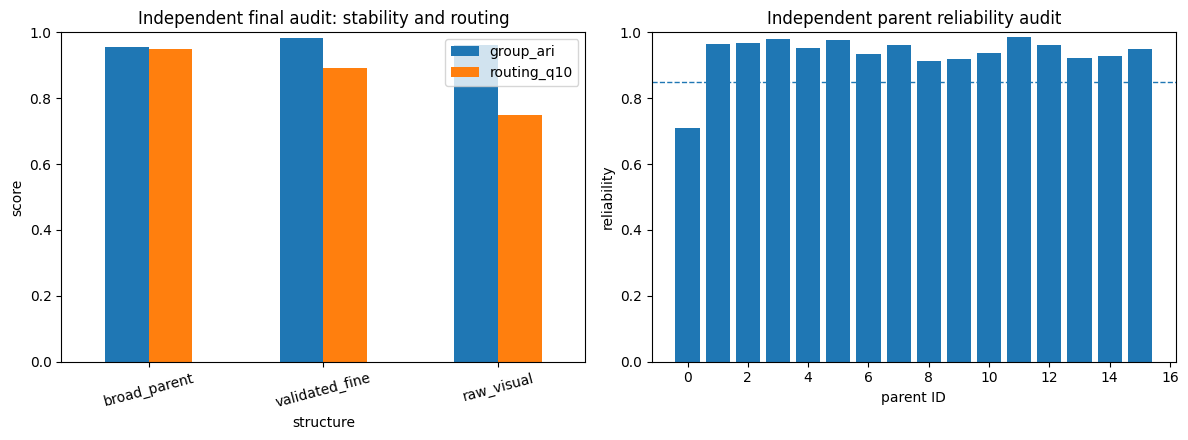

In [45]:
# 49. Near-duplicate consistency and unified clustering-evaluation table.

# ---- near-duplicate consistency --------------------------------------------
parent_near_dup = assignment_agreement_on_near_duplicate_edges(PARENT_LABELS)
fine_near_dup = assignment_agreement_on_near_duplicate_edges(
    FINE_GROUP_LABELS,
    require_known=True,
)
raw_near_dup = assignment_agreement_on_near_duplicate_edges(RAW_VISUAL_LABELS)
NEAR_DUPLICATE_ASSIGNMENT_AUDIT = pd.DataFrame([
    {'structure': 'parent', **parent_near_dup},
    {'structure': 'validated_fine', **fine_near_dup},
    {'structure': 'raw_visual', **raw_near_dup},
])
NEAR_DUPLICATE_ASSIGNMENT_AUDIT.to_csv(
    OUT / 'metrics' / 'near_duplicate_assignment_agreement.csv',
    index=False,
)


# ---- compact clustering evaluation table -----------------------------------
FINAL_CLUSTERING_EVALUATION = pd.DataFrame([
    {
        'structure': 'broad_parent',
        'groups': int(len(np.unique(PARENT_LABELS))),
        'coverage': 1.0,
        'silhouette': cosine_silhouette_score(
            SELECTED_ROOT_FEATURES,
            PARENT_LABELS,
        ),
        'group_ari': root_group_ari,
        'group_ari_q10': root_group_ari_q10,
        'routing_macro': final_root_routing['routing_macro'],
        'routing_q10': final_root_routing['routing_q10'],
        'precision_q10': final_root_routing['precision_q10'],
        'near_duplicate_agreement': parent_near_dup['agreement'],
    },
    {
        'structure': 'validated_fine',
        'groups': int(FINE_GROUP_MAP['validated_fine_group_id'].nunique())
        if len(FINE_GROUP_MAP) else 0,
        'coverage': float(np.mean(FINE_GROUP_LABELS >= 0)),
        'silhouette': float(FINAL_FINE_PARENT_AUDIT['silhouette_deployed'].median())
        if len(FINAL_FINE_PARENT_AUDIT) else np.nan,
        'group_ari': float(
            FINAL_FINE_PARENT_AUDIT['provisional_partition_group_ari'].median()
        ) if len(FINAL_FINE_PARENT_AUDIT) else np.nan,
        'group_ari_q10': float(
            FINAL_FINE_PARENT_AUDIT['provisional_partition_group_ari_q10'].median()
        ) if len(FINAL_FINE_PARENT_AUDIT) else np.nan,
        'routing_macro': final_fine_routing['routing_macro'],
        'routing_q10': final_fine_routing['routing_q10'],
        'precision_q10': final_fine_routing['precision_q10'],
        'near_duplicate_agreement': fine_near_dup['agreement'],
    },
    {
        'structure': 'raw_visual',
        'groups': int(RAW_VISUAL_MAP_TABLE['raw_visual_leaf_id'].nunique()),
        'coverage': 1.0,
        'silhouette': float(FINAL_RAW_VISUAL_AUDIT['silhouette'].median()),
        'group_ari': float(FINAL_RAW_VISUAL_AUDIT['group_ari'].median()),
        'group_ari_q10': float(FINAL_RAW_VISUAL_AUDIT['group_ari_q10'].median()),
        'routing_macro': final_raw_routing['routing_macro'],
        'routing_q10': final_raw_routing['routing_q10'],
        'precision_q10': final_raw_routing['precision_q10'],
        'near_duplicate_agreement': raw_near_dup['agreement'],
    },
])
FINAL_CLUSTERING_EVALUATION.to_csv(
    OUT / 'metrics' / 'final_clustering_evaluation.csv',
    index=False,
)

display(FINAL_CLUSTERING_EVALUATION)
display(FINAL_PARENT_AUDIT_RELIABILITY)
display(NEAR_DUPLICATE_ASSIGNMENT_AUDIT)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_eval = FINAL_CLUSTERING_EVALUATION.set_index('structure')
plot_eval[['group_ari', 'routing_q10']].plot(kind='bar', ylim=(0, 1), ax=axes[0])
axes[0].set_ylabel('score')
axes[0].set_title('Independent final audit: stability and routing')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(
    FINAL_PARENT_AUDIT_RELIABILITY['parent_id'],
    FINAL_PARENT_AUDIT_RELIABILITY['operational_reliability'],
)
axes[1].axhline(RESIDUAL_PARENT_RELIABILITY, linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('parent ID')
axes[1].set_ylabel('reliability')
axes[1].set_title('Independent parent reliability audit')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'final_clustering_audit.png', dpi=180)
plt.show()

### 10A. Negative control dan robustness

Pemeriksaan berikut dilakukan setelah selection selesai. Background-only clustering menguji apakah struktur beku dapat direproduksi hanya dari informasi acquisition/context; patch metrics diperiksa terhadap parent/fine/nuisance leakage; dan controlled degradation digunakan untuk mengukur ketahanan assignment.

Hasil bagian ini bersifat diagnostik dan tidak mengubah assignment.


In [46]:
# 50. Background-only negative control for the frozen structures.

bg = np.asarray(DINO_CONCEPT_BACKGROUND, np.float32).copy()
ok = bg.sum(1) > 1e-08
if ok.any():
    bg[~ok] = bg[ok].mean(0)
BG_VIEW = normalize_rows_l2(PCA(n_components=min(64, bg.shape[1], N_CANONICAL - 1),
    random_state=SEED).fit_transform(bg))
rows = []
kroot = len(np.unique(PARENT_LABELS))
yb = KMeans(n_clusters=kroot, n_init=20, random_state=FINAL_AUDIT_SEED).fit(BG_VIEW).labels_
rows.append({'level': 'root',
    'parent': -1,
    'target_groups': kroot,
    'background_silhouette': cosine_silhouette_score(BG_VIEW, yb),
    'ari_to_target': adjusted_rand_score(PARENT_LABELS, yb),
    'nmi_to_target': normalized_mutual_info_score(PARENT_LABELS, yb)})
for g in sorted(fine_models):
    ids = np.flatnonzero(PARENT_LABELS == g)
    y = FINE_GROUP_LABELS[ids]
    m = y >= 0
    k = len(np.unique(y[m]))
    if k < 2:
        continue
    yy = KMeans(n_clusters=k, n_init=20, random_state=FINAL_AUDIT_SEED + int(g)).fit(BG_VIEW[ids]).labels_
    rows.append({'level': 'fine',
        'parent': g,
        'target_groups': k,
        'background_silhouette': cosine_silhouette_score(BG_VIEW[ids], yy),
        'ari_to_target': adjusted_rand_score(y[m], yy[m]),
        'nmi_to_target': normalized_mutual_info_score(y[m], yy[m])})
BG_CONTROL = pd.DataFrame(rows)
BG_CONTROL.to_csv(OUT / 'metrics' / 'background_negative_control.csv', index=False)
display(BG_CONTROL)


,level,parent,target_groups,background_silhouette,ari_to_target,nmi_to_target
0,root,-1,16,0.243438,0.095613,0.227657
1,fine,1,2,0.164880,-0.042331,0.059196
2,fine,2,4,0.228727,0.017810,0.052256
3,fine,3,2,0.391904,0.016780,0.003821
4,fine,4,2,0.372954,0.078527,0.061175
5,fine,6,3,0.179895,0.144920,0.130450
6,fine,8,2,0.181473,0.008461,0.012445
7,fine,9,2,0.253270,0.485764,0.400504
8,fine,10,4,0.396822,0.061486,0.082877
9,fine,12,2,0.246926,-0.009208,0.002054


,grid,eta2_parent_raw_q99,eta2_fine_raw_q99,nuisance_r2_raw_q99,eta2_parent_percentile,eta2_fine_percentile,nuisance_r2_percentile
0,16,0.148889,0.137979,0.146151,0.014432,0.018851,0.049464


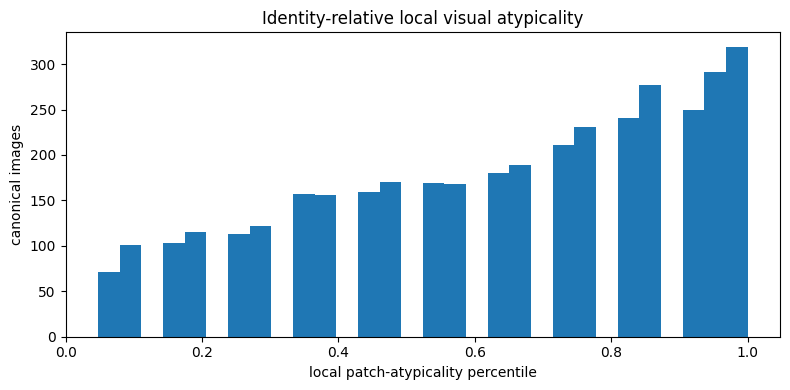

In [47]:
# 51. Final patch-atypicality leakage audit.

PATCH16_STATS = PATCH_RESULTS[16]['stats']
PATCH_NAMES = ['q90', 'q95', 'q99', 'mean', 'std', 'local_z_q99', 'local_percentile_q99']
PATCH_TABLE = pd.DataFrame(PATCH16_STATS, columns=PATCH_NAMES)
display(PATCH_AUDIT)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(PATCH_TABLE.local_percentile_q99, bins=30)
ax.set_xlabel('local patch-atypicality percentile')
ax.set_ylabel('canonical images')
ax.set_title('Identity-relative local visual atypicality')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'patch_atypicality_distribution.png', dpi=160)
plt.show()


### 10B. Controlled degradation robustness

Assignment parent dan fine group yang telah dibekukan dievaluasi kembali setelah enam jenis degradasi citra terkontrol. Tahap ini merupakan robustness audit dan tidak memengaruhi struktur discovery.


Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

stress jpeg35 40 / 160
stress jpeg35 80 / 160
stress jpeg35 120 / 160
stress jpeg35 160 / 160
stress downsample50 40 / 160
stress downsample50 80 / 160
stress downsample50 120 / 160
stress downsample50 160 / 160
stress brightness80 40 / 160
stress brightness80 80 / 160
stress brightness80 120 / 160
stress brightness80 160 / 160
stress brightness120 40 / 160
stress brightness120 80 / 160
stress brightness120 120 / 160
stress brightness120 160 / 160
stress frame_shift 40 / 160
stress frame_shift 80 / 160
stress frame_shift 120 / 160
stress frame_shift 160 / 160
stress blur 40 / 160
stress blur 80 / 160
stress blur 120 / 160
stress blur 160 / 160


,kind,parent_stability,fine_stability
0,blur,0.96875,0.961905
1,brightness120,0.98750,0.990476
2,brightness80,0.99375,1.000000
3,downsample50,0.97500,0.961905
4,frame_shift,0.98750,1.000000
5,jpeg35,0.96250,0.961905


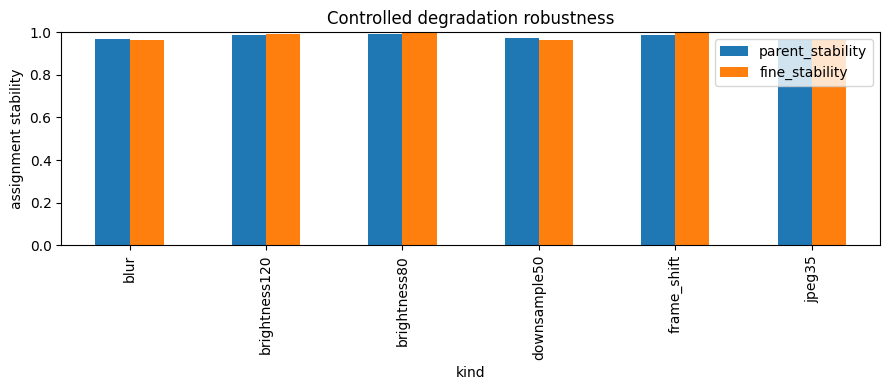

In [48]:
# 52. Controlled-degradation robustness of the frozen assignments.

STRESS = pd.DataFrame()
if RUN_STRESS_TEST:
    required = [CR_PCA_PATH, VLAD_PATCH_PCA_PATH, VLAD_CENTER_PATH, VLAD_OUT_PATH]
    if not all(required):
        raise RuntimeError('Stress validation requires the frozen C-RADIO/DINO transforms.')
    from transformers import AutoModel, AutoImageProcessor
    cmodel, cproc, cdtype, cstep = load_cradio_safe()
    cpca = load_npz_transform(CR_PCA_PATH)
    dproc = AutoImageProcessor.from_pretrained(DINO_DIR, local_files_only=True)
    ddtype = torch.bfloat16 if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported() else torch.float16 if DEVICE.type == 'cuda' else torch.float32
    dmodel = AutoModel.from_pretrained(DINO_DIR,
        local_files_only=True,
        low_cpu_mem_usage=True,
        dtype=ddtype,
        attn_implementation='sdpa').eval().to(DEVICE)
    dpatch = int(getattr(dmodel.config, 'patch_size', 16))
    dreg = int(getattr(dmodel.config, 'num_register_tokens', 0) or 0)
    vpca = load_npz_transform(VLAD_PATCH_PCA_PATH)
    vc = normalize_rows_l2(np.load(VLAD_CENTER_PATH))
    vout = load_npz_transform(VLAD_OUT_PATH)

    def stress_im(im, kind):
        """Apply one fixed controlled degradation used only for robustness validation."""
        if kind == 'jpeg35':
            buf = io.BytesIO()
            im.save(buf, format='JPEG', quality=35)
            buf.seek(0)
            return Image.open(buf).convert('RGB')
        if kind == 'downsample50':
            s = (max(16, im.width // 2), max(16, im.height // 2))
            return im.resize(s, Image.Resampling.BILINEAR).resize(im.size, Image.Resampling.BILINEAR)
        if kind == 'brightness80':
            return ImageEnhance.Brightness(im).enhance(0.8)
        if kind == 'brightness120':
            return ImageEnhance.Brightness(im).enhance(1.2)
        if kind == 'frame_shift':
            w, h = im.size
            dx = max(1, int(0.04 * w))
            dy = max(1, int(0.04 * h))
            return ImageOps.expand(im.crop((dx, dy, w, h)), (0, 0, dx, dy), fill='black').resize((w, h))
        if kind == 'blur':
            return im.filter(ImageFilter.GaussianBlur(radius=1.2))
        return im

    def emb_one(im, b):
        """Re-embed one perturbed image through the frozen root/fine representations for stress testing."""
        go = cradio_embed_pca(cmodel, cproc, cpca, im, cdtype, cstep, False)
        fg = foreground_canvas(im, b)
        gf = cradio_embed_pca(cmodel, cproc, cpca, fg, cdtype, cstep, True)
        cr = bbox_crop(im, b, FOREGROUND_MARGIN)
        th, tw = choose_aspect_preserving_size(cr.height, cr.width, DINO_SHORT, dpatch, DINO_MAX_LONG)
        rr = resize_rgb_exact(cr, th, tw)
        x = dproc(images=rr,
            return_tensors='pt',
            do_resize=False,
            do_center_crop=False).pixel_values.to(DEVICE,
            dtype=ddtype)
        with torch.inference_mode():
            o = dmodel(pixel_values=x)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        p = o.last_hidden_state[:, 1 + dreg:][0].float().cpu().numpy()
        pz = apply_npz_transform(p, vpca)
        assign = np.argmax(pz @ vc.T, axis=1)
        V = np.zeros_like(vc)
        for cc in range(len(vc)):
            m = assign == cc
            if m.any():
                r = (pz[m] - vc[cc]).sum(0)
                V[cc] = r / max(np.linalg.norm(r), 1e-12)
        v = V.reshape(-1)
        v = np.sign(v) * np.sqrt(np.abs(v) + 1e-12)
        lf = apply_npz_transform(normalize_rows_l2(v.reshape(1, -1)), vout)[0]
        gd = normalize_rows_l2(np.c_[go[None] / np.sqrt(2), gf[None] / np.sqrt(2)])[0]
        return (go, gf, gd, lf)
    sample = np.random.default_rng(SEED + 515).choice(N_CANONICAL,
        min(STRESS_N, N_CANONICAL),
        replace=False)
    rows = []
    for kind in STRESS_TRANSFORMS:
        for jj, i in enumerate(sample):
            go, gf, gd, lf = emb_one(stress_im(load_rgb_image(CANONICAL_NODES.iloc[i].image_path), kind),
                FOREGROUND_BOXES[i])
            root_q = {'G_whole': go[None],
                'G_foreground': gf[None],
                'G_dual': gd[None]}[SELECTED_ROOT_VIEW_NAME]
            pp_raw = int(ROOT_KMEANS_MODEL.predict(root_q)[0])
            pp = int(ROOT_LABEL_REMAP[str(pp_raw)] if str(pp_raw) in ROOT_LABEL_REMAP else ROOT_LABEL_REMAP[pp_raw])
            parent_same = int(pp == PARENT_LABELS[i])
            fine_same = np.nan
            if FINE_GROUP_LABELS[i] >= 0:
                g = int(PARENT_LABELS[i])
                model, remap, spec = fine_models[g]
                if spec['view'] == 'G_whole':
                    q = go[None]
                elif spec['view'] == 'G_foreground':
                    q = gf[None]
                elif spec['view'] == 'G_dual':
                    q = gd[None]
                elif spec['view'] == 'Gdual_Lf40':
                    q = weighted_feature_concat(gd[None], lf[None], 0.6, 0.4)
                else:
                    q = weighted_feature_concat(gd[None], lf[None], 0.75, 0.25)
                raw = int(model.predict(q)[0])
                loc = int(remap[str(raw)] if str(raw) in remap else remap[raw])
                fm = FINE_GROUP_MAP[(FINE_GROUP_MAP.parent_id == g) & (FINE_GROUP_MAP.local_child_id == loc)]
                pred = int(fm.validated_fine_group_id.iloc[0]) if len(fm) else -1
                fine_same = int(pred == FINE_GROUP_LABELS[i])
            rows.append({'kind': kind,
                'canonical_index': int(i),
                'parent_same': parent_same,
                'fine_same': fine_same})
            if (jj + 1) % 40 == 0:
                print('stress', kind, jj + 1, '/', len(sample))
    STRESS = pd.DataFrame(rows)
    STRESS.to_csv(OUT / 'validation' / 'stress_test.csv', index=False)
    STRESS_SUM = STRESS.groupby('kind').agg(parent_stability=('parent_same', 'mean'),
        fine_stability=('fine_same', 'mean')).reset_index()
    STRESS_SUM.to_csv(OUT / 'metrics' / 'stress_summary.csv', index=False)
    display(STRESS_SUM)
    fig, ax = plt.subplots(figsize=(9, 4))
    STRESS_SUM.set_index('kind').plot(kind='bar', ylim=(0, 1), ax=ax)
    ax.set_ylabel('assignment stability')
    ax.set_title('Controlled degradation robustness')
    plt.tight_layout()
    plt.savefig(OUT / 'plots' / 'stress_stability.png', dpi=160)
    plt.show()
    del cmodel, dmodel, cproc, dproc
    release_cuda_memory()


,0
selected_root,G_foreground__K16
broad_parents,16
validated_fine_groups,28
raw_visual_leaves,48
final_audit_root_group_ari,0.954343
final_audit_root_routing_macro,0.965003
final_audit_root_routing_q10,0.948229
final_audit_root_precision_q10,0.920683
parent_near_duplicate_agreement,0.937008
fine_near_duplicate_agreement,0.966292


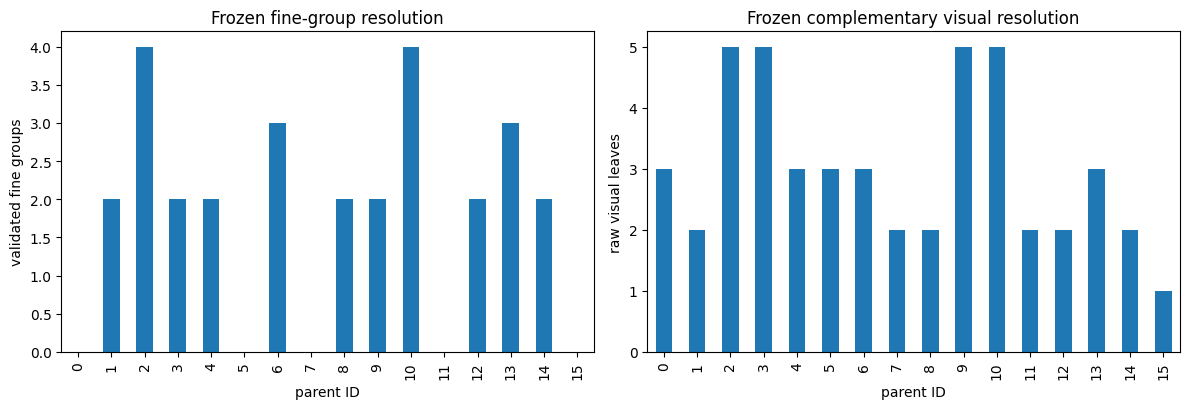

In [49]:
# 53. Unified final-evaluation dashboard and report summary.

root_background_row = BG_CONTROL[BG_CONTROL['level'] == 'root'].iloc[0]
minimum_parent_stress = (
    float(STRESS_SUM['parent_stability'].min())
    if len(STRESS_SUM)
    else np.nan
)
minimum_fine_stress = (
    float(STRESS_SUM['fine_stability'].dropna().min())
    if len(STRESS_SUM) and STRESS_SUM['fine_stability'].notna().any()
    else np.nan
)

FINAL_EVALUATION_SUMMARY = pd.DataFrame([{
    'selected_root': SELECTED_ROOT_ID,
    'broad_parents': int(len(np.unique(PARENT_LABELS))),
    'validated_fine_groups': int(FINE_GROUP_MAP['validated_fine_group_id'].nunique())
    if len(FINE_GROUP_MAP) else 0,
    'raw_visual_leaves': int(RAW_VISUAL_MAP_TABLE['raw_visual_leaf_id'].nunique()),
    'final_audit_root_group_ari': root_group_ari,
    'final_audit_root_routing_macro': final_root_routing['routing_macro'],
    'final_audit_root_routing_q10': final_root_routing['routing_q10'],
    'final_audit_root_precision_q10': final_root_routing['precision_q10'],
    'parent_near_duplicate_agreement': parent_near_dup['agreement'],
    'fine_near_duplicate_agreement': fine_near_dup['agreement'],
    'raw_visual_near_duplicate_agreement': raw_near_dup['agreement'],
    'background_root_ari': float(root_background_row['ari_to_target']),
    'patch_local_percentile_eta2_parent': float(PATCH_AUDIT.iloc[0]['eta2_parent_percentile']),
    'patch_local_percentile_eta2_fine': float(PATCH_AUDIT.iloc[0]['eta2_fine_percentile']),
    'patch_local_percentile_nuisance_r2': float(PATCH_AUDIT.iloc[0]['nuisance_r2_percentile']),
    'minimum_parent_stress_stability': minimum_parent_stress,
    'minimum_fine_stress_stability': minimum_fine_stress,
    'final_audit_seed': FINAL_AUDIT_SEED,
}])
FINAL_EVALUATION_SUMMARY.to_csv(
    OUT / 'metrics' / 'final_evaluation_summary.csv',
    index=False,
)
display(FINAL_EVALUATION_SUMMARY.T)

# Fine/raw resolution plots belong here because this is where the frozen structures are evaluated.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
if len(FINE_GROUP_MAP):
    fine_counts = FINE_GROUP_MAP.groupby('parent_id').size().reindex(
        sorted(np.unique(PARENT_LABELS)),
        fill_value=0,
    )
else:
    fine_counts = pd.Series(0, index=sorted(np.unique(PARENT_LABELS)))
fine_counts.plot(kind='bar', ax=axes[0])
axes[0].set_xlabel('parent ID')
axes[0].set_ylabel('validated fine groups')
axes[0].set_title('Frozen fine-group resolution')

RAW_VISUAL_MAP_TABLE.groupby('parent_id').size().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('parent ID')
axes[1].set_ylabel('raw visual leaves')
axes[1].set_title('Frozen complementary visual resolution')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'final_hierarchy_resolution.png', dpi=180)
plt.show()

## 11. Ablation metodologis

Struktur produksi telah dipilih dan diaudit sebelum bagian ini. Ablation berikut hanya menjelaskan keputusan metode dan tidak mengubah assignment yang telah dibekukan.

Tiga pertanyaan yang diuji:

1. Mengapa broad parent menggunakan K-means dibanding HDBSCAN, Leiden-CPM, atau baseline mutual-kNN connected components?
2. Mengapa child divalidasi satu per satu dan tidak langsung diterima dari partition yang stabil secara global?
3. Mengapa signed-residual FastICA dipertahankan dibanding NMF untuk atribut kontinu?


### 11A. Perbandingan metode broad clustering

Representasi broad yang sudah dipilih ditahan tetap. K-means dibandingkan dengan beberapa konfigurasi HDBSCAN, Leiden-CPM jika dependency tersedia, serta connected components dari mutual-kNN graph.

Alternatif dinilai berdasarkan kemampuannya membentuk broad taxonomy dengan coverage yang memadai. Silhouette yang tinggi tidak cukup jika metode menghasilkan banyak noise, cluster sangat kecil, atau fragmentasi berlebihan.


In [50]:
# 54. Compact root-algorithm ablation helpers. Explanatory only.
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


def build_mutual_knn_edges(features, k):
    """Build a self-tuned, mutual cosine-kNN graph as weighted undirected edges."""
    features = normalize_rows_l2(features)
    n_neighbors = min(int(k) + 1, len(features))
    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric='cosine',
        algorithm='brute',
    ).fit(features)
    distances, indices = nn.kneighbors(features)
    distances = distances[:, 1:]
    indices = indices[:, 1:]

    local_scale = np.maximum(distances[:, -1], 1e-6)
    directed = {}
    for i in range(len(features)):
        for j, distance in zip(indices[i], distances[i]):
            j = int(j)
            denominator = max(float(local_scale[i] * local_scale[j]), 1e-8)
            weight = float(np.exp(-(float(distance) ** 2) / denominator))
            directed[(i, j)] = weight

    mutual = {}
    for (i, j), weight in directed.items():
        reverse = directed.get((j, i))
        if reverse is None:
            continue
        a, b = (i, j) if i < j else (j, i)
        mutual[(a, b)] = max(mutual.get((a, b), 0.0), weight, reverse)
    return mutual


def fit_knn_components_baseline(features, k):
    """Use connected components of the mutual-kNN graph as a deliberately simple baseline."""
    edges = build_mutual_knn_edges(features, k)
    if not edges:
        return np.arange(len(features), dtype=np.int32)

    rows = []
    cols = []
    data = []
    for (i, j), weight in edges.items():
        rows.extend([i, j])
        cols.extend([j, i])
        data.extend([weight, weight])

    graph = csr_matrix((data, (rows, cols)), shape=(len(features), len(features)))
    _, labels = connected_components(graph, directed=False, return_labels=True)
    return relabel_by_size(labels.astype(np.int32))


def fit_hdbscan_baseline(features, min_cluster_size, min_samples):
    """Fit HDBSCAN on normalized vectors. Returns -1 for noise, matching the usual convention."""
    normalized = normalize_rows_l2(features)
    try:
        from sklearn.cluster import HDBSCAN as SklearnHDBSCAN
        model = SklearnHDBSCAN(
            min_cluster_size=int(min_cluster_size),
            min_samples=int(min_samples),
            metric='euclidean',
            cluster_selection_method='eom',
            copy=True,
        )
        return model.fit_predict(normalized).astype(np.int32)
    except ImportError:
        if importlib.util.find_spec('hdbscan') is None:
            raise RuntimeError('HDBSCAN is unavailable in both scikit-learn and the optional hdbscan package.')
        import hdbscan
        model = hdbscan.HDBSCAN(
            min_cluster_size=int(min_cluster_size),
            min_samples=int(min_samples),
            metric='euclidean',
            cluster_selection_method='eom',
        )
        return model.fit_predict(normalized).astype(np.int32)


def fit_leiden_baseline(features, graph_k, gamma, seed=SEED):
    """Fit genuine Leiden-CPM on the same self-tuned mutual-kNN graph used for this compact rationale ablation."""
    if not HAS_LEIDEN:
        raise RuntimeError('Leiden requires both python-igraph and leidenalg.')

    import igraph as ig
    import leidenalg

    edges = build_mutual_knn_edges(features, graph_k)
    edge_list = list(edges)
    graph = ig.Graph(n=len(features), edges=edge_list, directed=False)
    graph.es['weight'] = [float(edges[edge]) for edge in edge_list]
    partition = leidenalg.find_partition(
        graph,
        leidenalg.CPMVertexPartition,
        weights='weight',
        resolution_parameter=float(gamma),
        seed=int(seed),
        n_iterations=-1,
    )
    return relabel_by_size(np.asarray(partition.membership, dtype=np.int32))


def summarize_root_ablation_partition(method, setting, labels, features):
    """Summarize whether a rationale-only partition is structurally usable as a broad taxonomy."""
    labels = np.asarray(labels, dtype=np.int32)
    known = labels >= 0
    cluster_ids = [int(x) for x in np.unique(labels[known])]
    sizes = pd.Series(labels[known]).value_counts() if known.any() else pd.Series(dtype=int)
    coverage = float(known.mean())
    cluster_count = len(cluster_ids)
    min_cluster = int(sizes.min()) if len(sizes) else 0
    silhouette = cosine_silhouette_score(features, labels)

    lower_cluster_bound = max(2, min(PARENT_KS) - 6)
    upper_cluster_bound = max(PARENT_KS) + 5
    failures = []
    if not (lower_cluster_bound <= cluster_count <= upper_cluster_bound):
        failures.append(f'cluster_count={cluster_count} outside {lower_cluster_bound}–{upper_cluster_bound}')
    if coverage < ROOT_MIN_COVERAGE:
        failures.append(f'coverage={coverage:.3f} < {ROOT_MIN_COVERAGE:.2f}')
    if min_cluster < ROOT_MIN_SIZE:
        failures.append(f'min_cluster={min_cluster} < {ROOT_MIN_SIZE}')
    if not np.isfinite(silhouette) or silhouette < ROOT_MIN_SIL:
        failures.append(f'silhouette={silhouette:.3f} < {ROOT_MIN_SIL:.2f}' if np.isfinite(silhouette) else 'silhouette undefined')

    return {
        'method': method,
        'setting': setting,
        'clusters': int(cluster_count),
        'coverage': coverage,
        'noise_fraction': float(1.0 - coverage),
        'min_cluster': min_cluster,
        'median_cluster': float(sizes.median()) if len(sizes) else 0.0,
        'silhouette': float(silhouette) if np.isfinite(silhouette) else np.nan,
        'structural_pass': len(failures) == 0,
        'failure_reason': '; '.join(failures) if failures else 'passes compact structural gates',
    }

,method,setting,clusters,coverage,noise_fraction,min_cluster,median_cluster,silhouette,structural_pass,failure_reason,used_in_final_pipeline,verdict
0,K-means,G_foreground__K16,16,1.000000,0.000000,100,233.5,0.478345,True,passed hard structural/reliability gates and m...,True,✅ SUCCESS — RETAINED
1,HDBSCAN,"min_cluster_size=40, min_samples=10",15,0.660163,0.339837,43,160.0,0.681156,False,coverage=0.660 < 0.95,False,❌ FAILED BROAD-ROOT GATES
2,HDBSCAN,"min_cluster_size=60, min_samples=10",13,0.676246,0.323754,81,182.0,0.645058,False,coverage=0.676 < 0.95,False,❌ FAILED BROAD-ROOT GATES
3,HDBSCAN,"min_cluster_size=80, min_samples=10",13,0.676246,0.323754,81,182.0,0.645058,False,coverage=0.676 < 0.95,False,❌ FAILED BROAD-ROOT GATES
4,Leiden-CPM,"k=30, gamma=0.04",396,1.000000,0.000000,1,3.0,0.199172,False,cluster_count=396 outside 10–25; min_cluster=1...,False,❌ FAILED BROAD-ROOT GATES
5,Leiden-CPM,"k=30, gamma=0.08",497,1.000000,0.000000,1,3.0,0.188852,False,cluster_count=497 outside 10–25; min_cluster=1...,False,❌ FAILED BROAD-ROOT GATES
6,Leiden-CPM,"k=30, gamma=0.12",578,1.000000,0.000000,1,3.0,0.188342,False,cluster_count=578 outside 10–25; min_cluster=1...,False,❌ FAILED BROAD-ROOT GATES
7,mutual-kNN components,k=5,1116,1.000000,0.000000,1,1.0,-0.046221,False,cluster_count=1116 outside 10–25; min_cluster=...,False,❌ FAILED BROAD-ROOT GATES
8,mutual-kNN components,k=10,493,1.000000,0.000000,1,1.0,-0.400190,False,cluster_count=493 outside 10–25; min_cluster=1...,False,❌ FAILED BROAD-ROOT GATES
9,mutual-kNN components,k=20,206,1.000000,0.000000,1,1.0,-0.517099,False,cluster_count=206 outside 10–25; min_cluster=1...,False,❌ FAILED BROAD-ROOT GATES


,method,verdict,rationale
0,K-means,✅ SUCCESS — RETAINED,Retained broad clusterer: passed structural/re...
1,HDBSCAN,❌ FAILED / NOT RETAINED,coverage=0.660 < 0.95
2,Leiden-CPM,❌ FAILED / NOT RETAINED,cluster_count=396 outside 10–25; min_cluster=1...
3,mutual-kNN components,❌ FAILED / NOT RETAINED,cluster_count=1116 outside 10–25; min_cluster=...


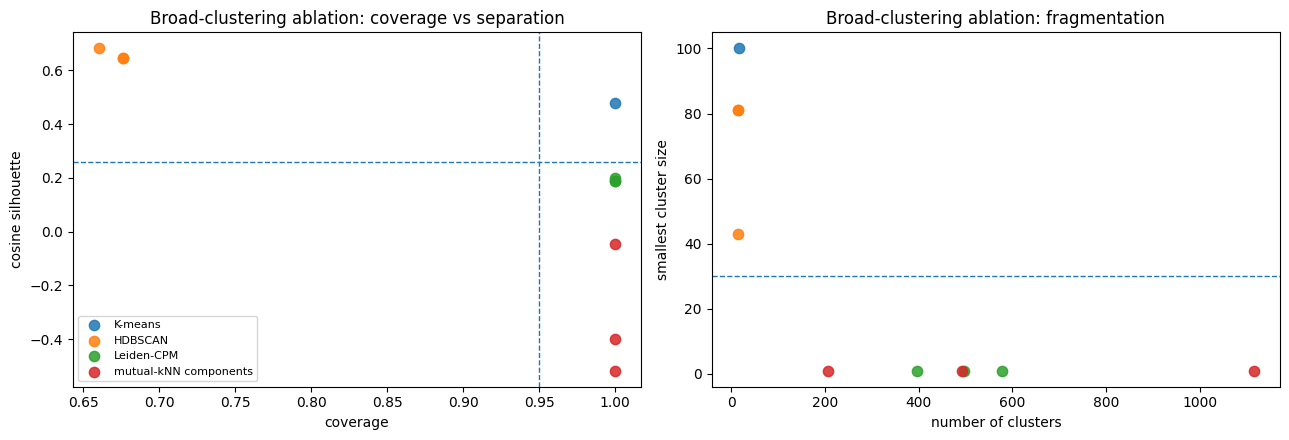

In [51]:
# 55. Run the compact broad-clustering ablation and clearly mark retained/failed methods.
ROOT_ALGORITHM_ABLATION_ROWS = []

# The selected K-means result is the positive control and is the only method here that underwent full routing/stability validation.
selected_root_row = ROOT_METRICS.loc[ROOT_METRICS['id'] == SELECTED_ROOT_ID].iloc[0]
ROOT_ALGORITHM_ABLATION_ROWS.append({
    'method': 'K-means',
    'setting': SELECTED_ROOT_ID,
    'clusters': int(selected_root_row['clusters']),
    'coverage': float(selected_root_row['coverage']),
    'noise_fraction': 0.0,
    'min_cluster': int(selected_root_row['min_cluster']),
    'median_cluster': float(selected_root_row['median_cluster']),
    'silhouette': float(selected_root_row['silhouette']),
    'structural_pass': True,
    'failure_reason': 'passed hard structural/reliability gates and minimized nuisance inside the final reliability frontier',
})

if RUN_RATIONALE_ABLATIONS:
    for min_cluster_size, min_samples in ROOT_ABLATION_HDBSCAN_SETTINGS:
        labels = fit_hdbscan_baseline(
            SELECTED_ROOT_FEATURES,
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
        )
        ROOT_ALGORITHM_ABLATION_ROWS.append(
            summarize_root_ablation_partition(
                'HDBSCAN',
                f'min_cluster_size={min_cluster_size}, min_samples={min_samples}',
                labels,
                SELECTED_ROOT_FEATURES,
            )
        )

    if HAS_LEIDEN:
        for gamma in ROOT_ABLATION_LEIDEN_GAMMAS:
            labels = fit_leiden_baseline(
                SELECTED_ROOT_FEATURES,
                graph_k=ROOT_ABLATION_LEIDEN_GRAPH_K,
                gamma=gamma,
            )
            ROOT_ALGORITHM_ABLATION_ROWS.append(
                summarize_root_ablation_partition(
                    'Leiden-CPM',
                    f'k={ROOT_ABLATION_LEIDEN_GRAPH_K}, gamma={gamma:g}',
                    labels,
                    SELECTED_ROOT_FEATURES,
                )
            )
    else:
        ROOT_ALGORITHM_ABLATION_ROWS.append({
            'method': 'Leiden-CPM',
            'setting': 'optional dependency unavailable',
            'clusters': np.nan,
            'coverage': np.nan,
            'noise_fraction': np.nan,
            'min_cluster': np.nan,
            'median_cluster': np.nan,
            'silhouette': np.nan,
            'structural_pass': False,
            'failure_reason': 'SKIPPED: install python-igraph + leidenalg to reproduce this explanatory ablation',
        })

    for graph_k in ROOT_ABLATION_KNN_KS:
        labels = fit_knn_components_baseline(SELECTED_ROOT_FEATURES, graph_k)
        ROOT_ALGORITHM_ABLATION_ROWS.append(
            summarize_root_ablation_partition(
                'mutual-kNN components',
                f'k={graph_k}',
                labels,
                SELECTED_ROOT_FEATURES,
            )
        )

ROOT_ALGORITHM_ABLATION = pd.DataFrame(ROOT_ALGORITHM_ABLATION_ROWS)
ROOT_ALGORITHM_ABLATION['used_in_final_pipeline'] = ROOT_ALGORITHM_ABLATION['method'].eq('K-means')
ROOT_ALGORITHM_ABLATION['verdict'] = np.where(
    ROOT_ALGORITHM_ABLATION['used_in_final_pipeline'],
    '✅ SUCCESS — RETAINED',
    np.where(
        ROOT_ALGORITHM_ABLATION['failure_reason'].str.startswith('SKIPPED'),
        '⚠️ SKIPPED',
        np.where(
            ROOT_ALGORITHM_ABLATION['structural_pass'],
            '⚠️ VIABLE STRUCTURE — NOT RETAINED',
            '❌ FAILED BROAD-ROOT GATES',
        ),
    ),
)
ROOT_ALGORITHM_ABLATION.to_csv(
    OUT / 'metrics' / 'root_algorithm_ablation.csv',
    index=False,
)
display(ROOT_ALGORITHM_ABLATION)

method_rows = []
for method, group in ROOT_ALGORITHM_ABLATION.groupby('method', sort=False):
    if method == 'K-means':
        verdict = '✅ SUCCESS — RETAINED'
        reason = 'Retained broad clusterer: passed structural/reliability gates, then won the nuisance-focused selection rule.'
    elif group['failure_reason'].str.startswith('SKIPPED').all():
        verdict = '⚠️ SKIPPED'
        reason = group.iloc[0]['failure_reason']
    elif group['structural_pass'].any():
        verdict = '⚠️ NOT RETAINED'
        reason = 'At least one compact setting was structurally viable, but it was not part of the validated production selection.'
    else:
        verdict = '❌ FAILED / NOT RETAINED'
        reasons = [str(x) for x in group['failure_reason'] if str(x)]
        reason = reasons[0] if reasons else 'No tested setting passed the broad structural gates.'
    method_rows.append({'method': method, 'verdict': verdict, 'rationale': reason})
ROOT_ALGORITHM_DECISIONS = pd.DataFrame(method_rows)
ROOT_ALGORITHM_DECISIONS.to_csv(
    OUT / 'metrics' / 'root_algorithm_decisions.csv',
    index=False,
)
display(ROOT_ALGORITHM_DECISIONS)

plot_data = ROOT_ALGORITHM_ABLATION[
    np.isfinite(ROOT_ALGORITHM_ABLATION['coverage'])
].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method, group in plot_data.groupby('method', sort=False):
    axes[0].scatter(
        group['coverage'],
        group['silhouette'],
        s=55,
        label=method,
        alpha=0.85,
    )
axes[0].axvline(ROOT_MIN_COVERAGE, linestyle='--', linewidth=1)
axes[0].axhline(ROOT_MIN_SIL, linestyle='--', linewidth=1)
axes[0].set_xlabel('coverage')
axes[0].set_ylabel('cosine silhouette')
axes[0].set_title('Broad-clustering ablation: coverage vs separation')
axes[0].legend(fontsize=8)

for method, group in plot_data.groupby('method', sort=False):
    axes[1].scatter(
        group['clusters'],
        group['min_cluster'],
        s=55,
        label=method,
        alpha=0.85,
    )
axes[1].axhline(ROOT_MIN_SIZE, linestyle='--', linewidth=1)
axes[1].set_xlabel('number of clusters')
axes[1].set_ylabel('smallest cluster size')
axes[1].set_title('Broad-clustering ablation: fragmentation')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'root_algorithm_ablation.png', dpi=180)
plt.show()

### 11B. Alasan child-specific validation

Stability pada tingkat parent dapat menyembunyikan child yang lemah. Ablation ini membandingkan kebijakan hipotetis *menerima semua child dari partition yang stabil* dengan kebijakan yang dipakai: survival + withholding + cross-view validation untuk setiap child.


,parent,provisional_children_blind_acceptance,children_passing_individual_gates,children_exposed_in_final_pipeline,rejected_children,fine_layer_suppressed_by_two_child_rule
0,0,0,0,0,0,False
1,1,2,2,2,0,False
2,2,5,4,4,1,False
3,3,2,2,2,0,False
4,4,2,2,2,0,False
5,5,2,1,0,1,True
6,6,3,3,3,0,False
7,7,2,1,0,1,True
8,8,2,2,2,0,False
9,9,4,2,2,2,False


,parent,local_child,n,survival_median,survival_q10,withholding_recall,cross_view_median,cross_view_q10,failure_reason
5,2,3,47,0.958687,0.736385,0.648148,0.937500,0.910577,withholding recall
12,5,1,64,1.000000,0.935106,0.788732,0.915483,0.887879,withholding recall
17,7,1,40,0.913889,0.848125,0.742857,0.929665,0.892910,withholding recall
22,9,2,45,1.000000,0.971465,0.689655,0.841195,0.706522,withholding recall
23,9,3,20,1.000000,1.000000,1.000000,1.000000,0.300000,cross-view corroboration
32,13,2,26,1.000000,0.941923,0.531250,0.945767,0.833744,withholding recall


,approach,verdict,children_or_groups,rationale
0,Blindly accept all children from a stable part...,❌ FAILED / NOT RETAINED,36,6 proposed children failed individual gates; 2...
1,Child-specific survival + withholding + cross-...,✅ SUCCESS — RETAINED,28,Only independently reproducible children are e...


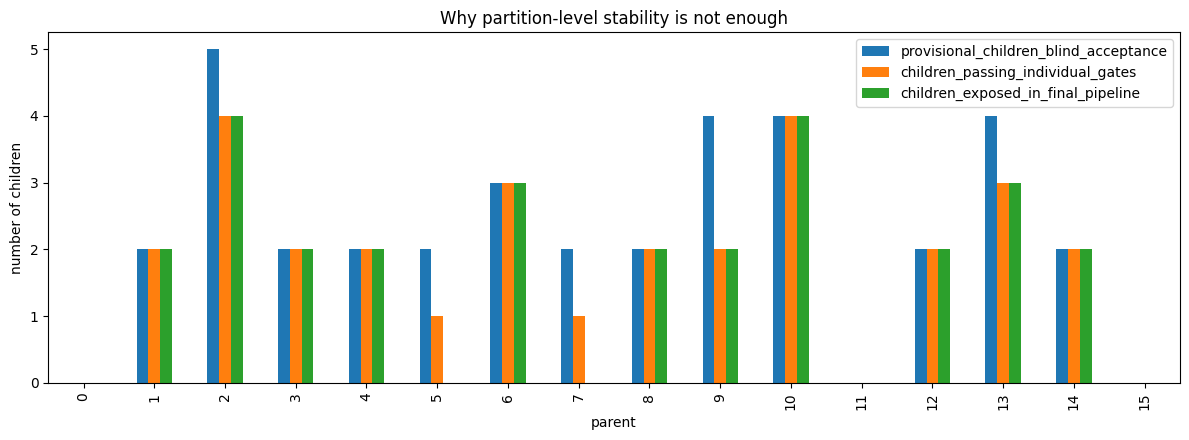

In [52]:
# 56. Child-validation ablation: provisional children versus independently validated children.
CHILD_ABLATION_ROWS = []
for parent_id in sorted(np.unique(PARENT_LABELS)):
    selection = FINE_SELECTION.get(int(parent_id))
    provisional_children = int(selection['obj']['k']) if selection is not None else 0

    parent_validation = FINE_VALIDATION[FINE_VALIDATION['parent'] == parent_id]
    independently_accepted = int(parent_validation['accepted'].sum()) if len(parent_validation) else 0
    deployed_children = int(
        FINE_GROUP_MAP.loc[
            FINE_GROUP_MAP['parent_id'] == parent_id,
            'validated_fine_group_id',
        ].nunique()
    ) if len(FINE_GROUP_MAP) else 0

    CHILD_ABLATION_ROWS.append({
        'parent': int(parent_id),
        'provisional_children_blind_acceptance': provisional_children,
        'children_passing_individual_gates': independently_accepted,
        'children_exposed_in_final_pipeline': deployed_children,
        'rejected_children': max(0, provisional_children - independently_accepted),
        'fine_layer_suppressed_by_two_child_rule': bool(
            provisional_children > 0
            and independently_accepted < 2
        ),
    })

CHILD_VALIDATION_ABLATION = pd.DataFrame(CHILD_ABLATION_ROWS)
CHILD_VALIDATION_ABLATION.to_csv(
    OUT / 'metrics' / 'child_validation_ablation.csv',
    index=False,
)
display(CHILD_VALIDATION_ABLATION)

rejected = FINE_VALIDATION[~FINE_VALIDATION['accepted']].copy()
if len(rejected):
    rejected['failed_survival'] = (
        (rejected['survival_median'] < CHILD_SURVIVAL_MED)
        | (rejected['survival_q10'] < CHILD_SURVIVAL_Q10)
    )
    rejected['failed_withholding'] = (
        rejected['withholding_recall'] < CHILD_WITHHOLD_RECALL
    )
    rejected['failed_cross_view'] = (
        (rejected['cross_view_comparators'] < MIN_CHILD_CORROBORATORS)
        | (rejected['cross_view_median'] < CHILD_VIEW_MED)
        | (rejected['cross_view_q10'] < CHILD_VIEW_Q10)
    )

    def child_failure_reason(row):
        reasons = []
        if row['failed_survival']:
            reasons.append('resampling survival')
        if row['failed_withholding']:
            reasons.append('withholding recall')
        if row['failed_cross_view']:
            reasons.append('cross-view corroboration')
        return ', '.join(reasons) if reasons else 'other gate'

    rejected['failure_reason'] = rejected.apply(child_failure_reason, axis=1)
else:
    rejected['failure_reason'] = pd.Series(dtype=object)

rejected.to_csv(
    OUT / 'metrics' / 'rejected_child_diagnostics.csv',
    index=False,
)
if len(rejected):
    display(
        rejected[
            [
                'parent',
                'local_child',
                'n',
                'survival_median',
                'survival_q10',
                'withholding_recall',
                'cross_view_median',
                'cross_view_q10',
                'failure_reason',
            ]
        ]
    )

provisional_total = int(
    CHILD_VALIDATION_ABLATION['provisional_children_blind_acceptance'].sum()
)
accepted_total = int(
    CHILD_VALIDATION_ABLATION['children_passing_individual_gates'].sum()
)
deployed_total = int(
    CHILD_VALIDATION_ABLATION['children_exposed_in_final_pipeline'].sum()
)
suppressed_parents = int(
    CHILD_VALIDATION_ABLATION['fine_layer_suppressed_by_two_child_rule'].sum()
)

CHILD_VALIDATION_DECISIONS = pd.DataFrame([
    {
        'approach': 'Blindly accept all children from a stable partition',
        'verdict': (
            '❌ FAILED / NOT RETAINED'
            if accepted_total < provisional_total or suppressed_parents > 0
            else '⚠️ No child-level failure observed in this run'
        ),
        'children_or_groups': provisional_total,
        'rationale': f'{provisional_total - accepted_total} proposed children failed individual gates; {suppressed_parents} parent fine layers were suppressed by the two-child rule.',
    },
    {
        'approach': 'Child-specific survival + withholding + cross-view validation',
        'verdict': '✅ SUCCESS — RETAINED',
        'children_or_groups': deployed_total,
        'rationale': 'Only independently reproducible children are exposed; unstable children fall back to parent-only assignment.',
    },
])
CHILD_VALIDATION_DECISIONS.to_csv(
    OUT / 'metrics' / 'child_validation_decisions.csv',
    index=False,
)
display(CHILD_VALIDATION_DECISIONS)

plot_table = CHILD_VALIDATION_ABLATION.set_index('parent')
plot_table[
    [
        'provisional_children_blind_acceptance',
        'children_passing_individual_gates',
        'children_exposed_in_final_pipeline',
    ]
].plot(kind='bar', figsize=(12, 4.5))
plt.ylabel('number of children')
plt.title('Why partition-level stability is not enough')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'child_validation_ablation.png', dpi=180)
plt.show()

### 11C. Perbandingan factorization atribut

FastICA dan NMF dibandingkan pada informasi identity-neighbour residual yang sama serta rank/neighbourhood scale yang sama. ICA menerima signed residual secara langsung; NMF menggunakan positive/negative non-negative split.

Perbandingan berfokus pada factor stability, jumlah kandidat interpretasi yang tidak redundant, fine-group leakage, dan nuisance leakage. Reconstruction loss tidak dibandingkan karena kedua metode mengoptimalkan objective pada ruang transformasi yang berbeda.


,method,rank,neighbor_k,seed_stability,stable_factors,candidate_factors,candidate_redundancy_groups,median_fine_eta2,median_nuisance_r2,used_in_final_pipeline,verdict
0,FastICA on signed residual,24,10,0.985882,16,16,16,0.096448,0.068828,True,✅ SUCCESS — RETAINED
1,NMF on positive/negative split residual,24,10,0.994742,23,18,18,0.213955,0.196152,False,❌ FAILED / NOT RETAINED


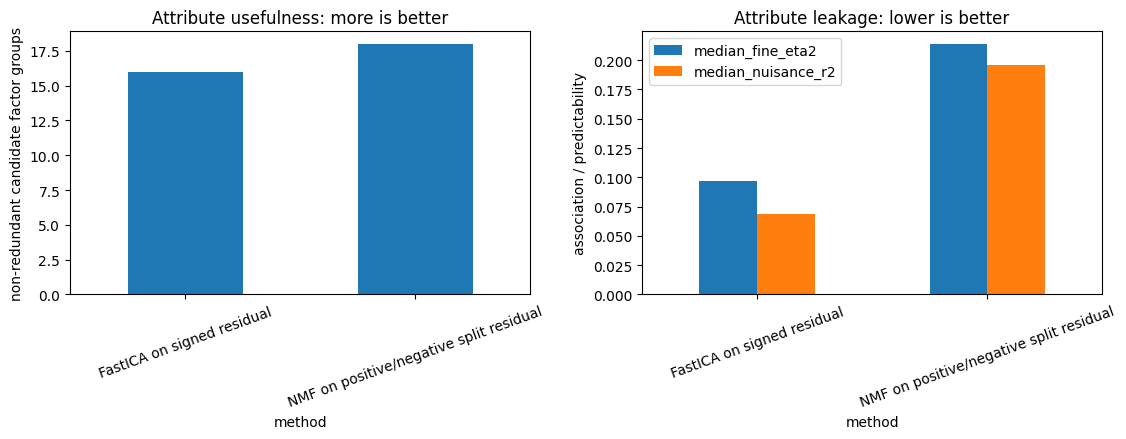

In [53]:
# 57. Matched NMF-versus-ICA attribute ablation. Explanatory only; final ICA outputs remain unchanged.

def split_signed_residual_for_nmf(residual):
    """Convert a signed residual into a non-negative positive/negative split for NMF."""
    residual = np.asarray(residual, dtype=np.float32)
    nonnegative = np.c_[
        np.maximum(residual, 0.0),
        np.maximum(-residual, 0.0),
    ]
    row_sum = np.maximum(nonnegative.sum(axis=1, keepdims=True), 1e-12)
    return nonnegative / row_sum


def match_nonnegative_components(reference, candidate):
    """Match NMF components across seeds with Hungarian cosine similarity."""
    similarity = normalize_rows_l2(reference) @ normalize_rows_l2(candidate).T
    row_ind, col_ind = linear_sum_assignment(-similarity)
    return row_ind, col_ind, similarity[row_ind, col_ind]


def count_nonredundant_factor_groups(scores, factor_ids, threshold=0.90):
    """Count connected redundancy groups among candidate factor-score vectors."""
    factor_ids = [int(x) for x in factor_ids]
    if len(factor_ids) <= 1:
        return len(factor_ids)

    corr = np.abs(np.corrcoef(scores[:, factor_ids], rowvar=False))
    parent = list(range(len(factor_ids)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        a = find(a)
        b = find(b)
        if a != b:
            parent[b] = a

    for i in range(len(factor_ids)):
        for j in range(i + 1, len(factor_ids)):
            if corr[i, j] >= threshold:
                union(i, j)
    return len({find(i) for i in range(len(factor_ids))})


ATTRIBUTE_METHOD_ABLATION_ROWS = []
NMF_FACTOR_METRICS = pd.DataFrame()

ica_stable = GLOBAL_FACTOR_METRICS[GLOBAL_FACTOR_METRICS['stable']].copy()
ica_candidates = GLOBAL_FACTOR_METRICS[
    GLOBAL_FACTOR_METRICS['candidate_for_interpretation']
].copy()
selected_ica_config = GLOBAL_CONFIG_SUM[
    GLOBAL_CONFIG_SUM['neighbor_k'] == GLOBAL_ICA_NEIGHBORS
].iloc[0]

ATTRIBUTE_METHOD_ABLATION_ROWS.append({
    'method': 'FastICA on signed residual',
    'rank': int(GLOBAL_ICA_RANK),
    'neighbor_k': int(GLOBAL_ICA_NEIGHBORS),
    'seed_stability': float(selected_ica_config['seed_stability']),
    'stable_factors': int(len(ica_stable)),
    'candidate_factors': int(len(ica_candidates)),
    'candidate_redundancy_groups': int(selected_ica_config['candidate_redundancy_groups']),
    'median_fine_eta2': float(ica_stable['eta2_validated_fine'].median()) if len(ica_stable) else np.nan,
    'median_nuisance_r2': float(ica_stable['nuisance_r2'].median()) if len(ica_stable) else np.nan,
    'used_in_final_pipeline': True,
})

if RUN_ATTRIBUTE_NMF_ABLATION:
    residual = identity_neighbor_residual(
        DINO_CONCEPT_SOFT,
        GLOBAL_ICA_NEIGHBORS,
    )
    nmf_input = split_signed_residual_for_nmf(residual)

    nmf_runs = []
    for seed in ICA_SEEDS:
        model = NMF(
            n_components=int(GLOBAL_ICA_RANK),
            init='nndsvdar',
            solver='mu',
            beta_loss='kullback-leibler',
            max_iter=ATTRIBUTE_NMF_MAX_ITER,
            random_state=int(seed),
        )
        scores = model.fit_transform(nmf_input).astype(np.float32)
        components = model.components_.astype(np.float32)
        nmf_runs.append((int(seed), model, scores, components))

    run_stability = []
    for i, run_a in enumerate(nmf_runs):
        pair_scores = []
        for j, run_b in enumerate(nmf_runs):
            if i == j:
                continue
            _, _, similarities = match_nonnegative_components(
                run_a[3],
                run_b[3],
            )
            pair_scores.append(float(np.median(similarities)))
        run_stability.append(float(np.mean(pair_scores)))

    medoid_index = int(np.argmax(run_stability))
    nmf_seed, nmf_model, nmf_scores, nmf_components = nmf_runs[medoid_index]

    factor_stability = {factor: [] for factor in range(GLOBAL_ICA_RANK)}
    for j, run in enumerate(nmf_runs):
        if j == medoid_index:
            continue
        ref_idx, other_idx, similarities = match_nonnegative_components(
            nmf_components,
            run[3],
        )
        for factor, similarity in zip(ref_idx, similarities):
            factor_stability[int(factor)].append(float(similarity))

    factor_rows = []
    for factor in range(GLOBAL_ICA_RANK):
        values = factor_stability[factor]
        stability_median = float(np.median(values)) if values else 0.0
        stability_q10 = float(np.quantile(values, 0.1)) if values else 0.0
        score = nmf_scores[:, factor]
        top_indices = np.argsort(score)[::-1][:max(20, int(0.10 * N_CANONICAL))]
        parent_fraction = pd.Series(PARENT_LABELS[top_indices]).value_counts(normalize=True)
        top_parent_fraction = float(parent_fraction.iloc[0]) if len(parent_fraction) else 1.0
        stable = bool(
            stability_median >= FACTOR_STABLE_MEDIAN
            and stability_q10 >= FACTOR_STABLE_Q10
        )
        fine_eta2 = categorical_eta_squared(score, FINE_GROUP_LABELS)
        nuisance_r2 = nuisance_cross_validated_r2(score)
        candidate = bool(
            stable
            and fine_eta2 < FACTOR_IDENTITY_ETA2_WARN
            and nuisance_r2 < FACTOR_NUISANCE_R2_WARN
            and top_parent_fraction < FACTOR_TOP_PARENT_MAX
        )
        factor_rows.append({
            'factor': int(factor),
            'stability_median': stability_median,
            'stability_q10': stability_q10,
            'stable': stable,
            'eta2_validated_fine': float(fine_eta2),
            'nuisance_r2': float(nuisance_r2),
            'top_parent_fraction': top_parent_fraction,
            'candidate_for_interpretation': candidate,
        })

    NMF_FACTOR_METRICS = pd.DataFrame(factor_rows)
    nmf_stable = NMF_FACTOR_METRICS[NMF_FACTOR_METRICS['stable']]
    nmf_candidates = NMF_FACTOR_METRICS[
        NMF_FACTOR_METRICS['candidate_for_interpretation']
    ]
    nmf_redundancy_groups = count_nonredundant_factor_groups(
        nmf_scores,
        nmf_candidates['factor'].astype(int).tolist(),
    )

    ATTRIBUTE_METHOD_ABLATION_ROWS.append({
        'method': 'NMF on positive/negative split residual',
        'rank': int(GLOBAL_ICA_RANK),
        'neighbor_k': int(GLOBAL_ICA_NEIGHBORS),
        'seed_stability': float(np.median(run_stability)),
        'stable_factors': int(len(nmf_stable)),
        'candidate_factors': int(len(nmf_candidates)),
        'candidate_redundancy_groups': int(nmf_redundancy_groups),
        'median_fine_eta2': float(nmf_stable['eta2_validated_fine'].median()) if len(nmf_stable) else np.nan,
        'median_nuisance_r2': float(nmf_stable['nuisance_r2'].median()) if len(nmf_stable) else np.nan,
        'used_in_final_pipeline': False,
    })
    NMF_FACTOR_METRICS.to_csv(
        OUT / 'metrics' / 'attribute_nmf_factor_metrics.csv',
        index=False,
    )

ATTRIBUTE_METHOD_ABLATION = pd.DataFrame(ATTRIBUTE_METHOD_ABLATION_ROWS)

if len(ATTRIBUTE_METHOD_ABLATION) > 1:
    ica_row = ATTRIBUTE_METHOD_ABLATION.iloc[0]
    nmf_row = ATTRIBUTE_METHOD_ABLATION.iloc[1]
    nmf_competitive = bool(
        nmf_row['candidate_redundancy_groups'] >= ica_row['candidate_redundancy_groups']
        and nmf_row['median_fine_eta2'] <= ica_row['median_fine_eta2']
        and nmf_row['median_nuisance_r2'] <= ica_row['median_nuisance_r2']
    )
    ATTRIBUTE_METHOD_ABLATION.loc[0, 'verdict'] = '✅ SUCCESS — RETAINED'
    ATTRIBUTE_METHOD_ABLATION.loc[1, 'verdict'] = (
        '⚠️ MIXED — REVIEW'
        if nmf_competitive
        else '❌ FAILED / NOT RETAINED'
    )
else:
    ATTRIBUTE_METHOD_ABLATION.loc[0, 'verdict'] = '✅ SUCCESS — RETAINED'

ATTRIBUTE_METHOD_ABLATION.to_csv(
    OUT / 'metrics' / 'attribute_method_ablation.csv',
    index=False,
)
display(ATTRIBUTE_METHOD_ABLATION)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ATTRIBUTE_METHOD_ABLATION.set_index('method')['candidate_redundancy_groups'].plot(
    kind='bar',
    ax=axes[0],
)
axes[0].set_ylabel('non-redundant candidate factor groups')
axes[0].set_title('Attribute usefulness: more is better')
axes[0].tick_params(axis='x', rotation=20)

ATTRIBUTE_METHOD_ABLATION.set_index('method')[
    ['median_fine_eta2', 'median_nuisance_r2']
].plot(kind='bar', ax=axes[1])
axes[1].set_ylabel('association / predictability')
axes[1].set_title('Attribute leakage: lower is better')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'attribute_method_ablation.png', dpi=180)
plt.show()

### 11D. Keputusan metode

Tabel berikut merangkum hasil ablation menjadi keputusan **retained / not retained / skipped**. Tabel ini menjelaskan metode yang digunakan dan tidak menghitung ulang discovery.


In [54]:
# 58. One compact decision table for the report and handoff.
EXPERIMENT_DECISION_ROWS = []

for _, row in ROOT_ALGORITHM_DECISIONS.iterrows():
    EXPERIMENT_DECISION_ROWS.append({
        'question': 'How should broad parents be clustered?',
        'method': row['method'],
        'verdict': row['verdict'],
        'rationale': row['rationale'],
    })

for _, row in CHILD_VALIDATION_DECISIONS.iterrows():
    EXPERIMENT_DECISION_ROWS.append({
        'question': 'How should parent children be trusted?',
        'method': row['approach'],
        'verdict': row['verdict'],
        'rationale': row['rationale'],
    })

for _, row in ATTRIBUTE_METHOD_ABLATION.iterrows():
    EXPERIMENT_DECISION_ROWS.append({
        'question': 'How should continuous attributes be factorized?',
        'method': row['method'],
        'verdict': row['verdict'],
        'rationale': (
            f"candidate groups={int(row['candidate_redundancy_groups'])}, "
            f"median fine eta²={row['median_fine_eta2']:.3f}, "
            f"median nuisance R²={row['median_nuisance_r2']:.3f}"
        ),
    })

EXPERIMENT_DECISIONS = pd.DataFrame(EXPERIMENT_DECISION_ROWS)
EXPERIMENT_DECISIONS.to_csv(
    OUT / 'metrics' / 'experiment_decision_summary.csv',
    index=False,
)
display(EXPERIMENT_DECISIONS)

,question,method,verdict,rationale
0,How should broad parents be clustered?,K-means,✅ SUCCESS — RETAINED,Retained broad clusterer: passed structural/re...
1,How should broad parents be clustered?,HDBSCAN,❌ FAILED / NOT RETAINED,coverage=0.660 < 0.95
2,How should broad parents be clustered?,Leiden-CPM,❌ FAILED / NOT RETAINED,cluster_count=396 outside 10–25; min_cluster=1...
3,How should broad parents be clustered?,mutual-kNN components,❌ FAILED / NOT RETAINED,cluster_count=1116 outside 10–25; min_cluster=...
4,How should parent children be trusted?,Blindly accept all children from a stable part...,❌ FAILED / NOT RETAINED,6 proposed children failed individual gates; 2...
5,How should parent children be trusted?,Child-specific survival + withholding + cross-...,✅ SUCCESS — RETAINED,Only independently reproducible children are e...
6,How should continuous attributes be factorized?,FastICA on signed residual,✅ SUCCESS — RETAINED,"candidate groups=16, median fine eta²=0.096, m..."
7,How should continuous attributes be factorized?,NMF on positive/negative split residual,❌ FAILED / NOT RETAINED,"candidate groups=18, median fine eta²=0.214, m..."


## 12. Montage untuk interpretasi

Montage mencakup contoh pusat, deterministic-random members, boundary cases, outliers, dan nearest siblings. Lembar atribut membandingkan sisi high dan low dengan identity matching.

Semua artefak visual dibuat setelah assignment numerik ditetapkan. Fungsinya adalah menyediakan bukti untuk semantic mapping pada Notebook 2, bukan mengubah membership.


In [55]:
# 59. Review-sheet helpers designed for post-freeze interpretation.

def thumbnail_letterbox(im, size=132):
    """Create a fixed-size white-backed thumbnail for review sheets."""
    x = im.copy()
    x.thumbnail((size, size), Image.Resampling.LANCZOS)
    c = Image.new('RGB', (size, size), 'white')
    c.paste(x, ((size - x.width) // 2, (size - x.height) // 2))
    return c

def select_cluster_review_roles(ids,
    X,
    partition_labels=None,
    cluster_label=None,
    eligible_ids=None,
    n_each=4):
    """Representative roles without cherry-picking.

    Boundary points are defined by the smallest centroid margin against the nearest sibling
    whenever a sibling partition is available. Otherwise low own-centroid similarity is used.
    """
    ids = np.asarray(ids, int)
    Z = normalize_rows_l2(np.asarray(X)[ids])
    cent = normalize_rows_l2(Z.mean(0, keepdims=True))[0]
    own = Z @ cent
    core = ids[np.argsort(own)[::-1][:min(n_each, len(ids))]]
    out = ids[np.argsort(own)[:min(n_each, len(ids))]]
    used = set(np.r_[core, out].tolist())
    pool = np.array([i for i in ids if i not in used], int)
    rng = np.random.default_rng(SEED + int(ids[0]))
    rnd = rng.choice(pool, min(n_each, len(pool)), replace=False) if len(pool) else np.array([], int)
    nearest_sibling = np.array([], int)
    sibling_label = None
    remaining = np.array([i for i in ids if i not in set(np.r_[core, out, rnd].tolist())], int)
    if partition_labels is not None and cluster_label is not None:
        lab = np.asarray(partition_labels)
        elig = np.arange(len(lab)) if eligible_ids is None else np.asarray(eligible_ids, int)
        sibs = [int(s) for s in np.unique(lab[elig]) if int(s) >= 0 and int(s) != int(cluster_label)]
        if sibs:
            cents = {s: normalize_rows_l2(np.asarray(X)[elig[lab[elig] == s]].mean(0,
                keepdims=True))[0] for s in sibs}
            sibling_label = max(sibs, key=lambda s: float(cent @ cents[s]))
            sid = elig[lab[elig] == sibling_label]
            SZ = normalize_rows_l2(np.asarray(X)[sid])
            ss = SZ @ cents[sibling_label]
            nearest_sibling = sid[np.argsort(ss)[::-1][:min(n_each, len(sid))]]
            if len(remaining):
                R = normalize_rows_l2(np.asarray(X)[remaining])
                other = np.max(np.stack([R @ cents[s] for s in sibs], axis=1), axis=1)
                margin = R @ cent - other
                boundary = remaining[np.argsort(margin)[:min(n_each, len(remaining))]]
            else:
                boundary = np.array([], int)
        else:
            boundary = remaining[np.argsort(normalize_rows_l2(np.asarray(X)[remaining]) @ cent)[:min(n_each, len(remaining))]] if len(remaining) else np.array([],
                int)
    else:
        boundary = remaining[np.argsort(normalize_rows_l2(np.asarray(X)[remaining]) @ cent)[:min(n_each, len(remaining))]] if len(remaining) else np.array([],
            int)
    roles = {'core': core, 'random': rnd, 'boundary': boundary, 'outliers': out}
    if sibling_label is not None and len(nearest_sibling):
        roles[f'nearest_sibling_{sibling_label}'] = nearest_sibling
    return roles

def save_review_sheet(title, groups, path, tile=132, cols=8):
    """Render and save one post-freeze interpretation montage."""
    blocks = []
    for label, ids in groups:
        ids = list(map(int, ids))
        if len(ids) == 0:
            continue
        rows = max(1, math.ceil(len(ids) / cols))
        can = Image.new('RGB', (cols * tile, rows * (tile + 17) + 25), 'white')
        dr = ImageDraw.Draw(can)
        dr.text((4, 4), str(label), fill='black')
        for j, i in enumerate(ids):
            try:
                can.paste(thumbnail_letterbox(load_rgb_image(CANONICAL_NODES.iloc[i].image_path), tile),
                    (j % cols * tile, j // cols * (tile + 17) + 25))
                dr.text((j % cols * tile + 2, j // cols * (tile + 17) + 25 + tile), str(i), fill='black')
            except Exception:
                pass
        blocks.append(can)
    if not blocks:
        return
    out = Image.new('RGB', (max((x.width for x in blocks)), sum((x.height for x in blocks)) + 24), 'white')
    dr = ImageDraw.Draw(out)
    dr.text((4, 4), title, fill='black')
    yy = 24
    for b in blocks:
        out.paste(b, (0, yy))
        yy += b.height
    out.save(path, quality=91)


In [56]:
# 60. Parent and validated fine-group review sheets.

for g in sorted(np.unique(PARENT_LABELS)):
    ids = np.flatnonzero(PARENT_LABELS == g)
    r = select_cluster_review_roles(ids, SELECTED_ROOT_FEATURES, PARENT_LABELS, g, np.arange(N_CANONICAL))
    save_review_sheet(f'Parent {g} | n={len(ids)} | reliability={PARENT_RELIABILITY_BY_ID[g]:.3f}',
        list(r.items()),
        OUT / 'review/parents' / f'parent_{g:02d}.jpg')
for _, m in FINE_GROUP_MAP.iterrows():
    fid = int(m['validated_fine_group_id'])
    g = int(m['parent_id'])
    ids = np.flatnonzero(FINE_GROUP_LABELS == fid)
    X = FINE_VIEWS[str(m['view'])]
    eligible = np.flatnonzero(PARENT_LABELS == g)
    r = select_cluster_review_roles(ids, X, FINE_GROUP_LABELS, fid, eligible)
    save_review_sheet(f"Fine group {fid} | parent={g} | local_child={int(m['local_child_id'])} | n={len(ids)}",
        list(r.items()),
        OUT / 'review/fine' / f'fine_{fid:03d}.jpg')
for g in sorted(np.unique(PARENT_LABELS)):
    rows = []
    if len(FINE_GROUP_MAP):
        for fid in sorted(FINE_GROUP_MAP.loc[FINE_GROUP_MAP.parent_id == g,
            'validated_fine_group_id'].astype(int)):
            ids = np.flatnonzero(FINE_GROUP_LABELS == fid)
            view = str(FINE_GROUP_MAP.loc[FINE_GROUP_MAP.validated_fine_group_id == fid, 'view'].iloc[0])
            rows.append((f'fine {fid} n={len(ids)}',
                select_cluster_review_roles(ids, FINE_VIEWS[view], FINE_GROUP_LABELS, fid, np.flatnonzero(PARENT_LABELS == g))['core']))
    if rows:
        save_review_sheet(f'Parent {g}: validated fine-group comparison',
            rows,
            OUT / 'review/fine' / f'parent_{g:02d}_fine_comparison.jpg',
            tile=145,
            cols=6)


In [57]:
# 61. Complementary raw-visual review sheets.

for g in sorted(np.unique(PARENT_LABELS)):
    rows = []
    eligible = np.flatnonzero(PARENT_LABELS == g)
    for vid in sorted(RAW_VISUAL_MAP_TABLE.loc[RAW_VISUAL_MAP_TABLE.parent_id == g,
        'raw_visual_leaf_id'].astype(int)):
        ids = np.flatnonzero(RAW_VISUAL_LABELS == vid)
        view = str(RAW_VISUAL_MAP_TABLE.loc[RAW_VISUAL_MAP_TABLE.raw_visual_leaf_id == vid, 'view'].iloc[0])
        X = SELECTED_ROOT_FEATURES if view == 'parent_only' else RAW_VISUAL_VIEWS[view]
        r = select_cluster_review_roles(ids, X, RAW_VISUAL_LABELS, vid, eligible)
        save_review_sheet(f'Raw visual leaf {vid} | parent={g} | n={len(ids)}',
            list(r.items()),
            OUT / 'review/raw_visual' / f'visual_{vid:03d}.jpg')
        rows.append((f'leaf {vid} n={len(ids)}', r['core']))
    if rows:
        save_review_sheet(f'Parent {g}: raw visual leaf comparison',
            rows,
            OUT / 'review/raw_visual' / f'parent_{g:02d}_visual_comparison.jpg',
            tile=145,
            cols=6)


In [58]:
# 62. Near-duplicate pair montage for audit.

edges = pd.read_csv(OUT / 'validation' / 'validation_near_duplicate_edges.csv')
pairs = []
for j, r in edges.head(40).iterrows():
    pairs.extend([int(r['canonical_a']), int(r['canonical_b'])])
if pairs:
    save_review_sheet('Primary near-duplicate validation pairs (paired left→right in row order)',
        [('pairs', pairs)],
        OUT / 'review/near_duplicates' / 'primary_pairs_sample.jpg',
        tile=120,
        cols=8)


In [59]:
# 63. Identity-matched high-vs-low controls for ICA factors.

def matched_low(score, high, n=10):
    low = []
    used = set(map(int, high))
    q = float(np.quantile(score, 0.35))
    for h in high:
        ns = [int(x) for x in G_NEIGH[int(h)] if x >= 0 and int(x) not in used and (PARENT_LABELS[int(x)] == PARENT_LABELS[int(h)]) and (score[int(x)] <= q)]
        if ns:
            low.append(ns[0])
            used.add(ns[0])
        if len(low) >= n:
            break
    return low
for _, r in GLOBAL_FACTOR_METRICS[GLOBAL_FACTOR_METRICS.candidate_for_interpretation].iterrows():
    f = int(r['factor'])
    sc = GLOBAL_ICA_SCORES[:, f]
    pool = np.argsort(sc)[::-1][:50]
    hi = np.random.default_rng(SEED + f).choice(pool, min(12, len(pool)), replace=False)
    lo = matched_low(sc, hi, 12)
    save_review_sheet(f"Global ICA factor {f} | stability={r['bootstrap_match_median']:.3f} | fine η²={r['eta2_validated_fine']:.3f} | nuisance R²={r['nuisance_r2']:.3f}",
        [('HIGH', hi), ('identity-matched LOW', lo)],
        OUT / 'review/global_attributes' / f'global_ica_f{f:02d}.jpg',
        tile=120,
        cols=12)
for _, r in (FAMILY_FACTOR_METRICS[FAMILY_FACTOR_METRICS.candidate_for_interpretation] if len(FAMILY_FACTOR_METRICS) else FAMILY_FACTOR_METRICS).iterrows():
    g = int(r['parent'])
    f = int(r['factor'])
    b = FAMILY_ICA_BY_PARENT[g]
    ids = b['ids']
    sc = b['W'][:, f]
    hi = ids[np.argsort(sc)[::-1][:10]]
    local = np.full(N_CANONICAL, np.nan)
    local[ids] = sc
    lo = []
    used = set(map(int, hi))
    q = float(np.quantile(sc, 0.35))
    for h in hi:
        ns = [int(x) for x in G_NEIGH[int(h)] if x >= 0 and PARENT_LABELS[int(x)] == g and (int(x) not in used) and (local[int(x)] <= q)]
        if ns:
            lo.append(ns[0])
            used.add(ns[0])
    save_review_sheet(f"Parent {g} family ICA factor {f} | stability={r['bootstrap_match_median']:.3f} | fine η²={r['eta2_validated_fine']:.3f}",
        [('HIGH', hi), ('matched LOW', lo)],
        OUT / 'review/family_attributes' / f'parent_{g:02d}_ica_f{f:02d}.jpg',
        tile=120,
        cols=10)


In [60]:
# 64. Local patch-atypicality high/middle/low sheets + heatmaps for high examples.

DM = PATCH_RESULTS[16]['map']
S = PATCH_RESULTS[16]['stats']
for g in sorted(np.unique(PARENT_LABELS)):
    ids = np.flatnonzero(PARENT_LABELS == g)
    sc = S[ids, -1]
    hi = ids[np.argsort(sc)[::-1][:6]]
    lo = ids[np.argsort(sc)[:6]]
    mid = ids[np.argsort(np.abs(sc - 0.5))[:6]]
    save_review_sheet(f'Parent {g}: local patch atypicality',
        [('HIGH percentile', hi), ('MIDDLE', mid), ('LOW percentile', lo)],
        OUT / 'review/patch_deviation' / f'parent_{g:02d}_high_mid_low.jpg',
        tile=125,
        cols=6)
    tw = 220
    can = Image.new('RGB', (tw * 3, tw * math.ceil(len(hi) / 3)), 'white')
    for j, i in enumerate(hi):
        cr = bbox_crop(load_rgb_image(CANONICAL_NODES.iloc[int(i)].image_path),
            FOREGROUND_BOXES[int(i)],
            FOREGROUND_MARGIN)
        hm = np.asarray(DM[int(i)], np.float32)
        a, b = np.quantile(hm, [0.05, 0.95])
        z = np.clip((hm - a) / max(b - a, 1e-06), 0, 1)
        mask = Image.fromarray((255 * z).astype(np.uint8)).resize(cr.size, Image.Resampling.BILINEAR)
        red = Image.new('RGB', cr.size, (255, 0, 0))
        overlay = Image.blend(cr, Image.composite(red, cr, mask), 0.42)
        overlay.thumbnail((tw, tw))
        can.paste(overlay, (j % 3 * tw, j // 3 * tw))
    can.save(OUT / 'review/patch_deviation' / f'parent_{g:02d}_high_heatmaps.jpg', quality=91)


## 13. Ekspor, numerical freeze, dan handoff

Struktur numerik telah dipilih, diaudit secara independen, dan dibandingkan dengan alternatif yang relevan. Bagian terakhir mengekspor fitted resources, schema interpretasi, tabel hasil, serta fingerprint konfigurasi ke handoff Discovery.


In [61]:
# 65. Inference-critical resource manifest. All resources originate from this run.

proto_src = OUT / 'cache' / 'patch_proto_g16.npy'
proto_dst = OUT / 'models' / 'reference_patch_prototypes_g16.npy'
shutil.copy2(proto_src, proto_dst)
resources = {'foreground_bbox': BBOX_PATH,
    'cradio_slot1_pca256': CR_PCA_PATH,
    'vlad_patch_pca64': VLAD_PATCH_PCA_PATH,
    'vlad32_centers': VLAD_CENTER_PATH,
    'vlad32_pca512_alpha05': VLAD_OUT_PATH,
    'concept_mid_pca64': MID_PCA_PATH,
    'concept_late_pca64': LATE_PCA_PATH,
    'concept512_centers': C512_PATH,
    'hist512_base': OUT / 'views' / 'HSOFT.npy',
    'hist512_hires_fg': p512,
    'reference_patch_prototypes_g16': proto_dst}
resource_rows = []
for name, p in resources.items():
    p = Path(p)
    if not p.is_file():
        raise FileNotFoundError(p)
    resource_rows.append({'resource': name,
        'path': str(p.relative_to(OUT)),
        'sha256': sha256_file(p),
        'bytes': p.stat().st_size})
RESOURCE_MANIFEST = pd.DataFrame(resource_rows)
RESOURCE_MANIFEST.to_csv(OUT / 'handoff' / 'inference_resource_manifest.csv', index=False)
display(RESOURCE_MANIFEST)
for p in sorted((OUT / 'models').glob('*')):
    if not p.is_file():
        continue
    name = 'model__' + p.name
    if name not in {r['resource'] for r in resource_rows}:
        resource_rows.append({'resource': name,
            'path': str(p.relative_to(OUT)),
            'sha256': sha256_file(p),
            'bytes': p.stat().st_size})
for name, p in [('G_whole', OUT / 'views' / 'G.npy'),
    ('L_whole', OUT / 'views' / 'L.npy'),
    ('G_foreground', OUT / 'views' / 'G_foreground.npy'),
    ('L_foreground', OUT / 'views' / 'L_foreground.npy'),
    ('identity_neighbors', OUT / 'attributes' / 'identity_neighbors.npy'),
    ('identity_neighbor_similarity', OUT / 'attributes' / 'identity_neighbor_similarity.npy')]:
    if Path(p).is_file():
        resource_rows.append({'resource': name,
            'path': str(Path(p).relative_to(OUT)),
            'sha256': sha256_file(p),
            'bytes': Path(p).stat().st_size})
RESOURCE_MANIFEST = pd.DataFrame(resource_rows).drop_duplicates('resource').sort_values('resource').reset_index(drop=True)
RESOURCE_MANIFEST.to_csv(OUT / 'handoff' / 'inference_resource_manifest.csv', index=False)
display(RESOURCE_MANIFEST)


,resource,path,sha256,bytes
0,foreground_bbox,cache/foreground_bbox.npy,6513cd92e763943904420ffc2ac7ecd8511432f11d3e30...,91160
1,cradio_slot1_pca256,models/cradio_slot1_pca256.npz,9b7f9e4e2e8e134358be18af2a0ca4ff2645743f648848...,1103768
2,vlad_patch_pca64,models/vlad_patch_pca64.npz,2b6b0c63b033f0cec667205fad26c2e9e14ce726c133c3...,248852
3,vlad32_centers,models/vlad32_centers.npy,593f99ea50758aba4b4a14b1d4889b6723f8b8c2355ba2...,8320
4,vlad32_pca512_alpha05,models/vlad32_pca512_alpha05.npz,ba67785679fc0b83586a88cf4144cdb96ddefe549a9479...,3905120
5,concept_mid_pca64,models/concept_mid_pca64.npz,7509f4c5c2e943469322ce45eadce3da7ff92a97d4cc7a...,250914
6,concept_late_pca64,models/concept_late_pca64.npz,a3186343b8e585d30c83e2b2e095c884f1ddaf225e63c5...,248864
7,concept512_centers,models/concept512_centers.npy,ba8512dde8cb9a95d17742c05ca77ae534acc3712e4bbb...,262272
8,hist512_base,views/HSOFT.npy,fce966fca747de2e4dce12d98c5f9e045d11519f96943a...,7768192
9,hist512_hires_fg,attributes/hist512_hires_fg.npy,8b0ef783c880717dbfa548f20218bd21dfe7aa7862545a...,7768192


,resource,path,sha256,bytes
0,G_foreground,views/G_foreground.npy,45f18251eaf125f79dff461dd2575d5ece1e31169352cd...,3884160
1,G_whole,views/G.npy,6e7d356cef260b5fd9602209fe8d12c4b60c5982d1a53b...,3884160
2,L_foreground,views/L_foreground.npy,1427cf4e588cea1b3464cb4b56588e7dbf810c405b7d7d...,7768192
3,L_whole,views/L.npy,a43e1bd12e386155ecfc1f8b56f7c5f53cb2dc89139994...,7768192
4,concept512_centers,models/concept512_centers.npy,ba8512dde8cb9a95d17742c05ca77ae534acc3712e4bbb...,262272
...,...,...,...,...
127,model__vlad_patch_pca64.npz,models/vlad_patch_pca64.npz,2b6b0c63b033f0cec667205fad26c2e9e14ce726c133c3...,248852
128,reference_patch_prototypes_g16,models/reference_patch_prototypes_g16.npy,3a35df51664182be3380febffdc0ae7cf6cb315227f09d...,31072384
129,vlad32_centers,models/vlad32_centers.npy,593f99ea50758aba4b4a14b1d4889b6723f8b8c2355ba2...,8320
130,vlad32_pca512_alpha05,models/vlad32_pca512_alpha05.npz,ba67785679fc0b83586a88cf4144cdb96ddefe549a9479...,3905120


In [62]:
# 66. Canonical and raw-image exports.

PER = CANONICAL_NODES[['canonical_index',
    'canonical_id',
    'image_path',
    'rel_path',
    'filename',
    'duplicate_count']].copy()
PER['validation_group_id'] = VALIDATION_GROUPS
PER['raw_parent_id'] = PARENT_LABELS
PER['parent_operational_reliability'] = [PARENT_RELIABILITY_BY_ID[int(g)] for g in PARENT_LABELS]
PER['parent_confidence_score'] = PARENT_CONFIDENCE_SCORES
PER['raw_local_child_id'] = RAW_LOCAL_CHILD
PER['validated_fine_group_id'] = FINE_GROUP_LABELS
PER['fine_group_confidence_score'] = FINE_CONFIDENCE_SCORES
PER['raw_visual_leaf_id'] = RAW_VISUAL_LABELS
PER['discovery_status'] = DISCOVERY_STATUS
for f in range(GLOBAL_ICA_SCORES.shape[1]):
    PER[f'global_ica_{f:02d}'] = GLOBAL_ICA_SCORES[:, f]
for g, b in FAMILY_ICA_BY_PARENT.items():
    for f in range(b['rank']):
        arr = np.full(N_CANONICAL, np.nan, np.float32)
        arr[b['ids']] = b['W'][:, f]
        PER[f'family_ica__p{g:02d}__f{f:02d}'] = arr
PATCH16_STATS = PATCH_RESULTS[16]['stats']
PER['patch_q99'] = PATCH16_STATS[:, 2]
PER['patch_local_z_q99'] = PATCH16_STATS[:, -2]
PER['patch_local_percentile_q99'] = PATCH16_STATS[:, -1]
PER.to_csv(OUT / 'exports' / 'per_image_final_discovery.csv', index=False)
RAW_EXPORT = RAW_TO_CANONICAL.merge(PER.drop(columns=['image_path', 'rel_path', 'filename', 'duplicate_count']),
    on=['canonical_id', 'canonical_index'],
    how='left',
    validate='many_to_one')
RAW_EXPORT.to_csv(OUT / 'exports' / 'per_raw_image_final_discovery.csv', index=False)
print({'canonical_export': PER.shape, 'raw_export': RAW_EXPORT.shape})


{'canonical_export': (3793, 94), 'raw_export': (3961, 94)}


In [63]:
# 67. Blank semantic interpretation template — generated from current-run structures.

rows = []
for g in sorted(np.unique(PARENT_LABELS)):
    rows.append({'structure_type': 'parent',
        'parent_id': int(g),
        'structure_id': int(g),
        'proposed_name': '',
        'semantic_role': '',
        'device_family': '',
        'device_subtype': '',
        'condition': '',
        'configuration': '',
        'component_type': '',
        'scene_type': '',
        'merge_target': '',
        'confidence': '',
        'evidence_notes': ''})
for _, r in FINE_GROUP_MAP.iterrows():
    rows.append({'structure_type': 'fine_group',
        'parent_id': int(r['parent_id']),
        'structure_id': int(r['validated_fine_group_id']),
        'proposed_name': '',
        'semantic_role': '',
        'device_family': '',
        'device_subtype': '',
        'condition': '',
        'configuration': '',
        'component_type': '',
        'scene_type': '',
        'merge_target': '',
        'confidence': '',
        'evidence_notes': ''})
for _, r in RAW_VISUAL_MAP_TABLE.iterrows():
    rows.append({'structure_type': 'raw_visual_leaf',
        'parent_id': int(r['parent_id']),
        'structure_id': int(r['raw_visual_leaf_id']),
        'proposed_name': '',
        'semantic_role': '',
        'device_family': '',
        'device_subtype': '',
        'condition': '',
        'configuration': '',
        'component_type': '',
        'scene_type': '',
        'merge_target': '',
        'confidence': '',
        'evidence_notes': ''})
INTERPRETATION_TEMPLATE = pd.DataFrame(rows)
INTERPRETATION_TEMPLATE.to_csv(OUT / 'exports' / 'interpretation_template.csv', index=False)
display(INTERPRETATION_TEMPLATE.head())


,structure_type,parent_id,structure_id,proposed_name,semantic_role,device_family,device_subtype,condition,configuration,component_type,scene_type,merge_target,confidence,evidence_notes
0,parent,0,0,,,,,,,,,,,
1,parent,1,1,,,,,,,,,,,
2,parent,2,2,,,,,,,,,,,
3,parent,3,3,,,,,,,,,,,
4,parent,4,4,,,,,,,,,,,


,0
raw_images,3961
canonical_nodes,3793
exact_duplicate_files_collapsed,168
primary_near_duplicate_edges,127
validation_groups,3666
selected_root,G_foreground__K16
broad_parents,16
residual_parents_selection,1
validated_fine_groups,28
raw_visual_leaves,48


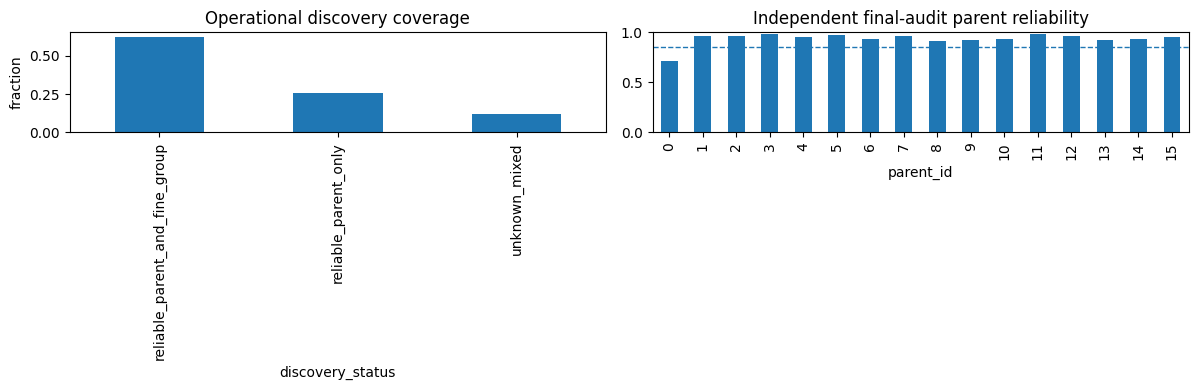

,stage,input,output,method
0,canonicalization,raw Electronic images,canonical nodes,exact joint pHash+dHash
1,representation,canonical pixels,G/Gf/L/Lf,fresh-run C-RADIO + DINO transforms
2,broad selection,"G/Gf/Gdual × K={16,18,20}",raw_parent_id,hard structural/reliability gates -> lowest nu...
3,fine discovery,5 global/morphology views within reliable parent,validated_fine_group_id,K-means K2–6 + child survival/withholding/cros...
4,complementary discovery,4 G/L visual views,raw_visual_leaf_id,stable-resolution K-means K2–8
5,global attributes,512-base DINO concept residuals,selected ICA scores,"k={10,20,40}, rank={8,12,16,24} compact selection"
6,family attributes,512-hires DINO concept residuals,parent-specific ICA scores,rank 2–6 Pareto/parsimony selection
7,local atypicality,16×16 foreground DINO descriptors,q99/z/percentile,identity-neighbour patch deviation
8,independent final evaluation,frozen parent/fine/raw structures,final audit metrics,group-aware resampling/withholding with indepe...
9,rationale ablations,frozen numerical structures,method decision evidence,K-means vs HDBSCAN/Leiden/kNN; child validatio...


In [64]:
# 68. Final report dashboard and stage table.

summary = {
    'raw_images': len(RAW_MANIFEST),
    'canonical_nodes': N_CANONICAL,
    'exact_duplicate_files_collapsed': len(RAW_MANIFEST) - N_CANONICAL,
    'primary_near_duplicate_edges': len(NEAR_BY_RULE[VAL_GROUP_RULE]),
    'validation_groups': len(np.unique(VALIDATION_GROUPS)),
    'selected_root': SELECTED_ROOT_ID,
    'broad_parents': int(len(np.unique(PARENT_LABELS))),
    'residual_parents_selection': int(PARENT_RELIABILITY_TABLE['residual_parent'].sum()),
    'validated_fine_groups': int(FINE_GROUP_MAP['validated_fine_group_id'].nunique())
    if len(FINE_GROUP_MAP) else 0,
    'raw_visual_leaves': int(RAW_VISUAL_MAP_TABLE['raw_visual_leaf_id'].nunique()),
    'parent_and_fine_fraction': float(
        np.mean(DISCOVERY_STATUS == 'reliable_parent_and_fine_group')
    ),
    'parent_only_fraction': float(
        np.mean(DISCOVERY_STATUS == 'reliable_parent_only')
    ),
    'unknown_mixed_fraction': float(np.mean(DISCOVERY_STATUS == 'unknown_mixed')),
    'global_ica_neighbors': GLOBAL_ICA_NEIGHBORS,
    'global_ica_rank': GLOBAL_ICA_RANK,
    'global_ica_interpretation_candidates': int(
        GLOBAL_FACTOR_METRICS['candidate_for_interpretation'].sum()
    ),
    'family_ica_interpretation_candidates': int(
        FAMILY_FACTOR_METRICS['candidate_for_interpretation'].sum()
    ) if len(FAMILY_FACTOR_METRICS) else 0,
    'patch_grid': '16x16',
    'final_audit_seed': FINAL_AUDIT_SEED,
    'final_audit_root_group_ari': root_group_ari,
    'final_audit_root_routing_macro': final_root_routing['routing_macro'],
    'minimum_parent_stress_stability': minimum_parent_stress,
    'minimum_fine_stress_stability': minimum_fine_stress,
}
FINAL_SUMMARY = pd.DataFrame([summary])
FINAL_SUMMARY.to_csv(
    OUT / 'exports' / 'final_discovery_summary.csv',
    index=False,
)
display(FINAL_SUMMARY.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
CONF['discovery_status'].value_counts(normalize=True).plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('fraction')
axes[0].set_title('Operational discovery coverage')

FINAL_PARENT_AUDIT_RELIABILITY.set_index('parent_id')['operational_reliability'].plot(
    kind='bar',
    ax=axes[1],
)
axes[1].axhline(RESIDUAL_PARENT_RELIABILITY, linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Independent final-audit parent reliability')
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'final_dashboard.png', dpi=180)
plt.show()

STAGE_TABLE = pd.DataFrame([
    {
        'stage': 'canonicalization',
        'input': 'raw Electronic images',
        'output': 'canonical nodes',
        'method': 'exact joint pHash+dHash',
    },
    {
        'stage': 'representation',
        'input': 'canonical pixels',
        'output': 'G/Gf/L/Lf',
        'method': 'fresh-run C-RADIO + DINO transforms',
    },
    {
        'stage': 'broad selection',
        'input': 'G/Gf/Gdual × K={16,18,20}',
        'output': 'raw_parent_id',
        'method': 'hard structural/reliability gates -> lowest nuisance in near-best reliability frontier',
    },
    {
        'stage': 'fine discovery',
        'input': '5 global/morphology views within reliable parent',
        'output': 'validated_fine_group_id',
        'method': 'K-means K2–6 + child survival/withholding/cross-view gates',
    },
    {
        'stage': 'complementary discovery',
        'input': '4 G/L visual views',
        'output': 'raw_visual_leaf_id',
        'method': 'stable-resolution K-means K2–8',
    },
    {
        'stage': 'global attributes',
        'input': '512-base DINO concept residuals',
        'output': 'selected ICA scores',
        'method': 'k={10,20,40}, rank={8,12,16,24} compact selection',
    },
    {
        'stage': 'family attributes',
        'input': '512-hires DINO concept residuals',
        'output': 'parent-specific ICA scores',
        'method': 'rank 2–6 Pareto/parsimony selection',
    },
    {
        'stage': 'local atypicality',
        'input': '16×16 foreground DINO descriptors',
        'output': 'q99/z/percentile',
        'method': 'identity-neighbour patch deviation',
    },
    {
        'stage': 'independent final evaluation',
        'input': 'frozen parent/fine/raw structures',
        'output': 'final audit metrics',
        'method': f'group-aware resampling/withholding with independent seed {FINAL_AUDIT_SEED}',
    },
    {
        'stage': 'rationale ablations',
        'input': 'frozen numerical structures',
        'output': 'method decision evidence',
        'method': 'K-means vs HDBSCAN/Leiden/kNN; child validation; FastICA vs NMF',
    },
])
STAGE_TABLE.to_csv(
    OUT / 'exports' / 'pipeline_stage_summary.csv',
    index=False,
)
display(STAGE_TABLE)

In [65]:
# 69. Freeze the fresh run and create the interpretation/inference handoff bundle.

fine_config = {}
for parent_id, selection in FINE_SELECTION.items():
    accepted_local_children = (
        FINE_GROUP_MAP.loc[
            FINE_GROUP_MAP['parent_id'] == parent_id,
            'local_child_id',
        ].astype(int).tolist()
        if len(FINE_GROUP_MAP)
        else []
    )
    if selection is None:
        continue
    fine_config[str(parent_id)] = {
        'view': str(selection['obj']['view']),
        'k': int(selection['obj']['k']),
        'medoid_seed': int(selection['obj']['seed']),
        'accepted_local': accepted_local_children,
        'deployed': bool(len(accepted_local_children) >= 2),
    }

raw_visual_config = {}
for parent_id, selection in RAW_VISUAL_SELECTION.items():
    if selection is None:
        raw_visual_config[str(parent_id)] = {
            'view': 'parent_only',
            'k': 1,
        }
    else:
        raw_visual_config[str(parent_id)] = {
            'view': str(selection['view']),
            'k': int(selection['k']),
        }

family_ica_ranks = {
    str(parent_id): int(bundle['rank'])
    for parent_id, bundle in FAMILY_ICA_BY_PARENT.items()
}

METHOD_CONFIG = {
    'pipeline_version': PIPELINE_VERSION,
    'source_root': str(SOURCE_ROOT),
    'run_root': str(RUN_ROOT),
    'root_selection_space': {
        'views': list(ROOT_VIEWS),
        'ks': list(PARENT_KS),
        'selected_id': SELECTED_ROOT_ID,
        'selected_view': SELECTED_ROOT_VIEW_NAME,
        'selected_k': int(chosen['k']),
        'selection_rule': (
            'hard structural/reproducibility gates -> near-best worst-class '
            'recall/precision frontier -> lowest nuisance excess'
        ),
    },
    'selection_validation': {
        'group_split_reps': SELECTION_GROUP_SPLIT_REPS,
        'holdout_reps': SELECTION_HOLDOUT_REPS,
        'seed': SEED,
    },
    'final_audit': {
        'group_split_reps': FINAL_AUDIT_GROUP_SPLIT_REPS,
        'holdout_reps': FINAL_AUDIT_HOLDOUT_REPS,
        'seed': FINAL_AUDIT_SEED,
        'feeds_back_into_assignments': False,
    },
    'fine_selection_space': {
        'views': list(FINE_VIEWS),
        'ks': list(IDENTITY_KS),
        'selected': fine_config,
    },
    'raw_visual_selection_space': {
        'views': list(RAW_VISUAL_VIEWS),
        'ks': list(VISUAL_KS),
        'selected': raw_visual_config,
    },
    'global_ica': {
        'bank': '512_base',
        'neighbor_candidates': list(GLOBAL_ICA_NEIGHBOR_KS),
        'rank_candidates': list(GLOBAL_ICA_RANKS),
        'selected_neighbors': GLOBAL_ICA_NEIGHBORS,
        'selected_rank': GLOBAL_ICA_RANK,
    },
    'family_ica': {
        'bank': '512_hires',
        'neighbors': FAMILY_ICA_NEIGHBORS,
        'rank_candidates': list(FAMILY_ICA_RANK_CANDIDATES),
        'selected_ranks': family_ica_ranks,
    },
    'patch': {
        'grid': 16,
        'prototypes': PATCH_PROTOTYPES[16],
        'reference_neighbors': LOCAL_PATCH_NEIGHBORS,
    },
    'near_duplicate_rules': NEAR_DUP_RULES,
    'validation_group_rule': VAL_GROUP_RULE,
    'foreground_preproc': FOREGROUND_PREPROC_VERSION,
    'foreground_dino_preproc': FOREGROUND_DINO_PREPROC_VERSION,
}
write_json_atomic(
    OUT / 'handoff' / 'final_method_config.json',
    METHOD_CONFIG,
)

FREEZE = {
    'pipeline_version': PIPELINE_VERSION,
    'created_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'cohort_fp': COHORT_FP,
    'feature_fp': FEATURE_FP,
    'validation_group_sha': hashlib.sha256(
        np.asarray(VALIDATION_GROUPS, np.int32).tobytes()
    ).hexdigest(),
    'parent_sha': hashlib.sha256(
        np.asarray(PARENT_LABELS, np.int32).tobytes()
    ).hexdigest(),
    'fine_sha': hashlib.sha256(
        np.asarray(FINE_GROUP_LABELS, np.int32).tobytes()
    ).hexdigest(),
    'raw_visual_sha': hashlib.sha256(
        np.asarray(RAW_VISUAL_LABELS, np.int32).tobytes()
    ).hexdigest(),
    'global_ica_scores_sha': hashlib.sha256(
        np.asarray(GLOBAL_ICA_SCORES, np.float32).tobytes()
    ).hexdigest(),
    'patch_percentile_sha': hashlib.sha256(
        np.asarray(PATCH16_STATS[:, -1], np.float32).tobytes()
    ).hexdigest(),
    'model_identity': MODEL_IDENTITY,
    'selection_seed': SEED,
    'final_audit_seed': FINAL_AUDIT_SEED,
}
write_json_atomic(
    OUT / 'handoff' / 'FINAL_DISCOVERY_FREEZE.json',
    FREEZE,
)

manifest = {
    'pipeline_version': PIPELINE_VERSION,
    'cohort_fp': COHORT_FP,
    'feature_fp': FEATURE_FP,
    'models': MODEL_IDENTITY,
    'software': ENVIRONMENT.iloc[0].to_dict(),
    'artifacts': {
        'canonical_export': 'exports/per_image_final_discovery.csv',
        'raw_export': 'exports/per_raw_image_final_discovery.csv',
        'interpretation_template': 'exports/interpretation_template.csv',
        'method_config': 'handoff/final_method_config.json',
        'freeze': 'handoff/FINAL_DISCOVERY_FREEZE.json',
        'final_evaluation': 'metrics/final_evaluation_summary.csv',
        'experiment_decisions': 'metrics/experiment_decision_summary.csv',
    },
}
write_json_atomic(OUT / 'manifest.json', manifest)

README = f"""# CIRCL-E Final Image-Only Discovery Handoff

This bundle contains a freshly regenerated **image-only numerical discovery run**.
No previous assignment vector is imported or replayed.

Selected broad root: `{SELECTED_ROOT_ID}`.

## Numerical IDs

- `raw_parent_id`: broad visual parent selected from the compact global-view K-means search.
- `validated_fine_group_id`: conservative parent-conditional recurring visual structure; **not automatically a device subtype**.
- `raw_visual_leaf_id`: complementary visual grouping that may encode state, configuration, morphology, scene, or acquisition.
- `global_ica_*`: cross-family continuous signed-residual factors.
- `family_ica__pXX__fYY`: parent-specific factors; scores are not comparable across parents.
- `patch_local_*`: identity-relative local visual atypicality; not a calibrated damage probability.

## Selection versus final evaluation

Selection uses `{SELECTION_GROUP_SPLIT_REPS}` group-resampling repeats and `{SELECTION_HOLDOUT_REPS}` withholding repeats with seed `{SEED}`.
After the numerical structures are fixed, `metrics/final_evaluation_summary.csv` and `metrics/final_clustering_evaluation.csv` report an independent audit using seed `{FINAL_AUDIT_SEED}`. Final-audit results do **not** feed back into assignments.

## Experimental rationale

`metrics/experiment_decision_summary.csv` records the compact successful/failed method ablations (K-means vs HDBSCAN/Leiden/kNN, child-level validation, and FastICA vs NMF). These experiments are explanatory only.

## Interpretation rule

Do not feed semantic naming or semantic merges back into this frozen numerical structure. Use the review montages and blank interpretation template in a separate interpretation notebook.
"""
(OUT / 'handoff' / 'HANDOFF_README.md').write_text(README)

if BUILD_HANDOFF_ZIP:
    handoff_zip = OUT / 'FINAL_DISCOVERY_HANDOFF.zip'
    with zipfile.ZipFile(handoff_zip, 'w', zipfile.ZIP_DEFLATED) as archive:
        for relative_path in [
            'handoff',
            'exports',
            'metrics',
            'validation',
            'plots',
            'review',
            'models',
            'views',
            'manifests',
            'root',
            'fine',
            'visual',
            'attributes',
            'patch_deviation',
            'manifest.json',
        ]:
            source = OUT / relative_path
            if source.is_file():
                archive.write(source, source.relative_to(OUT))
            elif source.is_dir():
                for file_path in source.rglob('*'):
                    if file_path.is_file():
                        archive.write(file_path, file_path.relative_to(OUT))
    print('Handoff bundle:', handoff_zip)

print('=' * 110)
print('FINAL IMAGE-ONLY DISCOVERY COMPLETE')
print(
    'Numerical discovery is frozen. Proceed to interpretation using:',
    OUT / 'FINAL_DISCOVERY_HANDOFF.zip',
)

Handoff bundle: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/FINAL_DISCOVERY_HANDOFF.zip
FINAL IMAGE-ONLY DISCOVERY COMPLETE
Numerical discovery is frozen. Proceed to interpretation using: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/Semifinal/artifacts/FINAL_DISCOVERY_HANDOFF.zip
